<a href="https://colab.research.google.com/github/sahil-walunj/Formal_verification_of_Deep_Neural_Networks/blob/main/BCCN_VGG16_binary_and_non_binary_tau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gurobipy

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, utils
from tensorflow.keras.layers import  MaxPooling2D
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import random

In [ ]:
# params = {
#     "WLSACCESSID":"4d102d43-af47-4767-8294-5c56341d0f8a",
#     "WLSSECRET":"dae74acb-a20b-4fec-92b6-9737c8626ca6",
#     "LICENSEID":2778199
# }
# env = gp.Env(params=params)

In [ ]:

# =============================================================================
# PART 1: ABC-NET LAYERS & MODEL DEFINITION
# =============================================================================

@tf.custom_gradient
def sign_ste(x):
    """Binary Sign function with Straight-Through Estimator (STE)."""
    y = tf.where(x >= 0, 1.0, -1.0)
    def grad(dy):
        return dy * tf.cast(tf.abs(x) <= 1.0, tf.float32)
    return y, grad

class ABCConv2D(layers.Layer):
    """ABC-Net Convolution: W ~ sum(alpha_m * B_m)"""
    def __init__(self, filters, kernel_size, strides=1, M_bases=3, **kwargs):
        super(ABCConv2D, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.strides = strides
        self.M = M_bases

    def build(self, input_shape):
        self.kernel = self.add_weight(name="kernel",
            shape=self.kernel_size + (input_shape[-1], self.filters),
            initializer="glorot_uniform", trainable=True)
        self.bias = self.add_weight(name="bias",
            shape=(self.filters,), initializer="zeros", trainable=True)

        if self.M == 1: self.u = tf.constant([0.0])
        else: self.u = tf.linspace(-1.0, 1.0, self.M)

    def call(self, inputs):
        # 1. Statistics & Binarization
        mean, var = tf.nn.moments(self.kernel, axes=[0, 1, 2], keepdims=True)
        std = tf.sqrt(var + 1e-5)
        W_centered = self.kernel - mean

        u_reshaped = tf.reshape(self.u, (-1, 1, 1, 1, 1))
        W_expanded = tf.expand_dims(W_centered, 0)
        B = sign_ste(W_expanded + u_reshaped * std)

        # 2. Solve Alphas (Projection)
        k_h, k_w, c_in, c_out = self.kernel.shape
        N = k_h * k_w * c_in
        W_flat = tf.reshape(self.kernel, (1, N, c_out))
        B_flat = tf.reshape(B, (self.M, N, c_out))
        alpha = tf.reduce_sum(W_flat * B_flat, axis=1) / tf.cast(N, tf.float32)

        # 3. Effective Weights
        alpha_reshaped = tf.reshape(alpha, (self.M, 1, 1, 1, c_out))
        W_eff = tf.reduce_sum(alpha_reshaped * B, axis=0)

        # NOTE: Padding is handled explicitly outside this layer now
        return tf.nn.conv2d(inputs, W_eff, strides=self.strides, padding="VALID") + self.bias

    def get_effective_weights(self):
        mean, var = tf.nn.moments(self.kernel, axes=[0, 1, 2], keepdims=True)
        std = tf.sqrt(var + 1e-5)
        W_centered = self.kernel - mean
        u_reshaped = tf.reshape(self.u, (-1, 1, 1, 1, 1))
        B = sign_ste(tf.expand_dims(W_centered, 0) + u_reshaped * std)

        k_h, k_w, c_in, c_out = self.kernel.shape
        N = k_h * k_w * c_in
        W_flat = tf.reshape(self.kernel, (1, N, c_out))
        B_flat = tf.reshape(B, (self.M, N, c_out))
        alpha = tf.reduce_sum(W_flat * B_flat, axis=1) / tf.cast(N, tf.float32)

        alpha_reshaped = tf.reshape(alpha, (self.M, 1, 1, 1, c_out))
        W_eff = tf.reduce_sum(alpha_reshaped * B, axis=0)
        return W_eff.numpy(), self.bias.numpy()

class ABCActivation(layers.Layer):
    """ABC-Net Activation: R ~ sum(beta_n * A_n)"""
    def __init__(self, N_bases=3, **kwargs):
        super(ABCActivation, self).__init__(**kwargs)
        self.N = N_bases

    def build(self, input_shape):
        self.beta = self.add_weight(name="beta", shape=(self.N,),
            initializer=tf.initializers.Constant(1.0/self.N), trainable=True)
        init_v = np.linspace(-0.5, 0.5, self.N)
        self.v = self.add_weight(name="v", shape=(self.N,),
            initializer=tf.initializers.Constant(init_v), trainable=True)

    def call(self, inputs):
        x_expanded = tf.expand_dims(inputs, -1)
        thresholds = 0.5 - self.v
        A = sign_ste(x_expanded - thresholds)
        return tf.reduce_sum(A * self.beta, axis=-1)

    def get_params(self):
        return self.beta.numpy(), self.v.numpy()

In [ ]:
# -----------------------------------------------------------------------------
# MODIFIED: VGG16 Architecture for ABC-Net
# -----------------------------------------------------------------------------

def build_abc_vgg16(input_shape, num_classes, M=3, N=3):
    """
    ABC-Net implementation of VGG-16.
    Adjustments for MILP compatibility:
    1. Replaced Pooling with Strided Convolutions (Stride 2).
    2. Used explicit ZeroPadding2D(1) before ABCConv to match MILP padding logic.
    3. Removed intermediate Dense(84) to allow MILP parser (which expects single Dense output) to function without modification.
    """
    inputs = layers.Input(shape=input_shape)

    # --- Layer 1: Conv (4 filters, 3x3) + Downsampling ---
    # Input: 28x28 -> Pad(1) -> 30x30 -> Conv(5x5, stride 2) -> 13x13
    x = layers.ZeroPadding2D(padding=(1, 1))(inputs)
    x = ABCConv2D(4, (3,3), strides=1, M_bases=M)(x)
    x = ABCActivation(N_bases=N)(x)
    x = layers.ZeroPadding2D(padding=(1, 1))(x)
    x = ABCConv2D(4, (3,3), strides=2, M_bases=M)(x)
    x = ABCActivation(N_bases=N)(x)

    # --- Layer 2: Conv (8 filters, 3x3) + Downsampling ---
    # Input: 13x13 -> Pad(1) -> 15x15 -> Conv(5x5, stride 2) -> 6x6
    x = layers.ZeroPadding2D(padding=(1, 1))(x)
    x = ABCConv2D(8, (3,3), strides=1, M_bases=M)(x)
    x = ABCActivation(N_bases=N)(x)
    x = layers.ZeroPadding2D(padding=(1, 1))(x)
    x = ABCConv2D(8, (3,3), strides=2, M_bases=M)(x)
    x = ABCActivation(N_bases=N)(x)

    # # --- Layer 3: Conv (16 filters, 3x3) ---
    # # Input: 6x6 -> Pad(1) -> 8x8 -> Conv(5x5, stride 2) -> 2x2
    # x = layers.ZeroPadding2D(padding=(1, 1))(x)
    # x = ABCConv2D(16, (3,3), strides=2, M_bases=M)(x)
    # x = ABCActivation(N_bases=N)(x)
    # x = ABCConv2D(16, (3,3), strides=2, M_bases=M)(x)
    # x = ABCActivation(N_bases=N)(x)
    # x = MaxPooling2D(pool_size=(2,2), strides=2)(x)

    # --- Output ---
    x = layers.Flatten()(x)
    #bringing 784 down to 256
    # x = layers.Dense(256, activation='relu', name="fc1")(x)
    # Direct mapping to 10 classes to preserve MILP parser compatibility
    x = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, x)

In [ ]:
model = build_abc_vgg16((28,28,1), 10, M=3, N=3)
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 zero_padding2d (ZeroPaddin  (None, 30, 30, 1)         0         
 g2D)                                                            
                                                                 
 abc_conv2d (ABCConv2D)      (None, 28, 28, 4)         40        
                                                                 
 abc_activation (ABCActivat  (None, 28, 28, 4)         6         
 ion)                                                            
                                                                 
 zero_padding2d_1 (ZeroPadd  (None, 30, 30, 4)         0         
 ing2D)                                                          
                                                            

In [ ]:
# @title

# =============================================================================
# PART 2: TRAINING ON MNIST (MODIFIED to use LeNet-5)
# =============================================================================

def train_model():
    print("\n--- 1. Loading MNIST Data ---")
    (x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    y_train_cat = utils.to_categorical(y_train, 10)
    y_test_cat = utils.to_categorical(y_test, 10)

    print("\n--- 2. Building & Training ABC-Net (LeNet-5 Variant) ---")
    # MODIFIED: Calling the vgg16 builder
    model = build_abc_vgg16((28,28,1), 10, M=3, N=3)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    model.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.1)

    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
    print(f"Test Accuracy: {test_acc*100:.2f}%")

    return model, x_test, y_test

# 1 & 2. Build and Train
model, x_test, y_test = train_model()







--- 1. Loading MNIST Data ---

--- 2. Building & Training ABC-Net (LeNet-5 Variant) ---

Epoch 1/5


844/844 [==============================] - 8s 7ms/step - loss: 0.6874 - accuracy: 0.7715 - val_loss: 0.2127 - val_accuracy: 0.9330
Epoch 2/5
844/844 [==============================] - 6s 7ms/step - loss: 0.2376 - accuracy: 0.9269 - val_loss: 0.1584 - val_accuracy: 0.9527
Epoch 3/5
844/844 [==============================] - 6s 7ms/step - loss: 0.1833 - accuracy: 0.9426 - val_loss: 0.1326 - val_accuracy: 0.9583
Epoch 4/5
844/844 [==============================] - 6s 7ms/step - loss: 0.1490 - accuracy: 0.9540 - val_loss: 0.1135 - val_accuracy: 0.9677
Epoch 5/5
844/844 [==============================] - 8s 9ms/step - loss: 0.1327 - accuracy: 0.9594 - val_loss: 0.1077 - val_accuracy: 0.9662
Test Accuracy: 96.67%


In [ ]:
cutout_size = 4

In [ ]:
# @title
# =============================================================================
# PART 3 & 4: PERTURBATION GENERATION & FILTERING
# =============================================================================

def generate_failures(model, x_test, y_test, cutout_size, max_scan_images=2000):
    print(f"\n--- 3. Scanning {max_scan_images} images for failures ---")

    failures = []
    preds_orig = np.argmax(model.predict(x_test[:max_scan_images], verbose=0), axis=1)

    center_x, center_y = 14, 14
    half_size = cutout_size // 2
    start_x, start_y = center_x - half_size, center_y - half_size

    x_perturbed_batch = x_test[:max_scan_images].copy()
    x_perturbed_batch[:, start_x:start_x+cutout_size, start_y:start_y+cutout_size, :] = 0.0

    preds_pert = np.argmax(model.predict(x_perturbed_batch, verbose=0), axis=1)

    for idx in range(max_scan_images):
        if preds_orig[idx] == y_test[idx] and preds_pert[idx] != y_test[idx]:
            failures.append({
                'id': idx,
                'original': x_test[idx],
                'perturbed': x_perturbed_batch[idx],
                'true_label': y_test[idx],
                'wrong_label': preds_pert[idx]
            })

    print(f"Found {len(failures)} failure cases.")
    return failures

In [ ]:
failures = generate_failures(model, x_test, y_test, cutout_size, max_scan_images=2000)


--- 3. Scanning 2000 images for failures ---
Found 116 failure cases.


In [ ]:
# =============================================================================
# PART 5: MILP REPAIR (UNMODIFIED CONSTANTS)
# =============================================================================

def solve_tau_milp(model, failure_case, grid_size=4,tauType=0):
    x_pert = failure_case['perturbed']
    true_label = failure_case['true_label']

    # try:
    #     # Create environment
    #     env = gp.Env(empty=True)
    #     env.setParam("OutputFlag", 0)
    #     env.start()
    # except:
    #     print("Gurobi License Error or Not Found. (Ensure Gurobi is installed and licensed)")
    #     return None

    m = gp.Model("ABCNet_Repair")
    m.setParam("TimeLimit", 120)
    m.setParam("OutputFlag", 0)
    m.setParam("MIPFocus", 1)

    # --- VARIABLES ---
    x_input = m.addMVar((28, 28, 1), lb=0, ub=1, name="x_input")
    if(tauType == 0):
      tau = m.addMVar((grid_size, grid_size), vtype=GRB.BINARY, name="tau")
    else:
      tau = m.addMVar((grid_size, grid_size),lb=0,ub=1, name="tau")

    start = 14 - grid_size // 2

    # Input Constraint
    for r in range(28):
        for c in range(28):
            if start <= r < start + grid_size and start <= c < start + grid_size:
                tr, tc = r - start, c - start
                m.addConstr(x_input[r, c, 0] == tau[tr, tc])
            else:
                m.addConstr(x_input[r, c, 0] == x_pert[r, c, 0])

    # --- LAYER ENCODING ---
    current_vars = x_input
    layer_idx = 1 # Skip Input Layer

    # Parsing layers: ZeroPad -> ABCConv -> BN -> Act
    while layer_idx < len(model.layers):
        layer = model.layers[layer_idx]

        if isinstance(layer, layers.ZeroPadding2D):
            layer_idx += 1
            continue

        if isinstance(layer, ABCConv2D):
            W_eff, b_conv = layer.get_effective_weights()
            stride = layer.strides

            act_layer = model.layers[layer_idx+1]

            W_fused = W_eff
            b_fused = b_conv

            betas, vs = act_layer.get_params()

            h_in, w_in, c_in = current_vars.shape

            # Stride calculation
            # Note: Explicit padding logic used below assumes output dims
            # consistent with ZeroPadding2D(1) + Conv(Valid)
            # h_out = int(np.ceil(h_in / stride))
            # w_out = int(np.ceil(w_in / stride))

            # --- FIX STARTS HERE ---
            # Get kernel dimensions from the effective weights
            k_h, k_w, _, _ = W_fused.shape

            # Correct Convolution Arithmetic: (Input + Padding - Kernel) // Stride + 1
            # Note: We add +2 to h_in/w_in because we explicitly padded the input by 1 on both sides
            h_out = (h_in + 2 - k_h) // stride + 1
            w_out = (w_in + 2 - k_w) // stride + 1
            c_out = W_fused.shape[-1]

            layer_out = m.addMVar((h_out, w_out, c_out), lb=-GRB.INFINITY)

            # MILP Padding: 1 pixel all around (Hardcoded constraint)
            padded = m.addMVar((h_in+2, w_in+2, c_in), lb=-GRB.INFINITY)
            m.addConstr(padded[1:-1, 1:-1, :] == current_vars)
            m.addConstr(padded[0,:,:]==0); m.addConstr(padded[-1,:,:]==0)
            m.addConstr(padded[:,0,:]==0); m.addConstr(padded[:,-1,:]==0)

            for r in range(h_out):
                for c in range(w_out):
                    in_r = r * stride
                    in_c = c * stride

                    for k in range(c_out):
                        w_kernel = W_fused[:, :, :, k]

                        # Vectorized weight identification (works for 3x3, 5x5, etc.)
                        nz_idx = np.where(np.abs(w_kernel) > 1e-5)
                        nz_vals = w_kernel[nz_idx]

                        input_vars_list = padded[
                            in_r + nz_idx[0],
                            in_c + nz_idx[1],
                            nz_idx[2]
                        ].tolist()

                        conv_expr = gp.LinExpr(b_fused[k])
                        conv_expr.addTerms(nz_vals, input_vars_list)

                        # Activation logic
                        act_expr = gp.LinExpr(0.0)
                        for n in range(len(betas)):
                            z = m.addVar(vtype=GRB.BINARY)
                            thresh = 0.5 - vs[n]
                            m.addGenConstrIndicator(z, 1, conv_expr >= thresh)
                            m.addGenConstrIndicator(z, 0, conv_expr <= thresh - 1e-5)
                            act_expr += betas[n] * (2 * z - 1)

                        m.addConstr(layer_out[r, c, k] == act_expr)

            current_vars = layer_out
            layer_idx += 2 # Conv, Act

        elif isinstance(layer, layers.Flatten):
            layer_idx += 1

        elif isinstance(layer, layers.Dense):
            W, b = layer.get_weights()
            flat_in = current_vars.reshape(-1)
            # Hardcoded assumption: Dense layer is the final 10-class output
            logits = m.addMVar(10, lb=-GRB.INFINITY)

            for j in range(10):
                expr = gp.LinExpr(b[j])
                for i in range(flat_in.shape[0]):
                    expr += flat_in[i] * W[i, j]
                m.addConstr(logits[j] == expr)

            layer_idx += 1
        else:
            layer_idx += 1

    # --- OBJECTIVE ---
    target_logit = logits[true_label]
    for i in range(10):
        if i != true_label:
            m.addConstr(target_logit >= logits[i] + 1)

    m.setObjective(0, GRB.MINIMIZE)

    print(f"Solving for True Label {true_label}...")
    m.optimize()

    if m.status == GRB.OPTIMAL:
        found_tau_vals = tau.X
        print(f"Pixels to add: {np.sum(found_tau_vals)}")
        return found_tau_vals
    elif m.status == GRB.INFEASIBLE:
        print("Model is Infeasible.")
        return None
    else:
        print(f"No Repair Found (Status {m.status})")
        return None

Selecting 100 random failure cases...

--- Case 1 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.0
Optimization Time: 9.6467 seconds
Successfully restored!


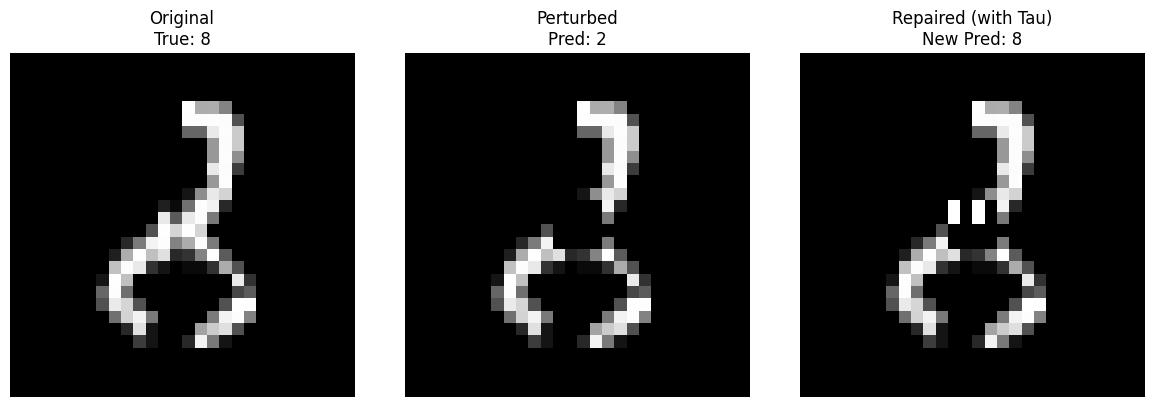


--- Case 2 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 5.0
Optimization Time: 6.3990 seconds
Successfully restored!


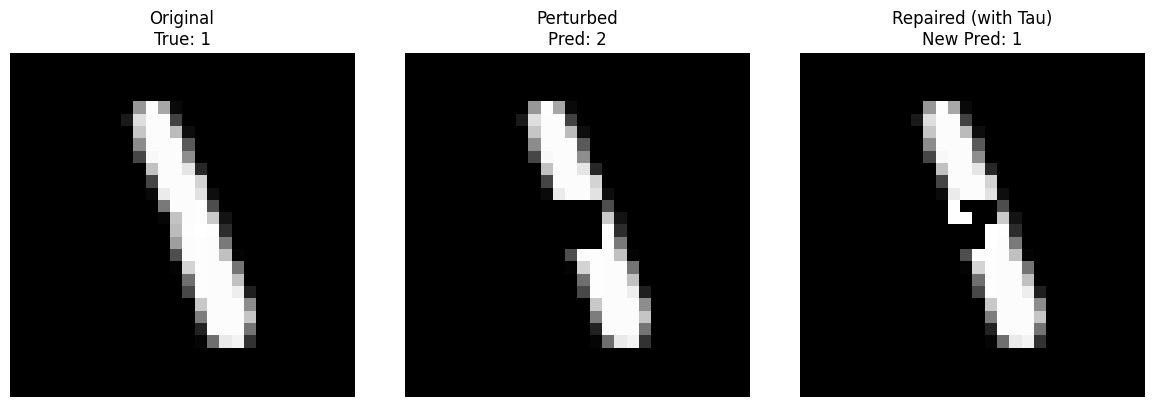


--- Case 3 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.0
Optimization Time: 7.1547 seconds
Successfully restored!


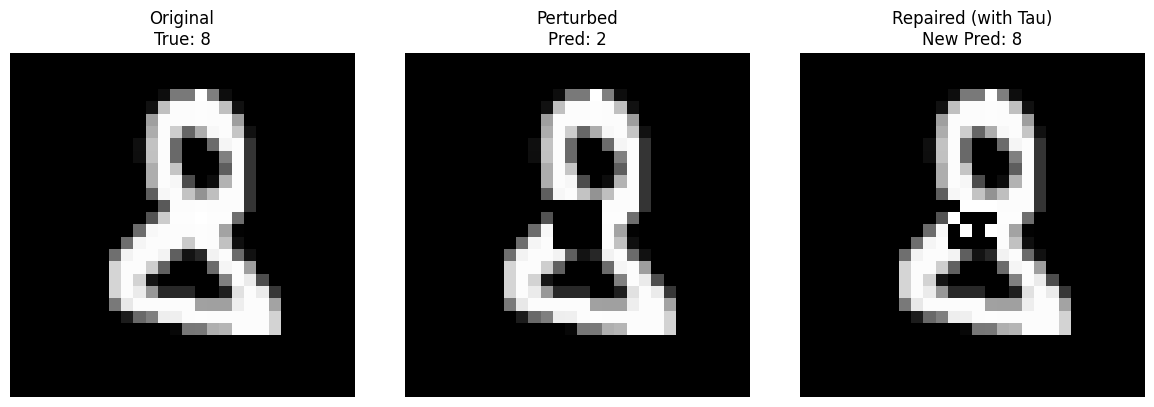


--- Case 4 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 4.0
Optimization Time: 8.8513 seconds
Successfully restored!


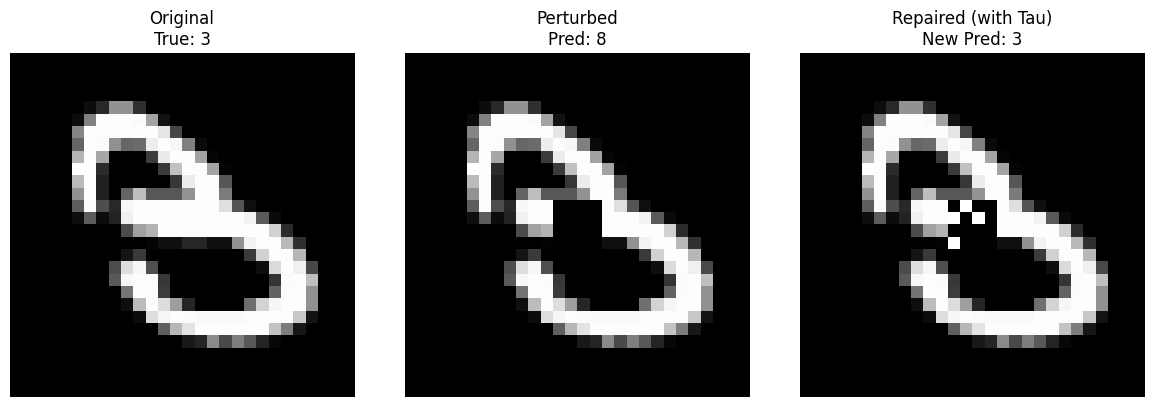


--- Case 5 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.0
Optimization Time: 6.7598 seconds
Successfully restored!


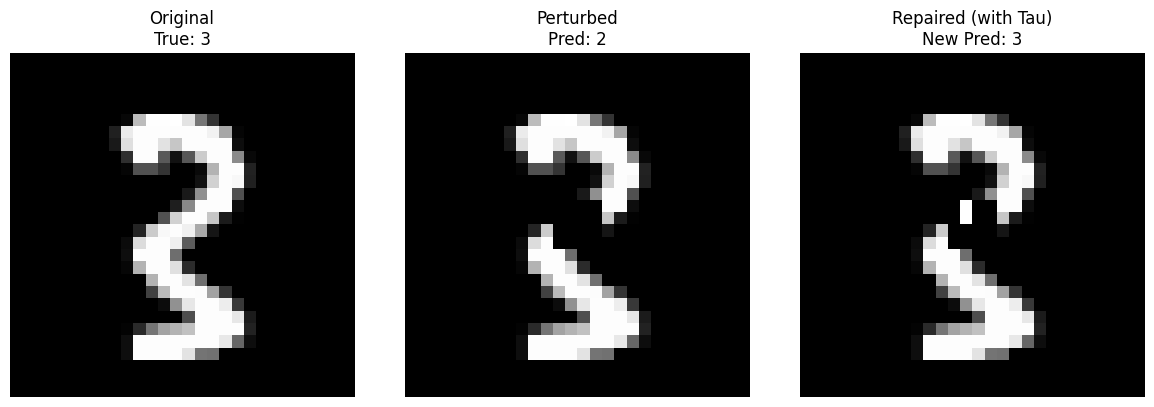


--- Case 6 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.9200 seconds
Successfully restored!


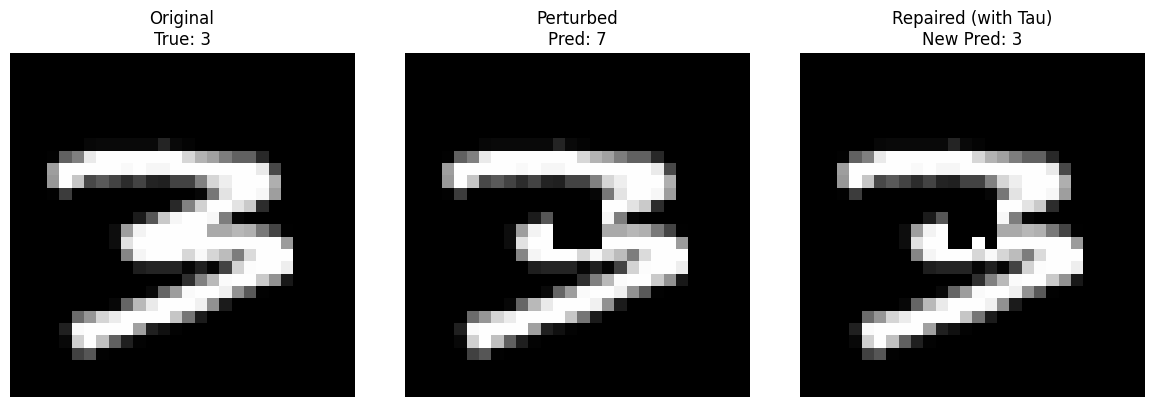


--- Case 7 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 4.0
Optimization Time: 10.2387 seconds
Successfully restored!


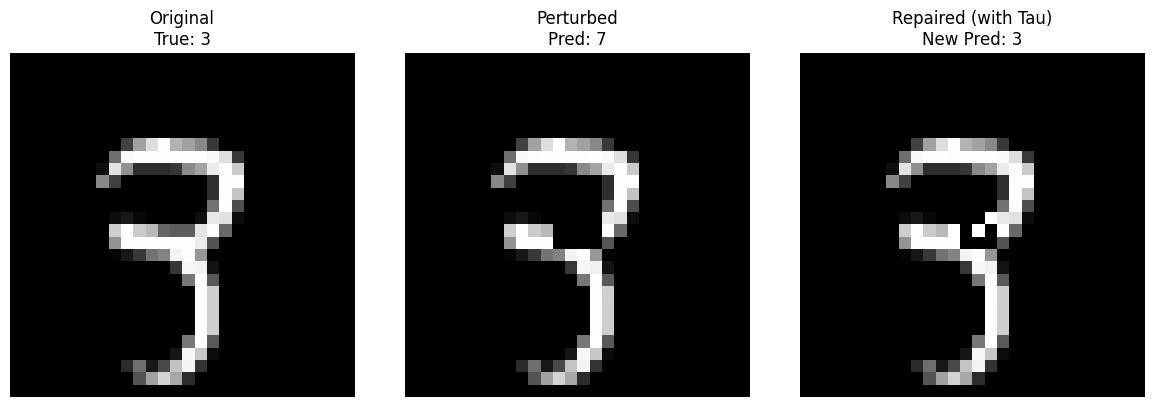


--- Case 8 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.0
Optimization Time: 7.4819 seconds
Successfully restored!


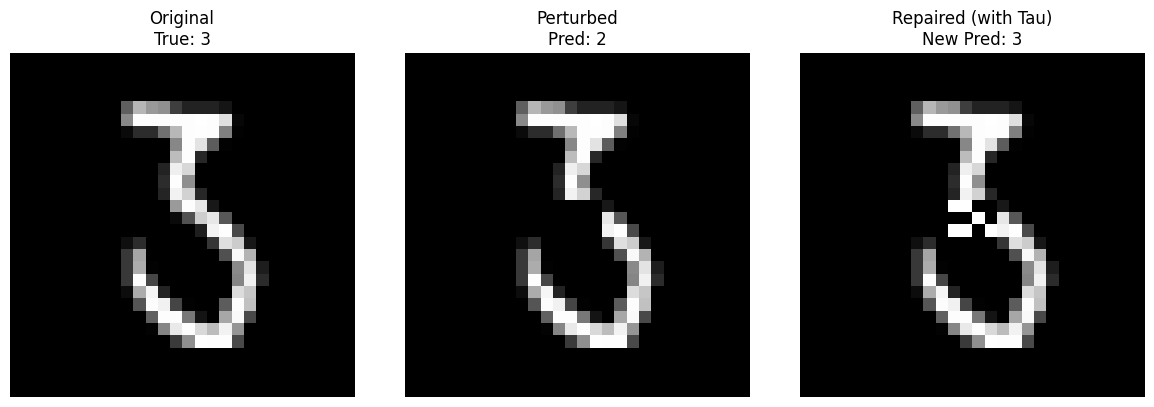


--- Case 9 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 3.0
Optimization Time: 6.8513 seconds
Successfully restored!


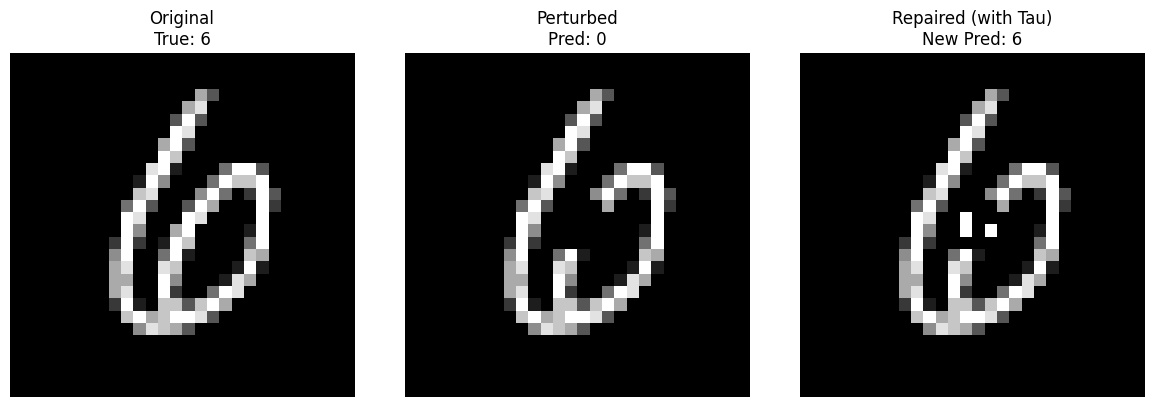


--- Case 10 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 7.0
Optimization Time: 6.8695 seconds
Successfully restored!


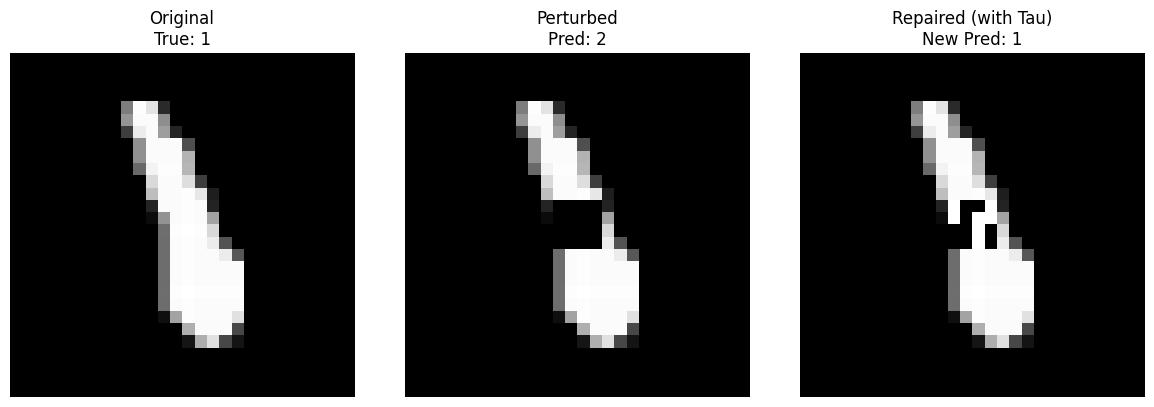


--- Case 11 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.0
Optimization Time: 6.9003 seconds
Successfully restored!


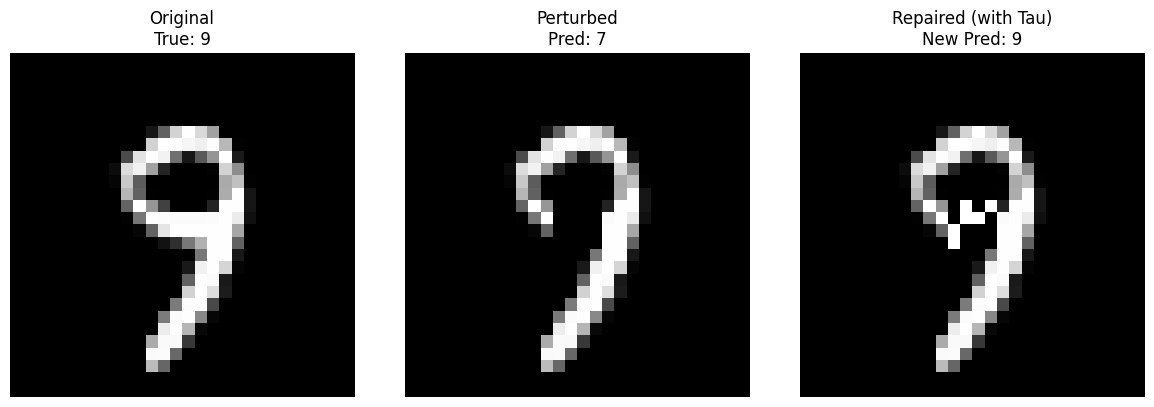


--- Case 12 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.8150 seconds
Successfully restored!


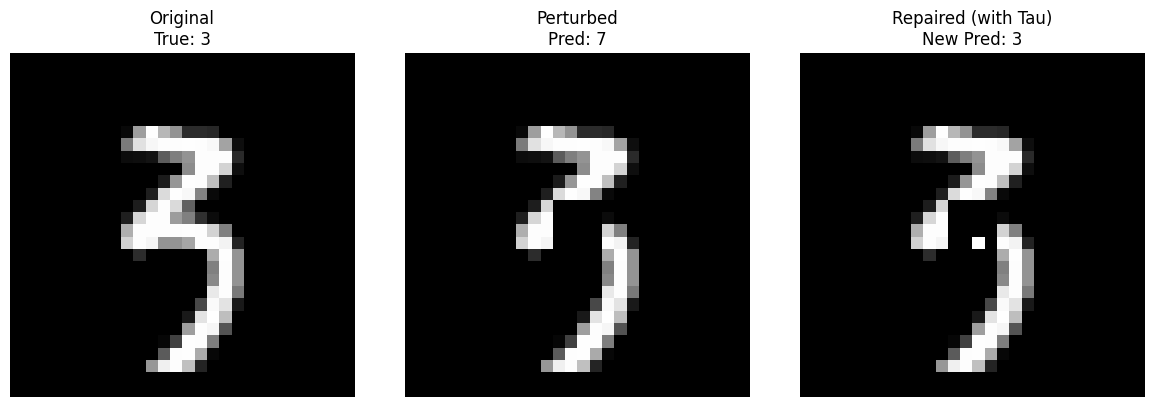


--- Case 13 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 8.0
Optimization Time: 6.8831 seconds
Successfully restored!


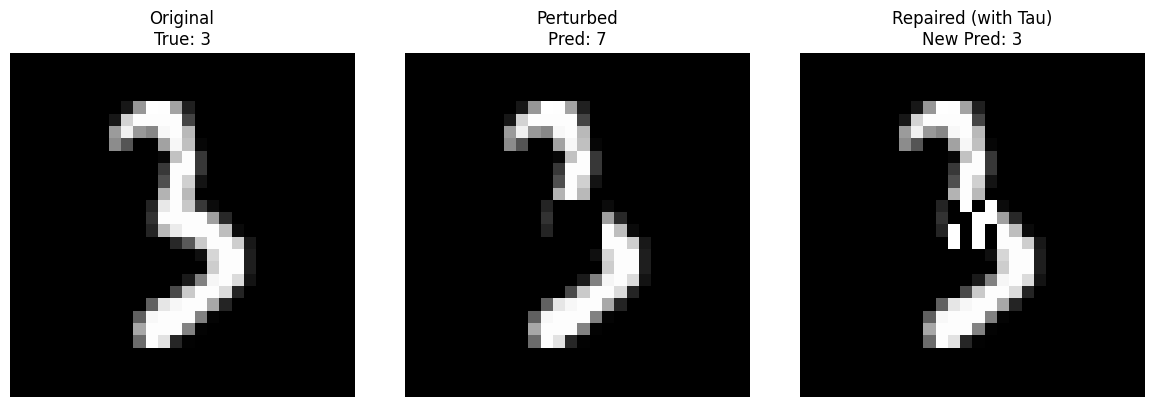


--- Case 14 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.0
Optimization Time: 6.9771 seconds
Successfully restored!


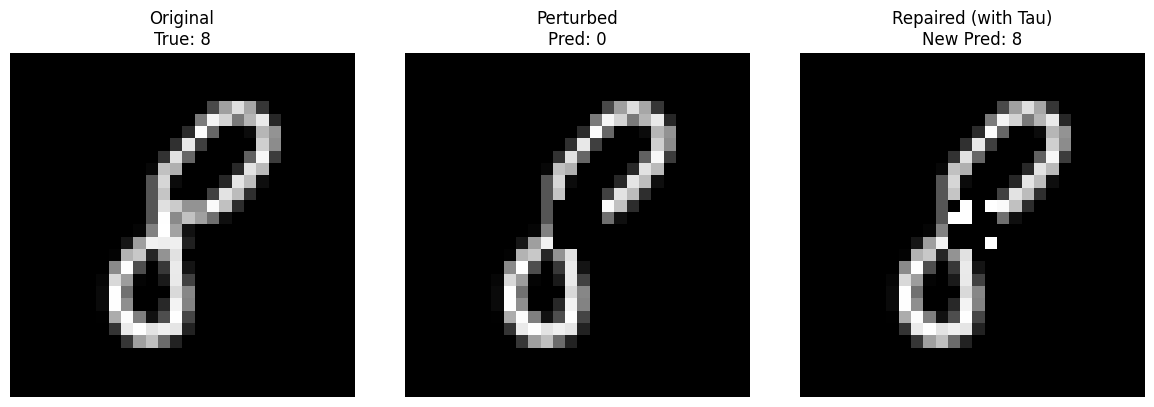


--- Case 15 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.0
Optimization Time: 6.7197 seconds
Successfully restored!


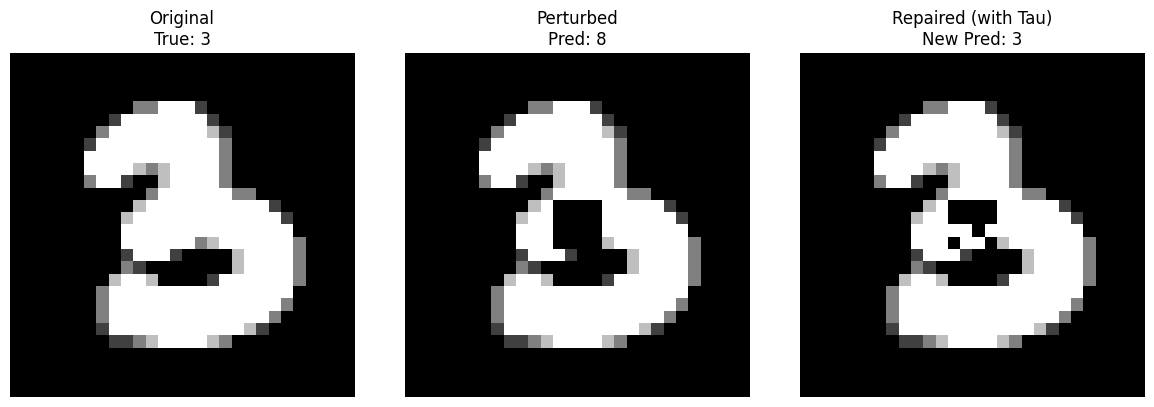


--- Case 16 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 4.0
Optimization Time: 7.3679 seconds
Successfully restored!


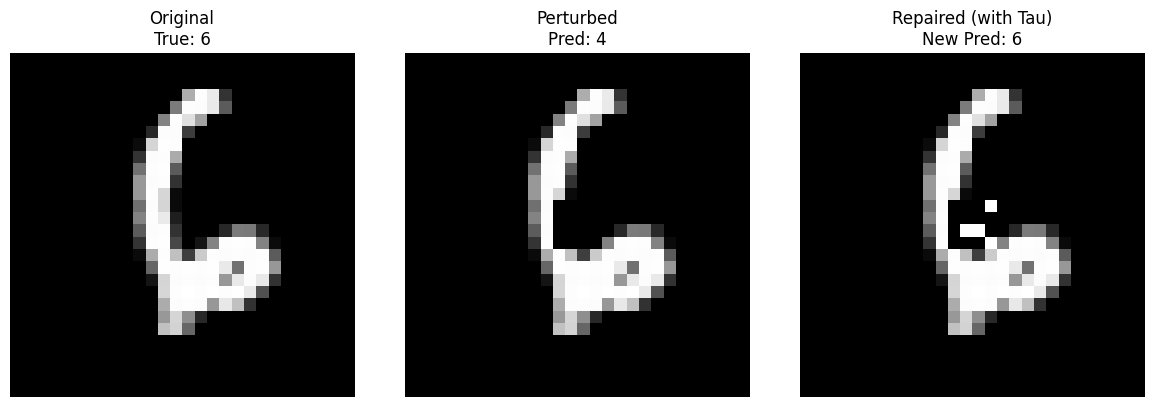


--- Case 17 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.9455 seconds
Successfully restored!


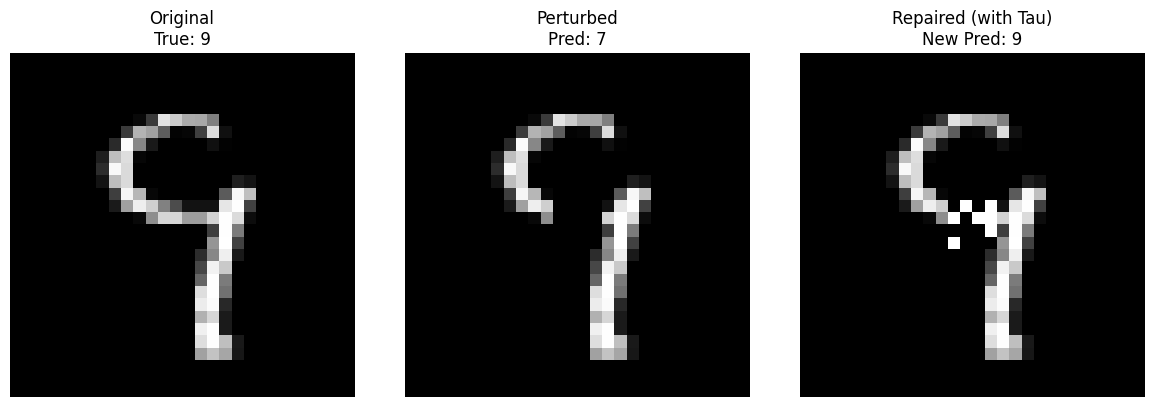


--- Case 18 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 1.0
Optimization Time: 6.0668 seconds
Successfully restored!


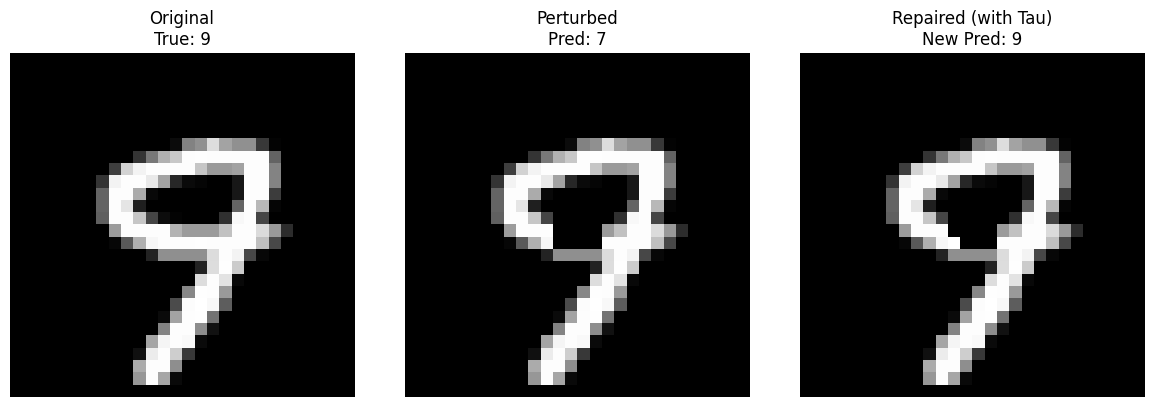


--- Case 19 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 7.0074 seconds
Successfully restored!


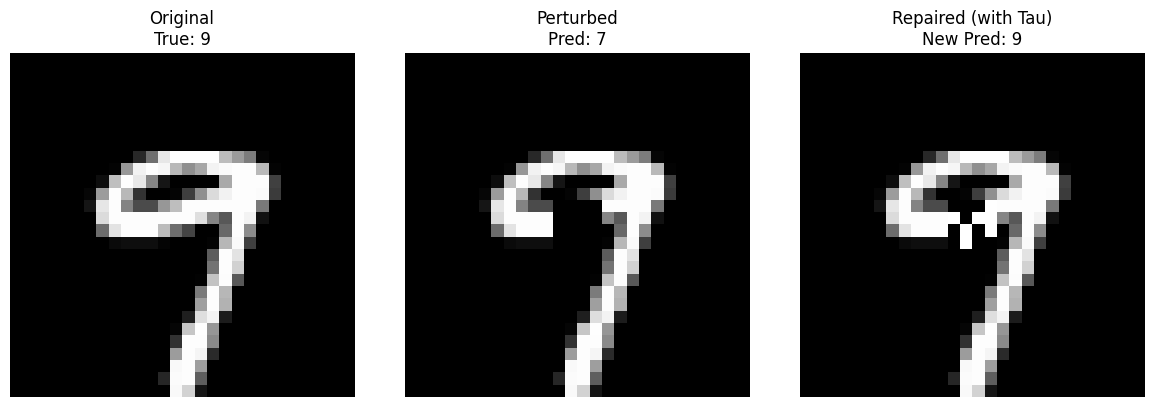


--- Case 20 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.7126 seconds
Successfully restored!


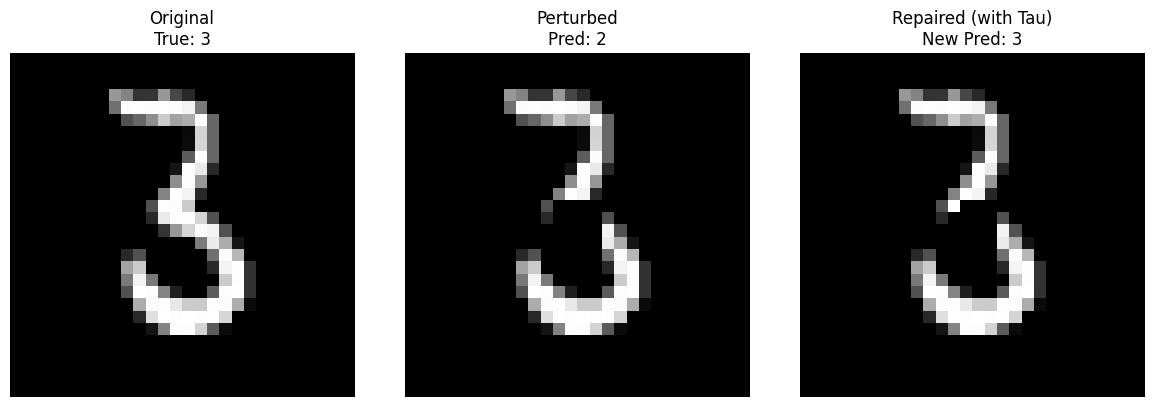


--- Case 21 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 2.0
Optimization Time: 6.3929 seconds
Successfully restored!


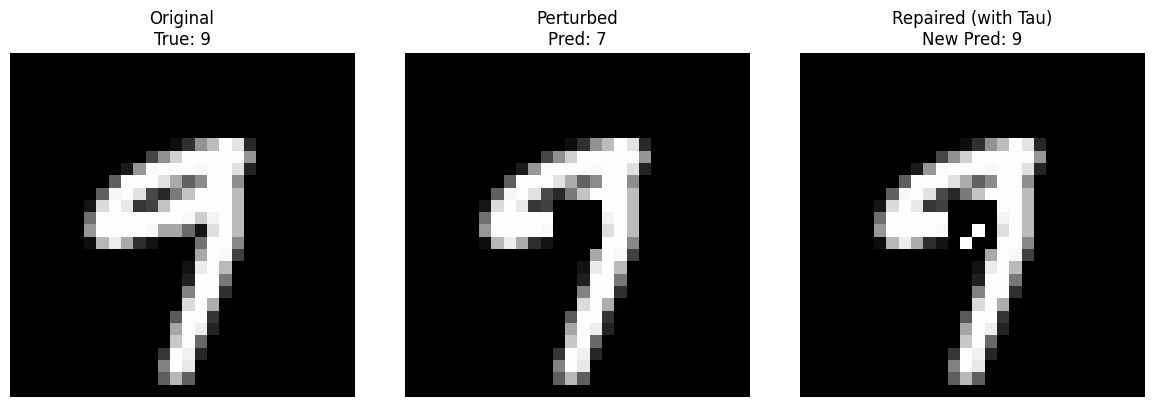


--- Case 22 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 8.0
Optimization Time: 6.4927 seconds
Successfully restored!


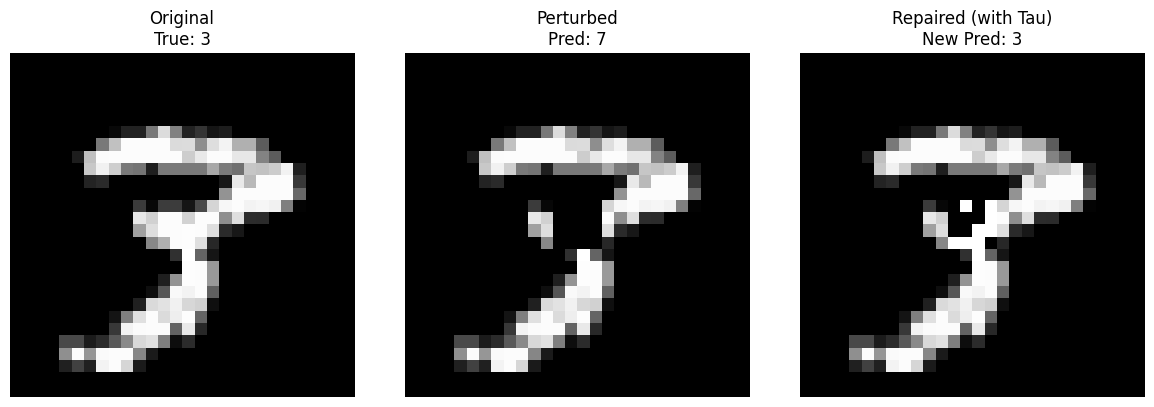


--- Case 23 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 2.0
Optimization Time: 7.4234 seconds
Successfully restored!


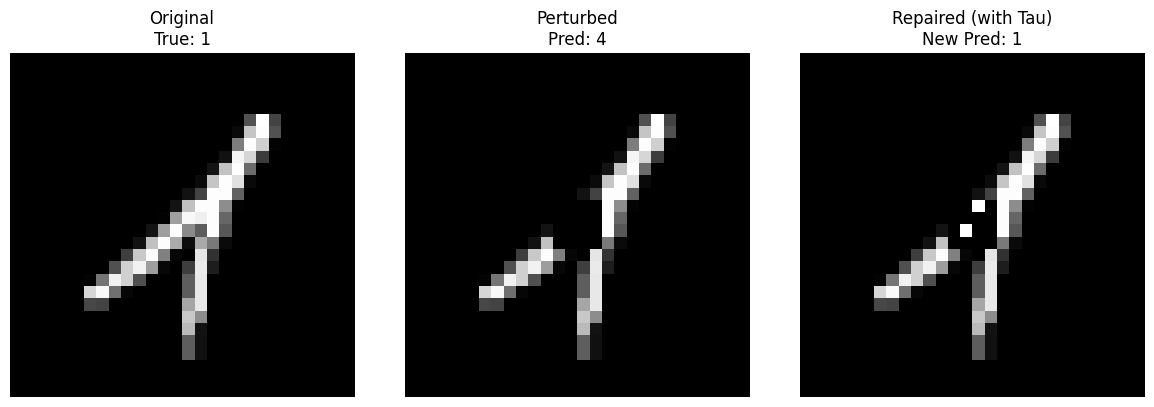


--- Case 24 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 8.0
Optimization Time: 6.2104 seconds
Successfully restored!


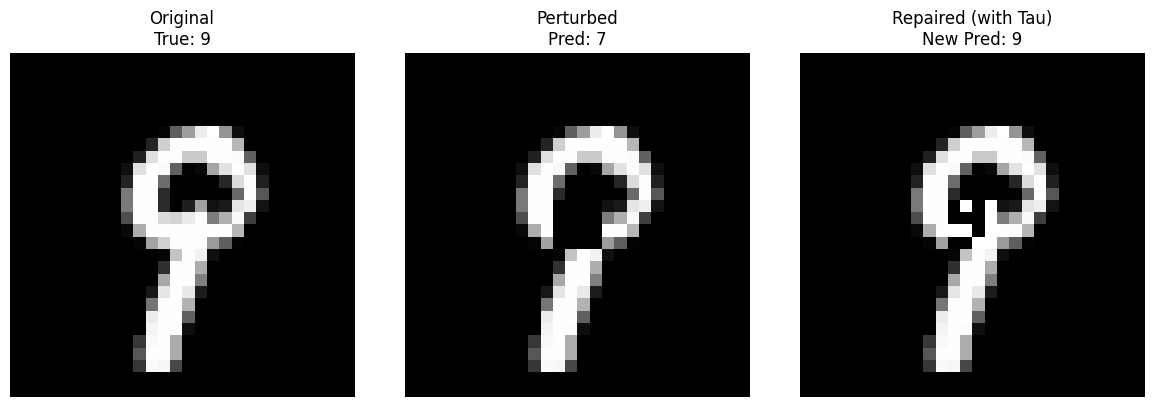


--- Case 25 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.8294 seconds
Successfully restored!


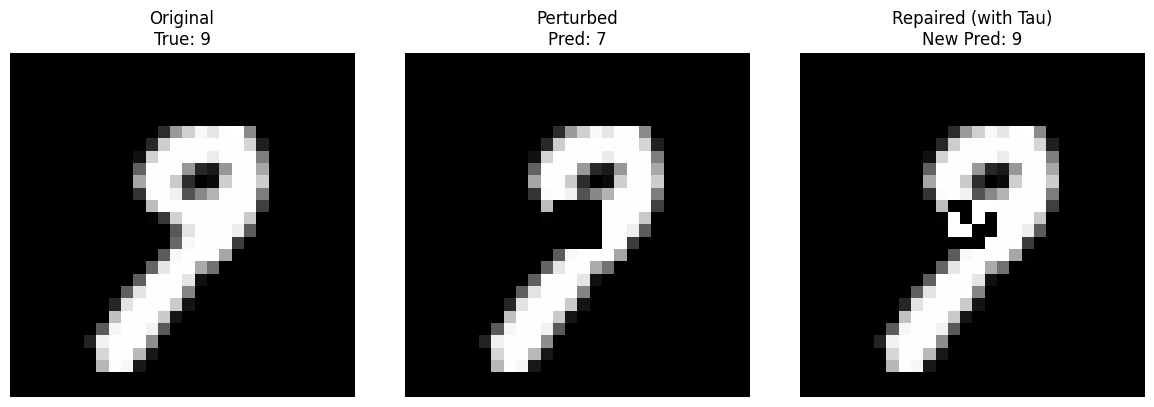


--- Case 26 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 9.0
Optimization Time: 11.3298 seconds
Successfully restored!


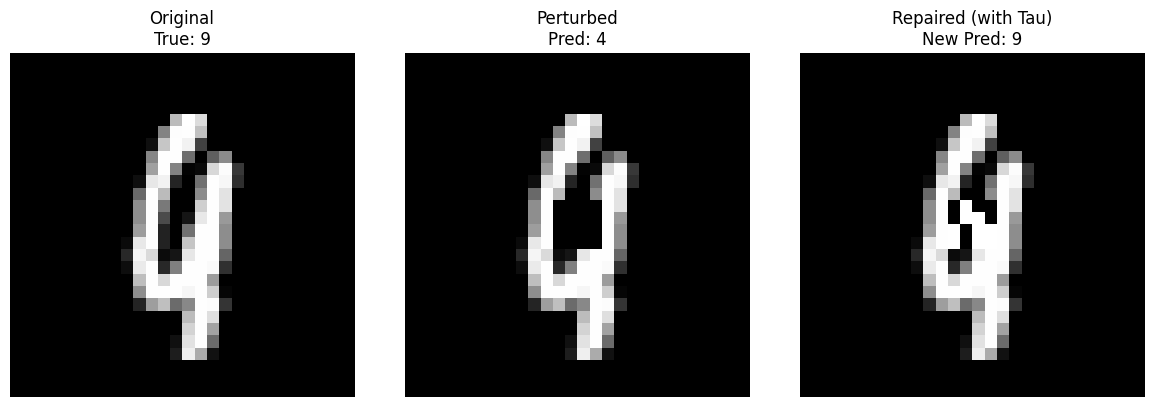


--- Case 27 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.0
Optimization Time: 6.9301 seconds
Successfully restored!


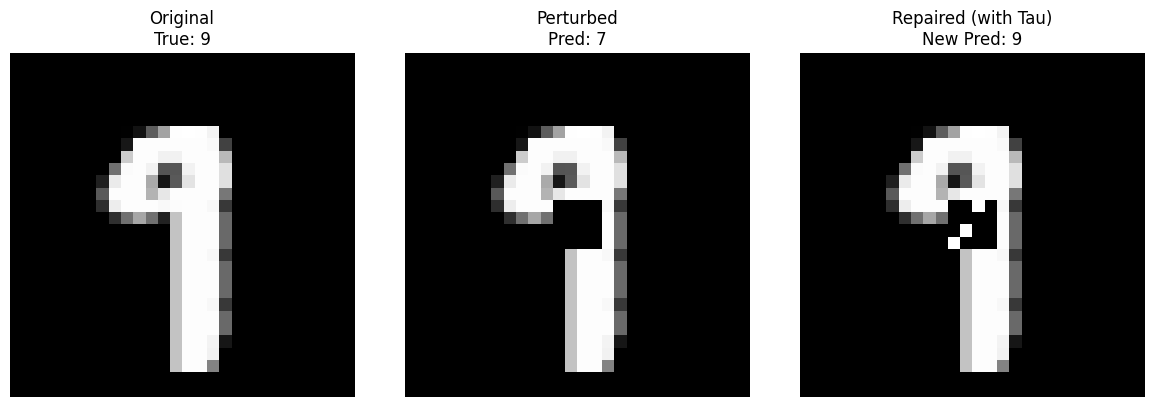


--- Case 28 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.5131 seconds
Successfully restored!


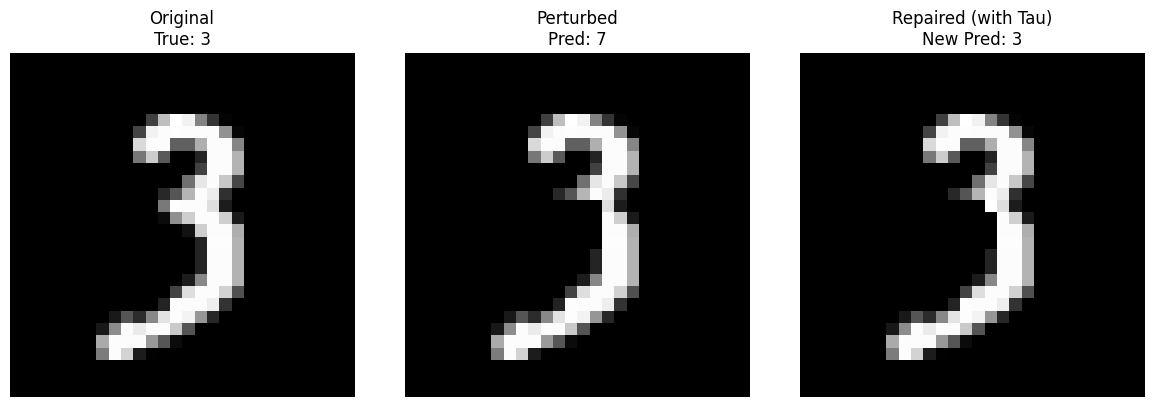


--- Case 29 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 9.0
Optimization Time: 6.6768 seconds
Successfully restored!


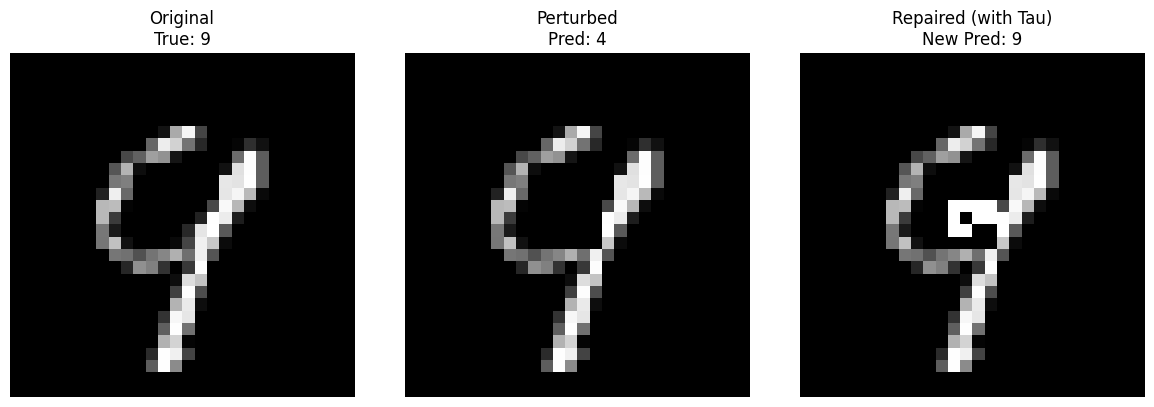


--- Case 30 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.0
Optimization Time: 6.1656 seconds
Successfully restored!


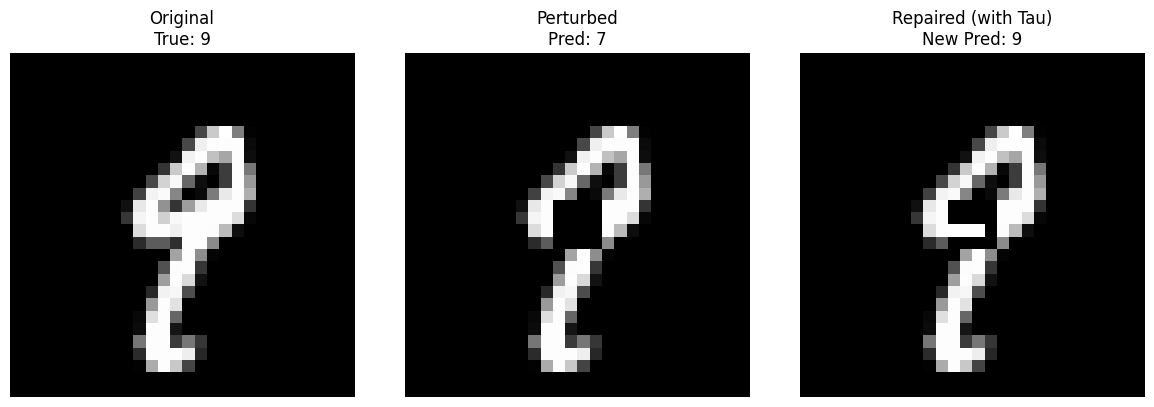


--- Case 31 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 7.0
Optimization Time: 6.5141 seconds
Successfully restored!


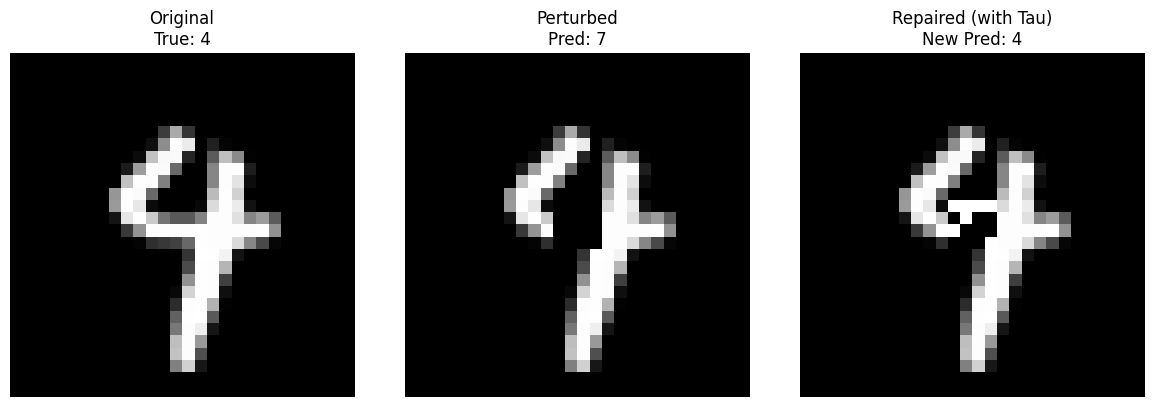


--- Case 32 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 8.0
Optimization Time: 6.3327 seconds
Successfully restored!


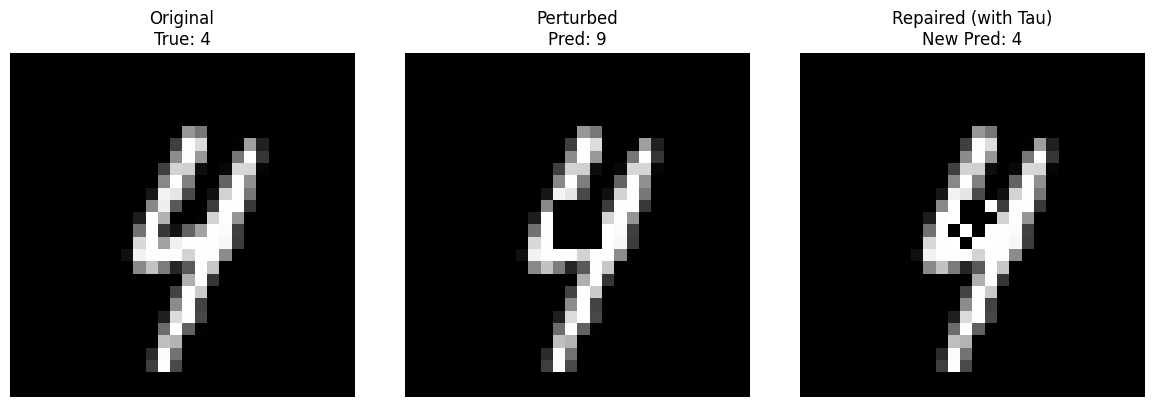


--- Case 33 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 3.0
Optimization Time: 6.7023 seconds
Successfully restored!


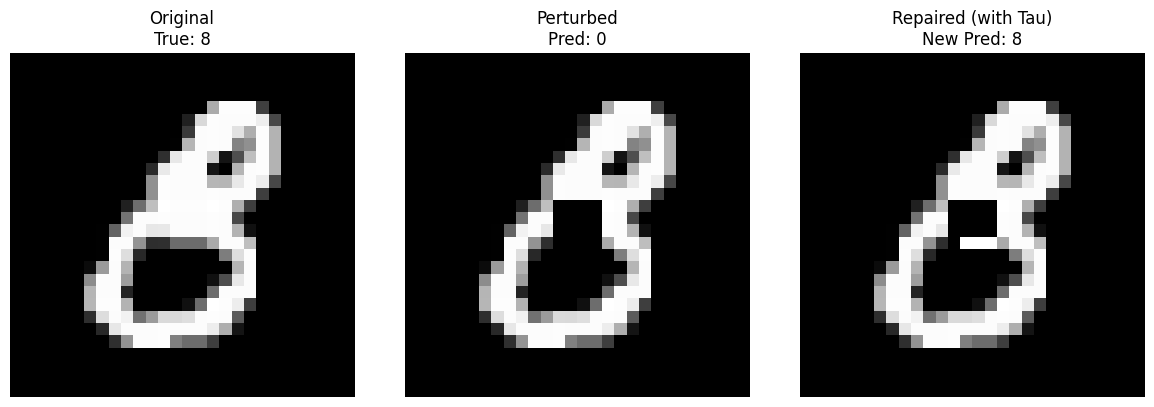


--- Case 34 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 4.0
Optimization Time: 6.6350 seconds
Successfully restored!


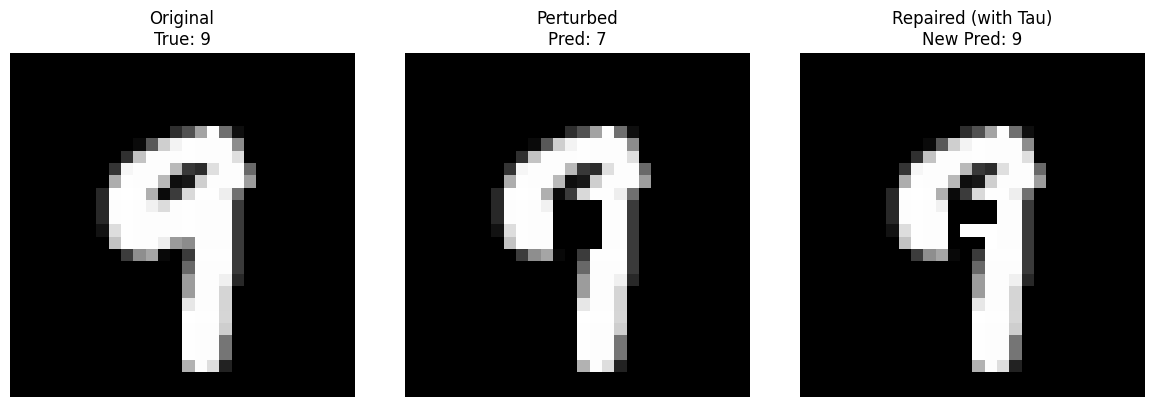


--- Case 35 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.0
Optimization Time: 6.1278 seconds
Successfully restored!


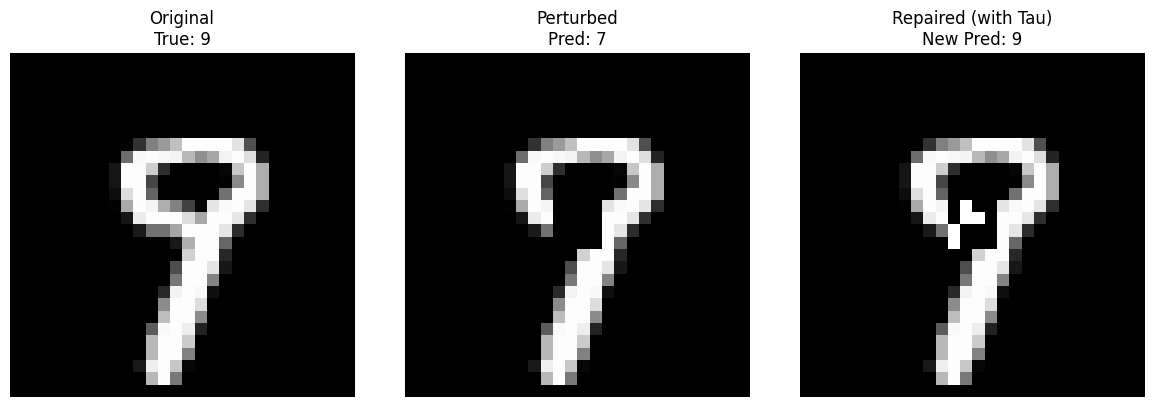


--- Case 36 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 8.0
Optimization Time: 6.0464 seconds
Successfully restored!


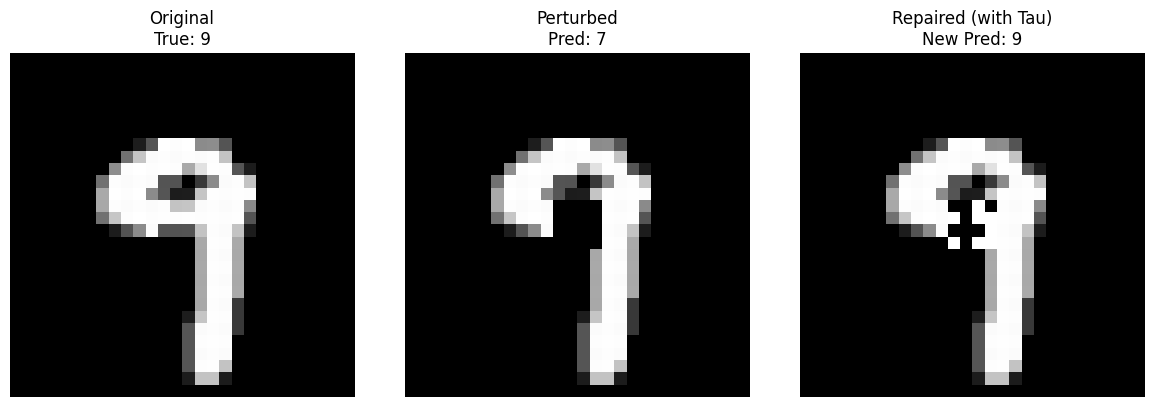


--- Case 37 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.0
Optimization Time: 6.8608 seconds
Successfully restored!


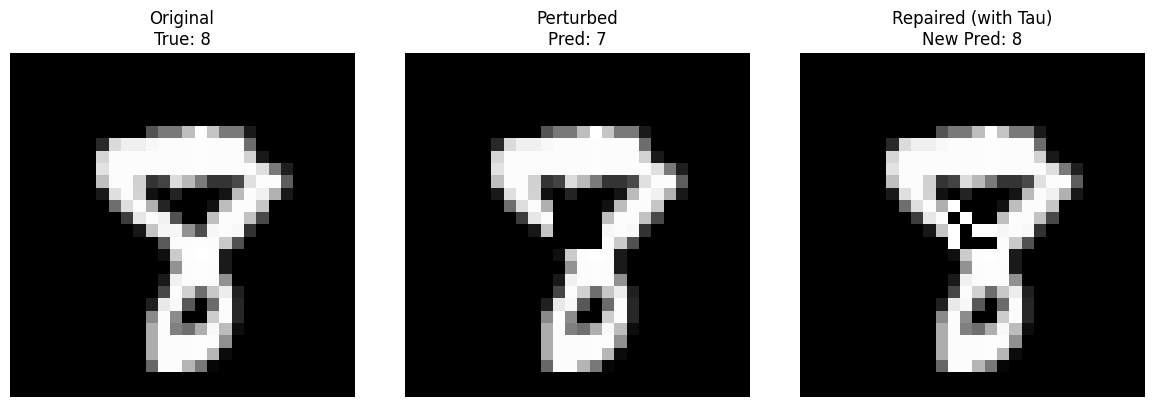


--- Case 38 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.0
Optimization Time: 6.7612 seconds
Successfully restored!


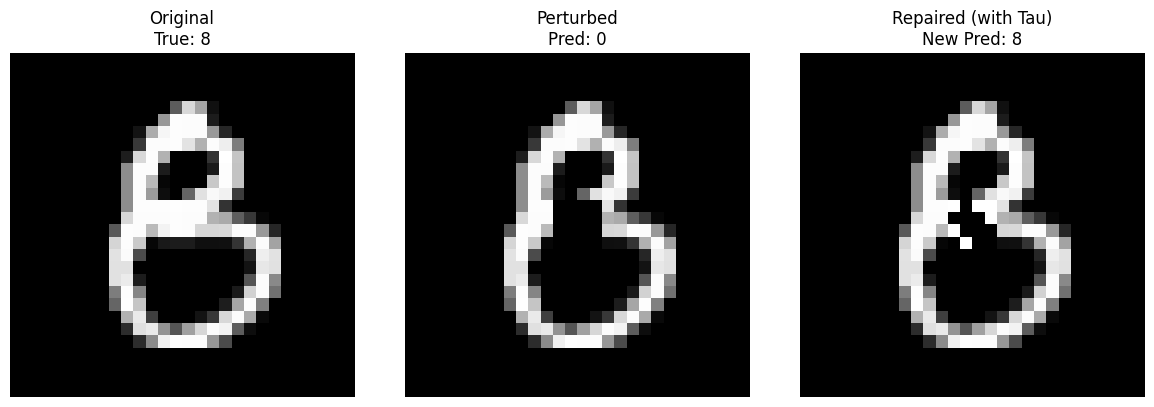


--- Case 39 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 6.0
Optimization Time: 6.3771 seconds
Successfully restored!


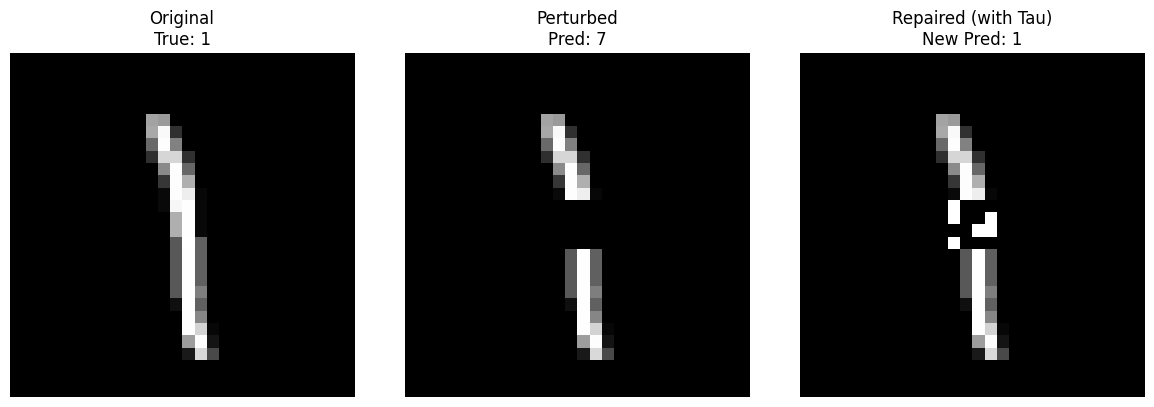


--- Case 40 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 11.0
Optimization Time: 6.5092 seconds
Successfully restored!


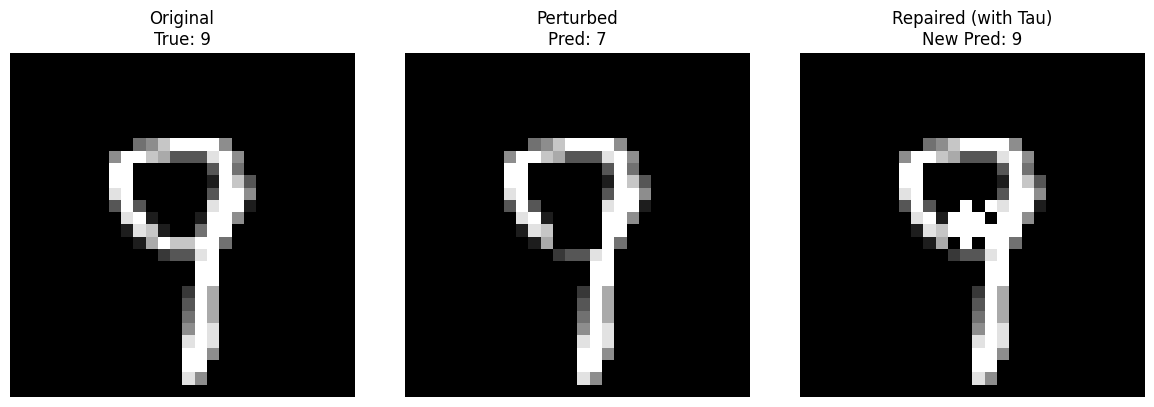


--- Case 41 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 8.0
Optimization Time: 6.2137 seconds
Successfully restored!


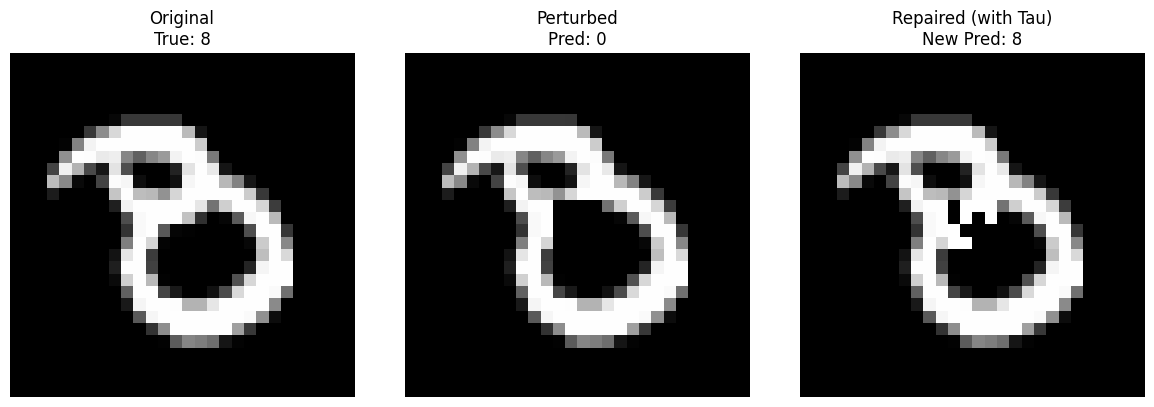


--- Case 42 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.0
Optimization Time: 7.1874 seconds
Successfully restored!


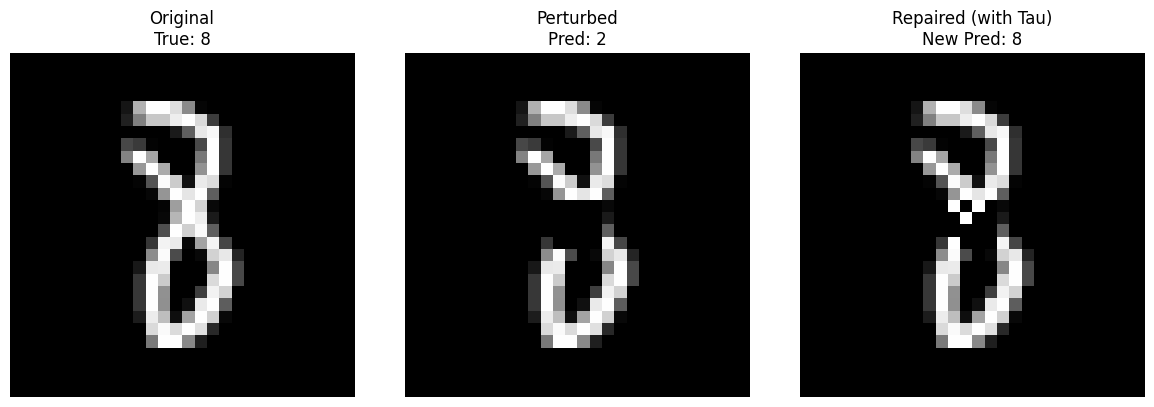


--- Case 43 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.0
Optimization Time: 6.6712 seconds
Successfully restored!


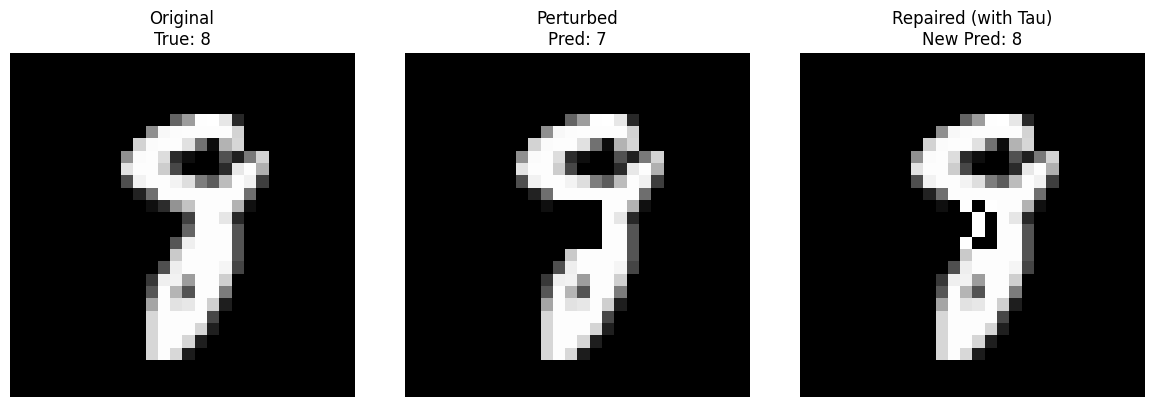


--- Case 44 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 7.3236 seconds
Successfully restored!


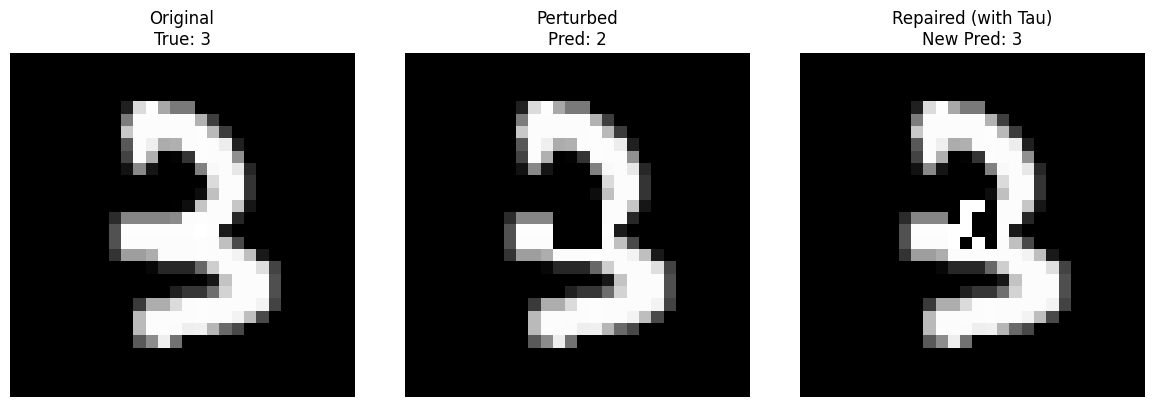


--- Case 45 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.7296 seconds
Successfully restored!


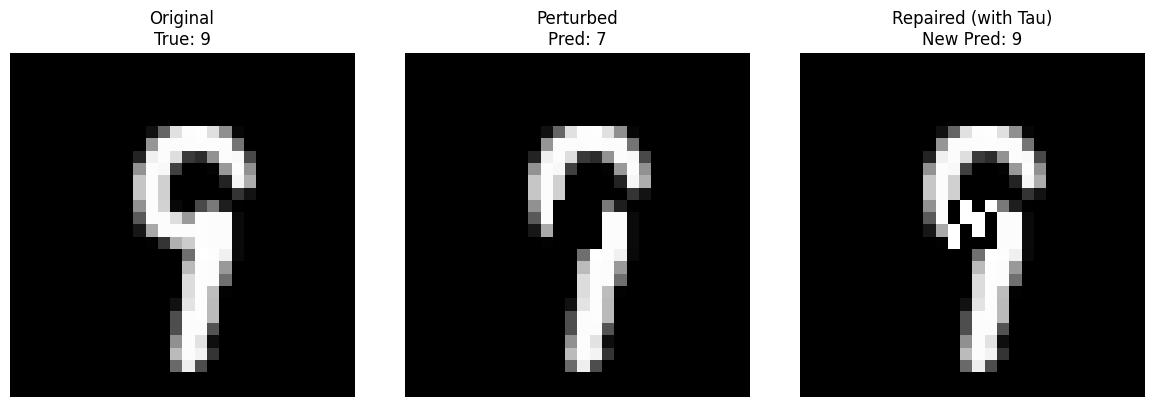


--- Case 46 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 1.0
Optimization Time: 5.1750 seconds
Successfully restored!


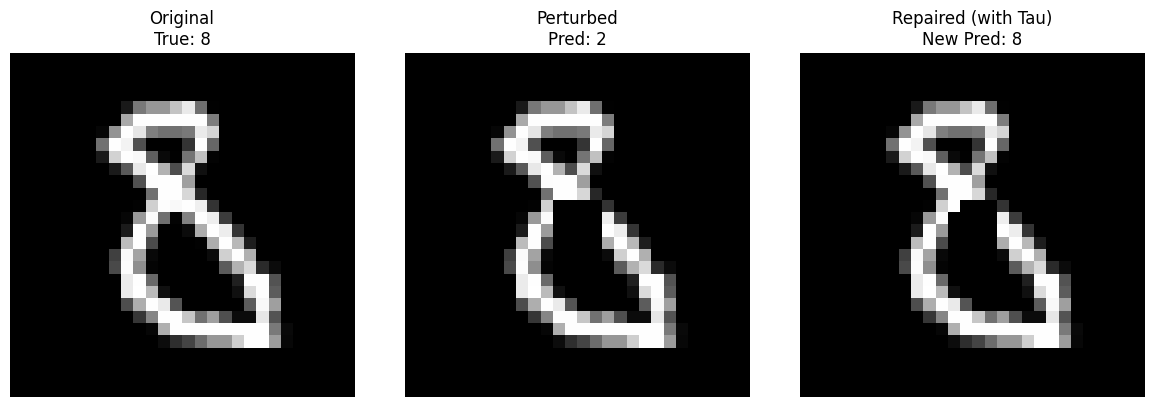


--- Case 47 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 2...
Pixels to add: 7.0
Optimization Time: 6.5933 seconds
Successfully restored!


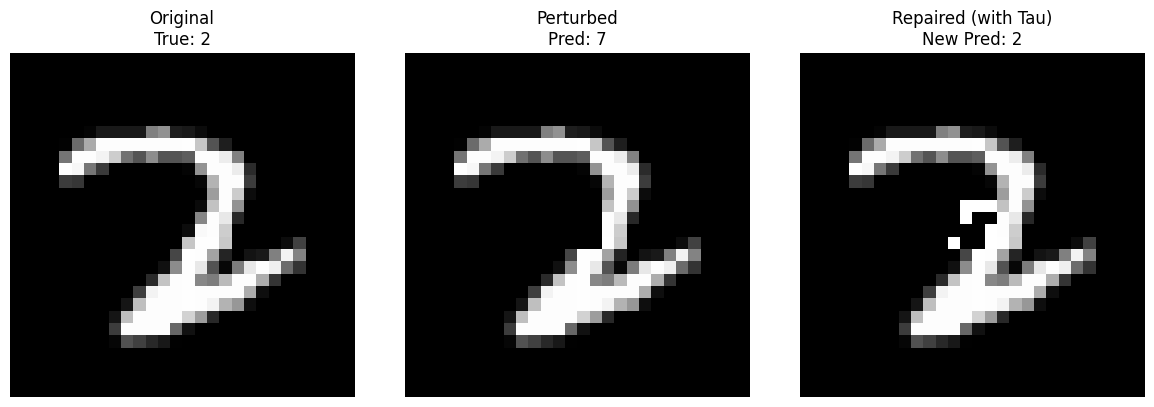


--- Case 48 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 1.0
Optimization Time: 5.2871 seconds
Successfully restored!


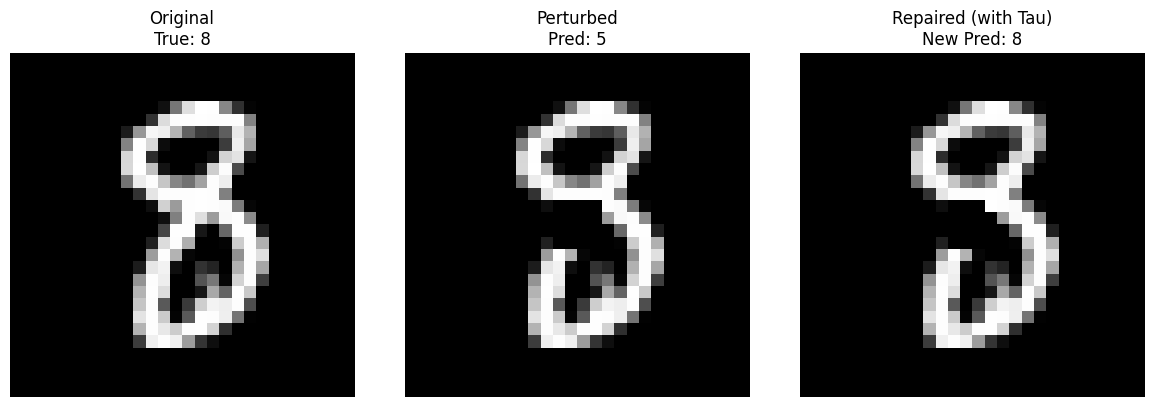


--- Case 49 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 15.0
Optimization Time: 8.8778 seconds
Successfully restored!


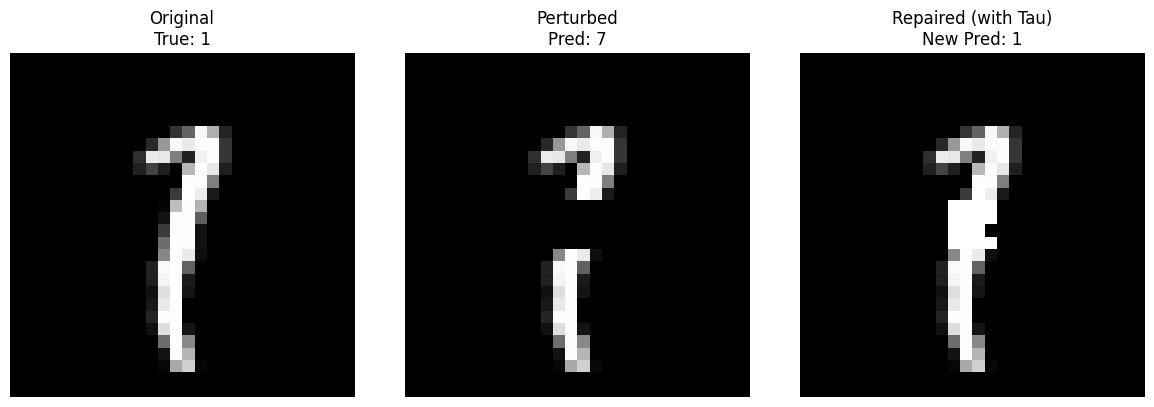


--- Case 50 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.6384 seconds
Successfully restored!


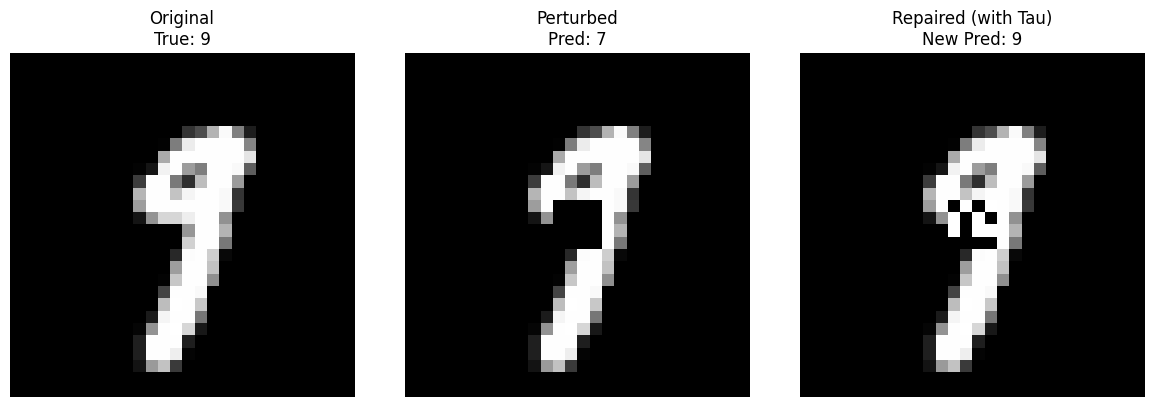


--- Case 51 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 1.0
Optimization Time: 5.2195 seconds
Successfully restored!


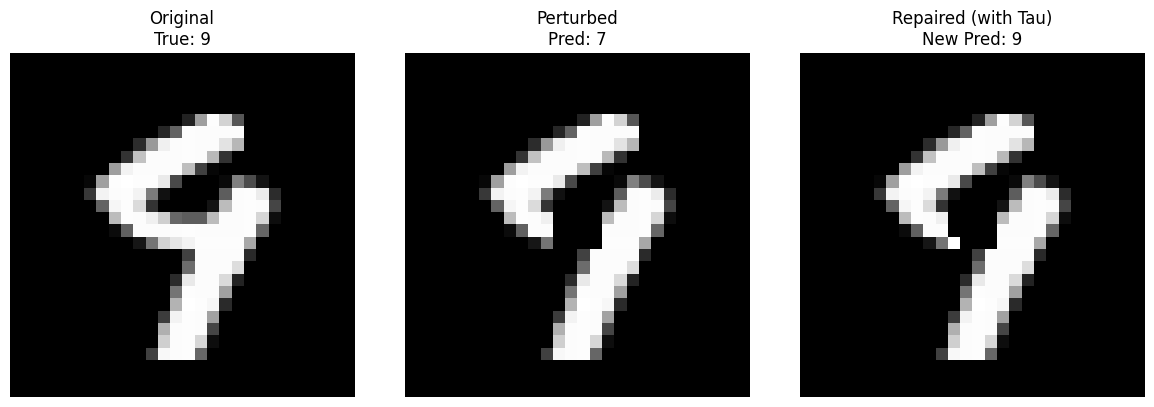


--- Case 52 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.0
Optimization Time: 6.2841 seconds
Successfully restored!


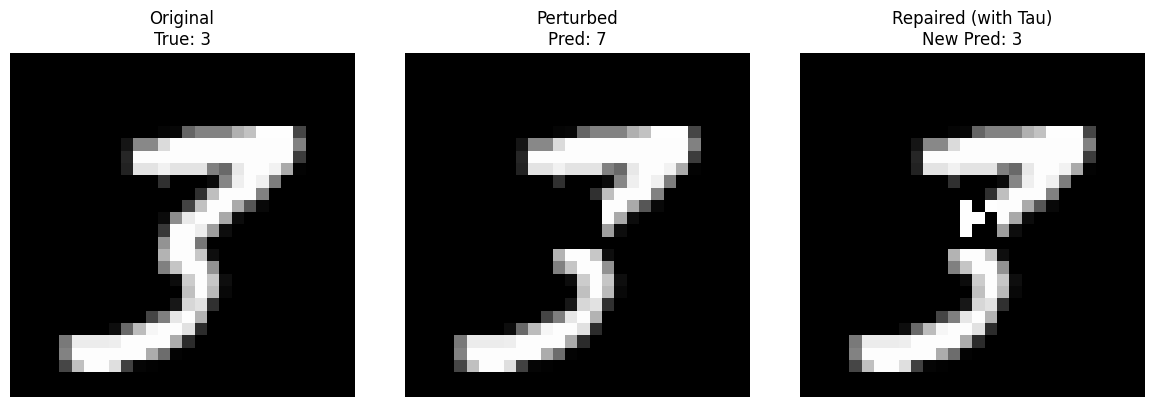


--- Case 53 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.0
Optimization Time: 6.8446 seconds
Successfully restored!


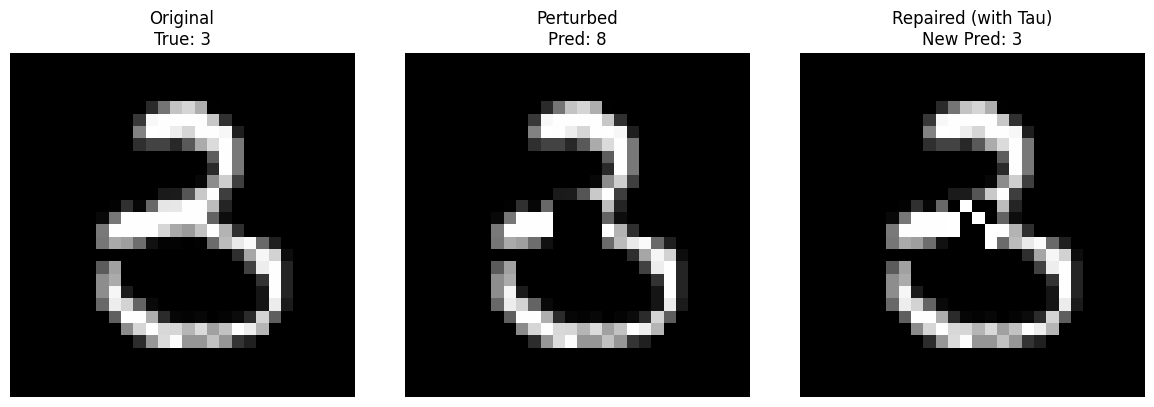


--- Case 54 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 1.0
Optimization Time: 5.3479 seconds
Successfully restored!


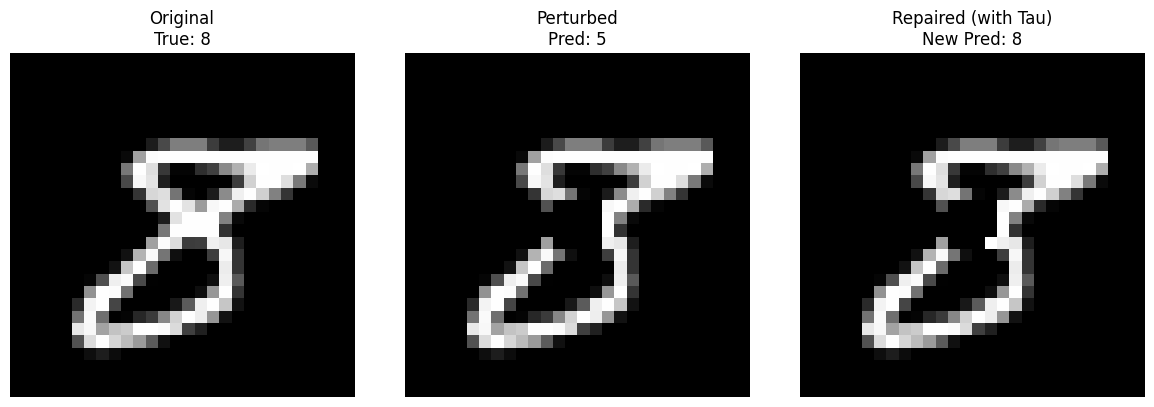


--- Case 55 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.0
Optimization Time: 6.7686 seconds
Successfully restored!


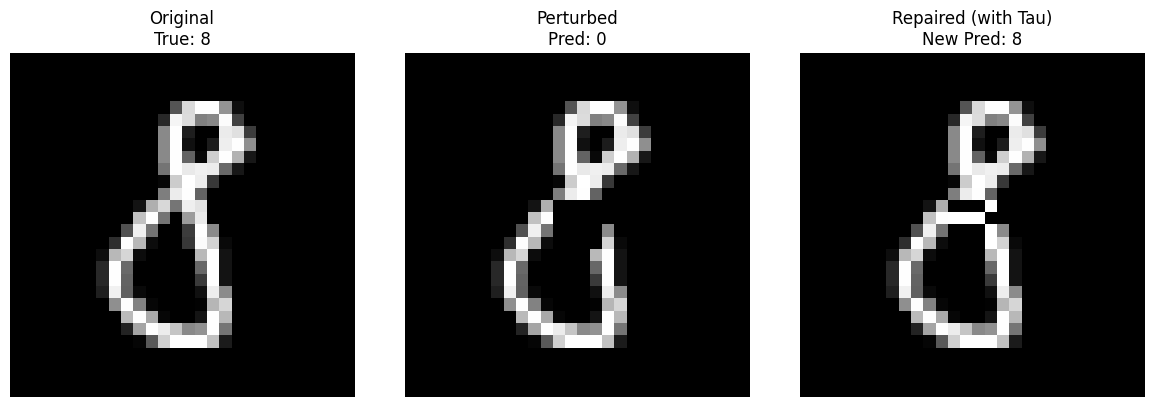


--- Case 56 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.0
Optimization Time: 7.1674 seconds
Successfully restored!


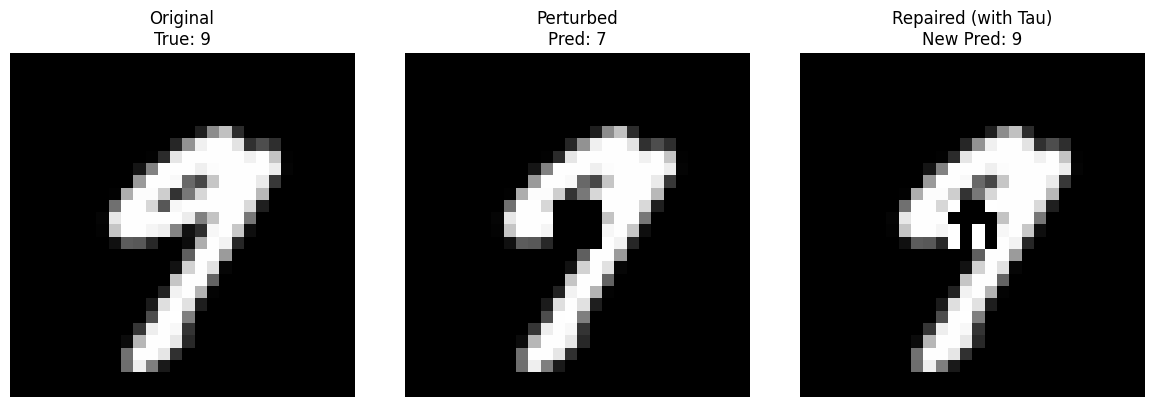


--- Case 57 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.0
Optimization Time: 48.9304 seconds
Successfully restored!


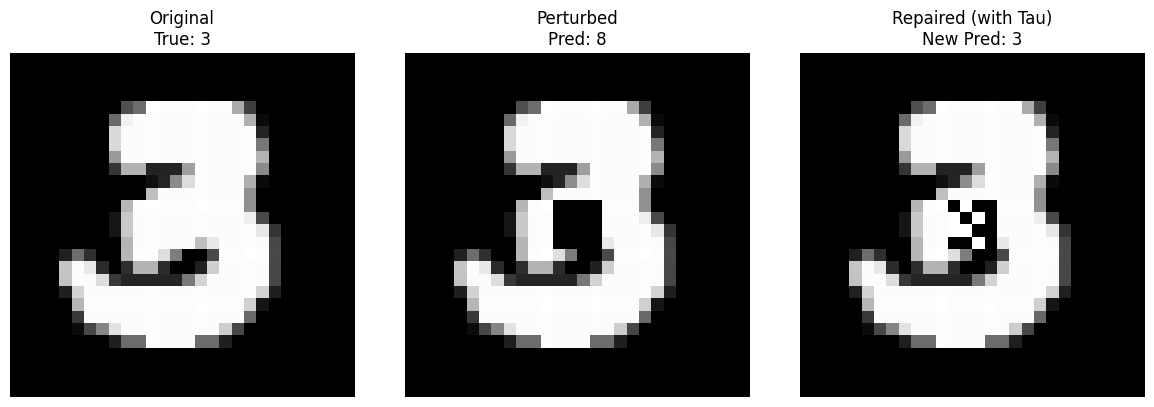


--- Case 58 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.0
Optimization Time: 7.8020 seconds
Successfully restored!


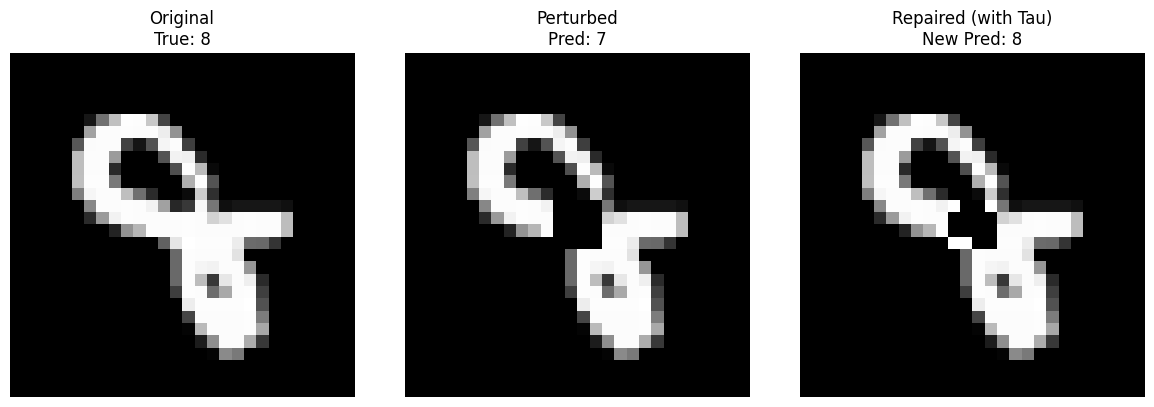


--- Case 59 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 16.2616 seconds
Successfully restored!


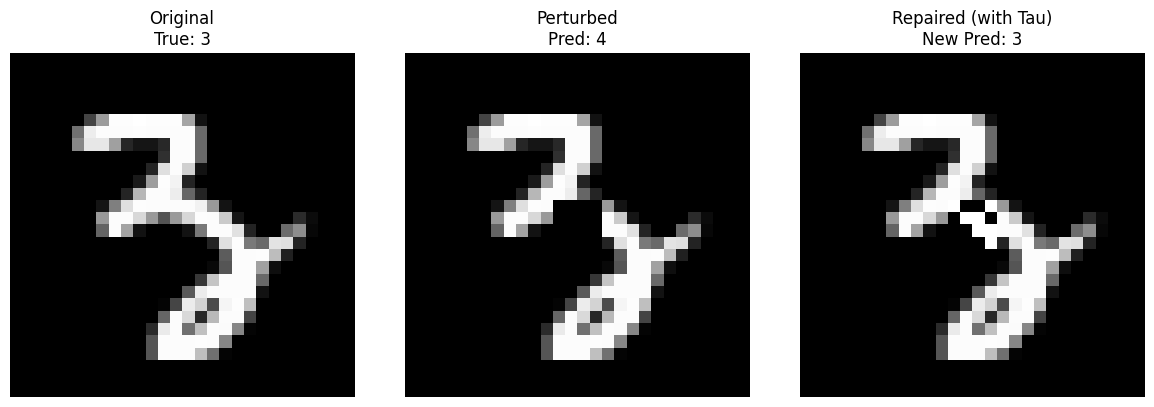


--- Case 60 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 9.0
Optimization Time: 7.1226 seconds
Successfully restored!


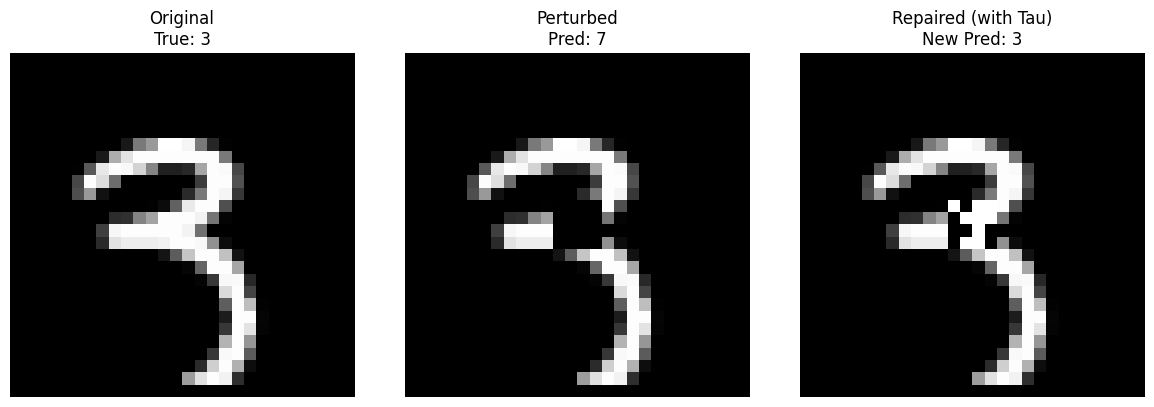


--- Case 61 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 6.6404 seconds
Successfully restored!


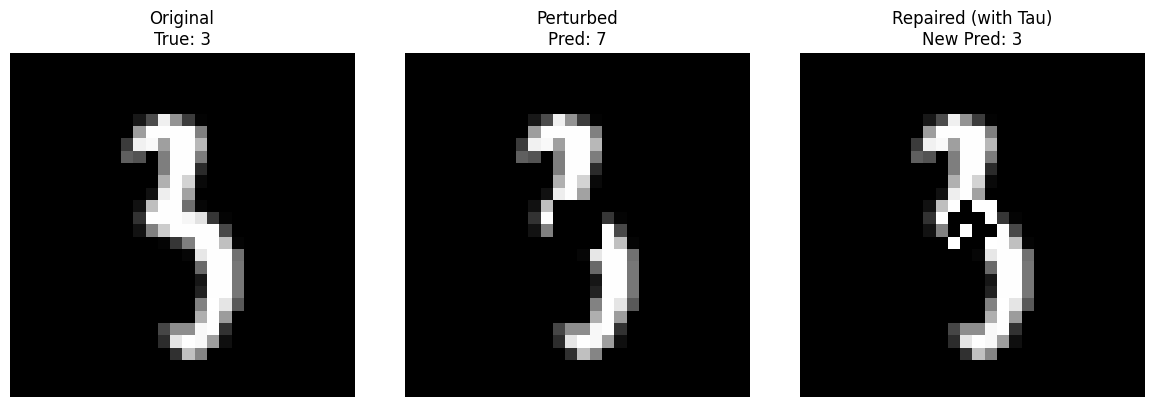


--- Case 62 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.4125 seconds
Successfully restored!


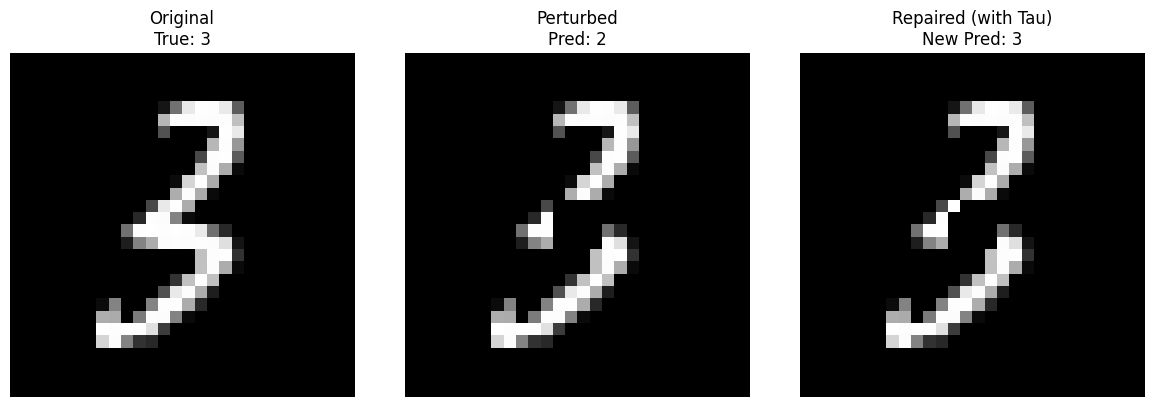


--- Case 63 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.0
Optimization Time: 6.5870 seconds
Successfully restored!


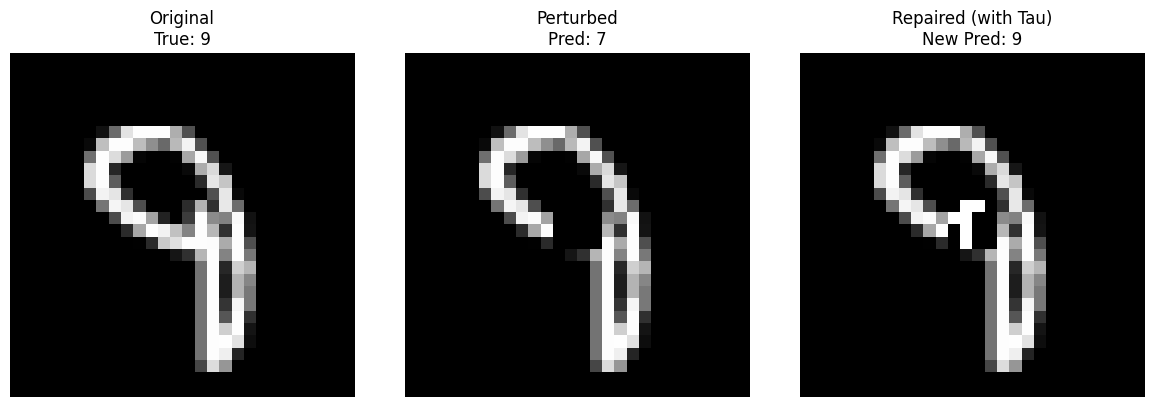


--- Case 64 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 3.0
Optimization Time: 7.0399 seconds
Successfully restored!


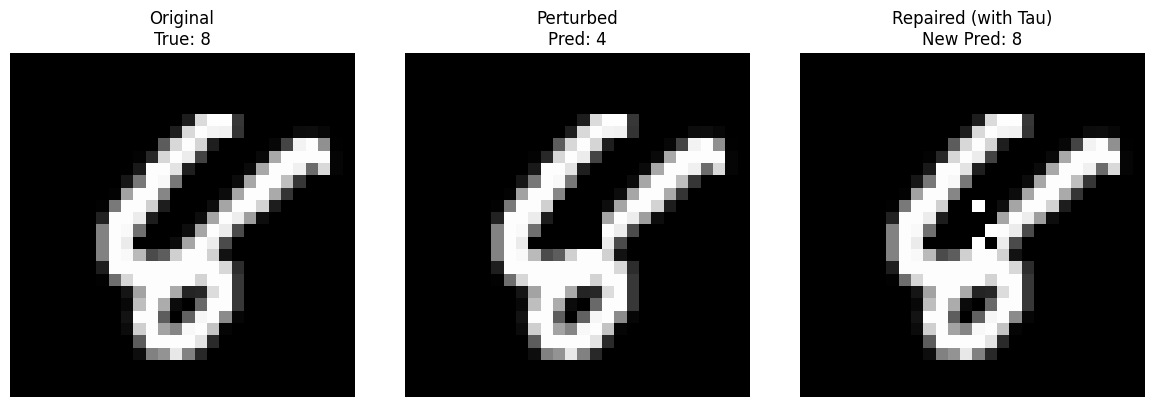


--- Case 65 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 6.6321 seconds
Successfully restored!


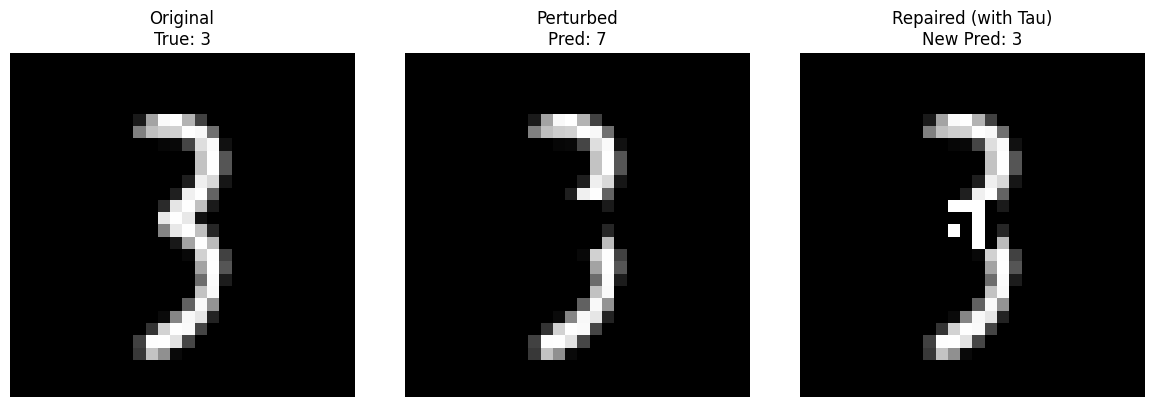


--- Case 66 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 8.0
Optimization Time: 7.0149 seconds
Successfully restored!


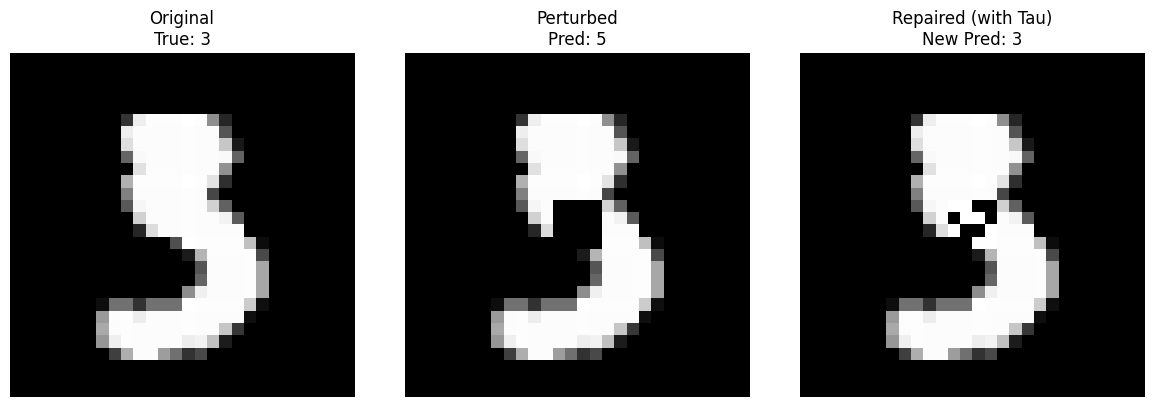


--- Case 67 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.0
Optimization Time: 6.6640 seconds
Successfully restored!


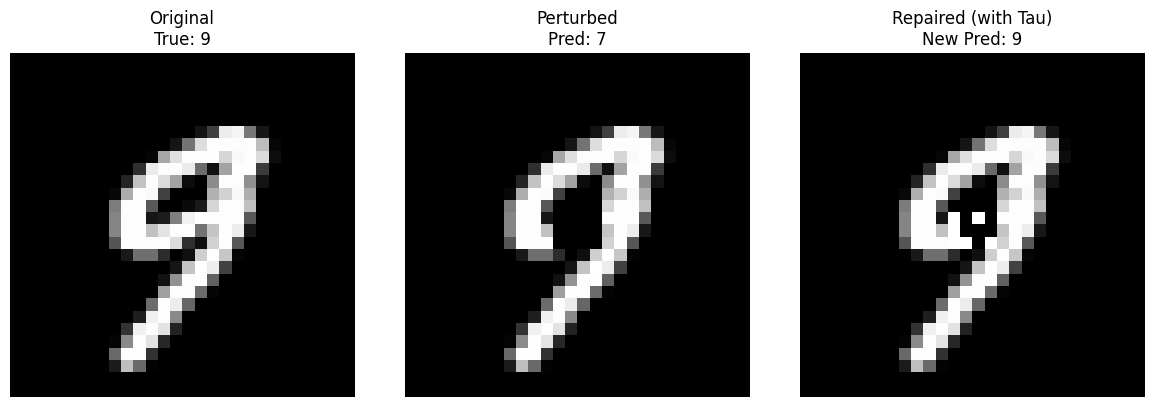


--- Case 68 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 8.0
Optimization Time: 65.6191 seconds
Successfully restored!


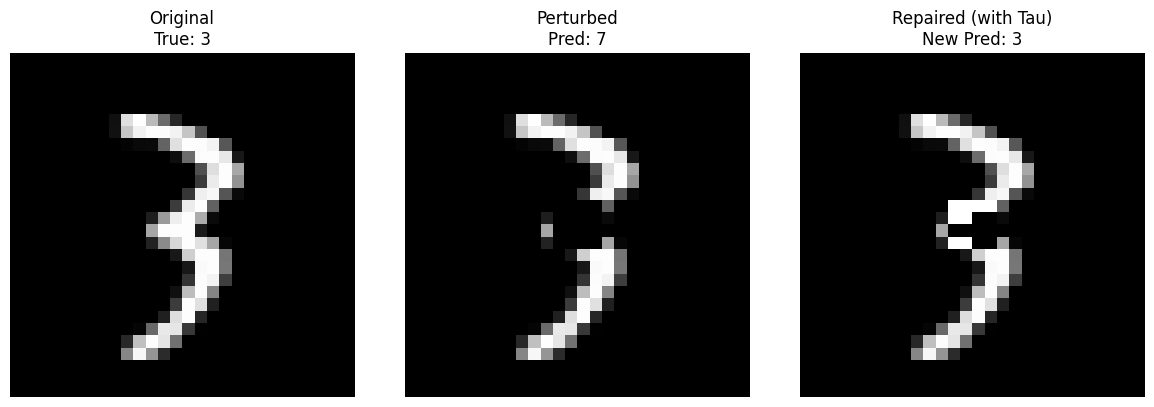


--- Case 69 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 4.0
Optimization Time: 7.2283 seconds
Successfully restored!


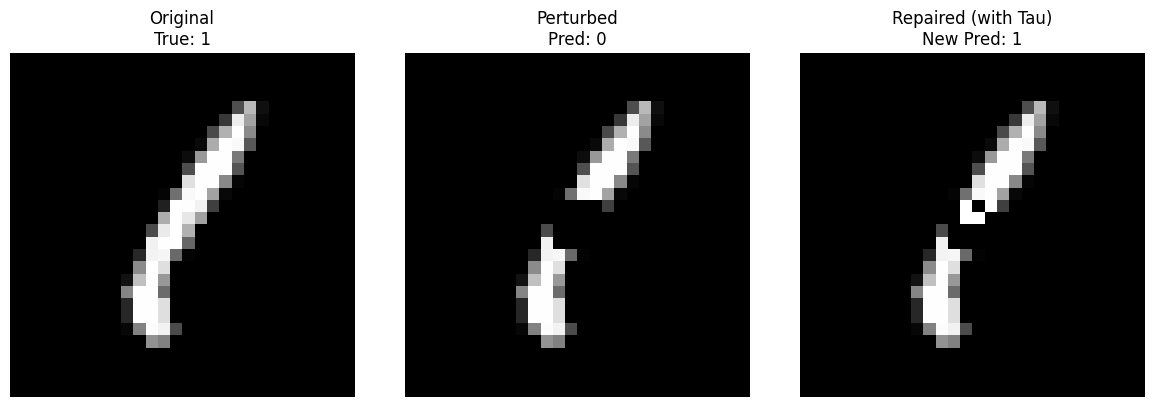


--- Case 70 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 5.0
Optimization Time: 6.5500 seconds
Successfully restored!


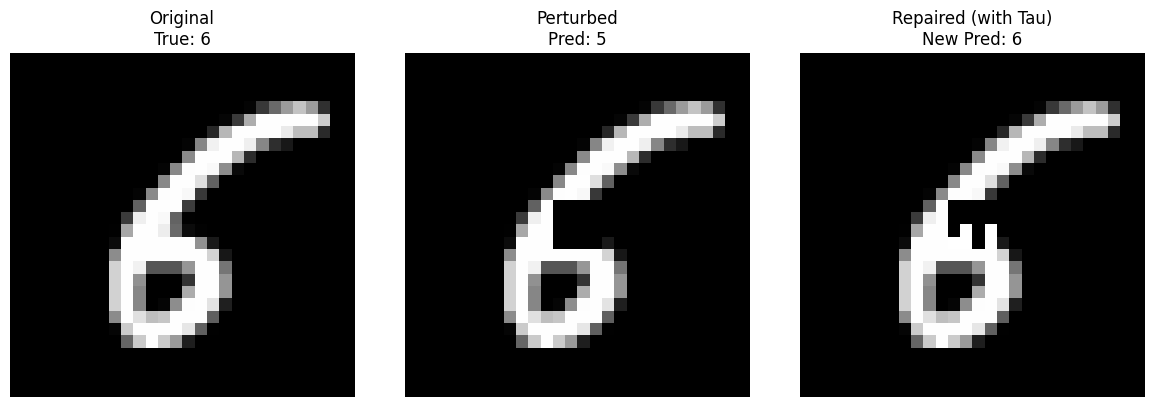


--- Case 71 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 1.0
Optimization Time: 5.4747 seconds
Successfully restored!


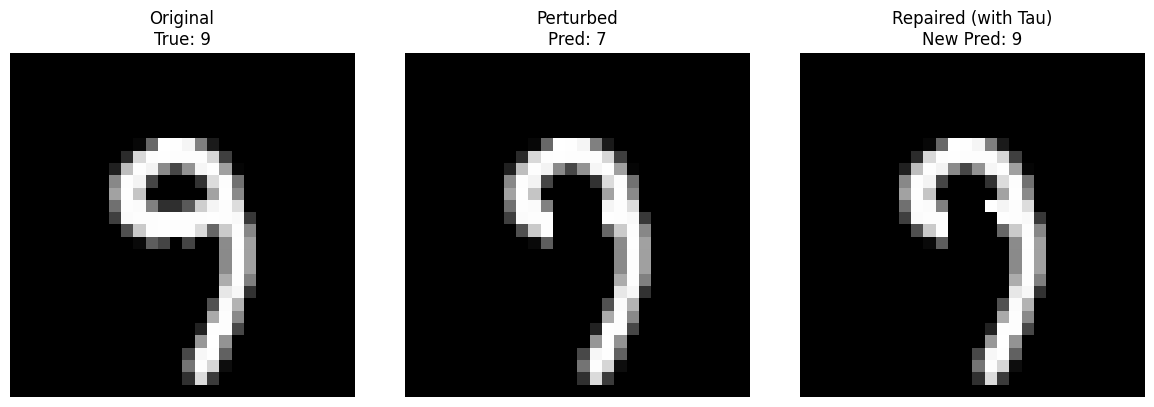


--- Case 72 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.0
Optimization Time: 6.4252 seconds
Successfully restored!


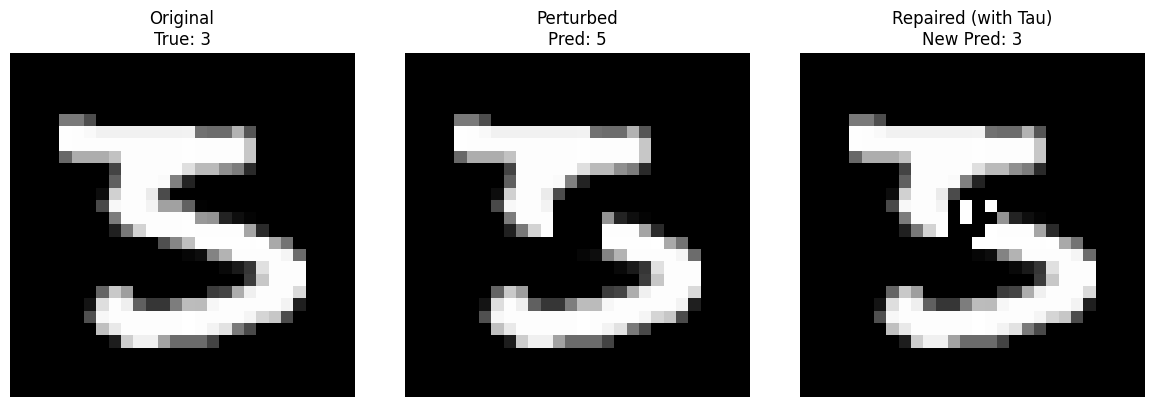


--- Case 73 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.0
Optimization Time: 6.2929 seconds
Successfully restored!


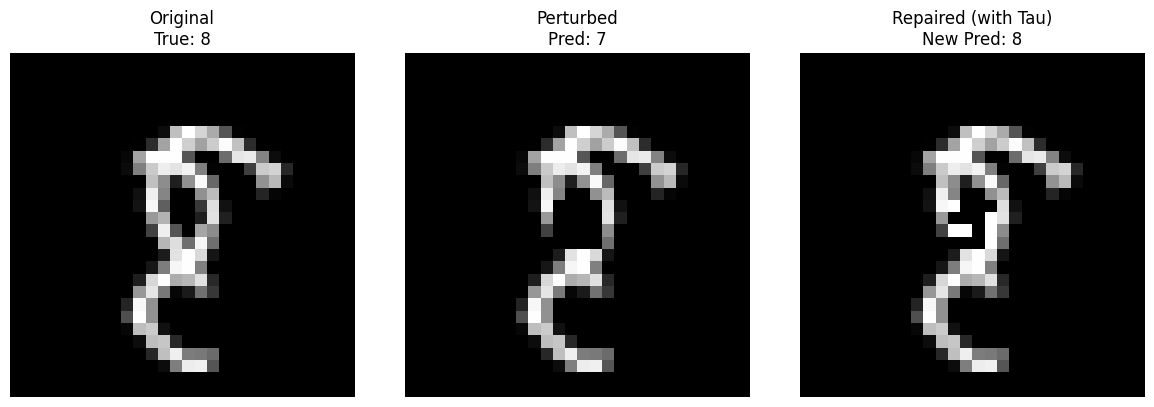


--- Case 74 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 9.0
Optimization Time: 6.8806 seconds
Successfully restored!


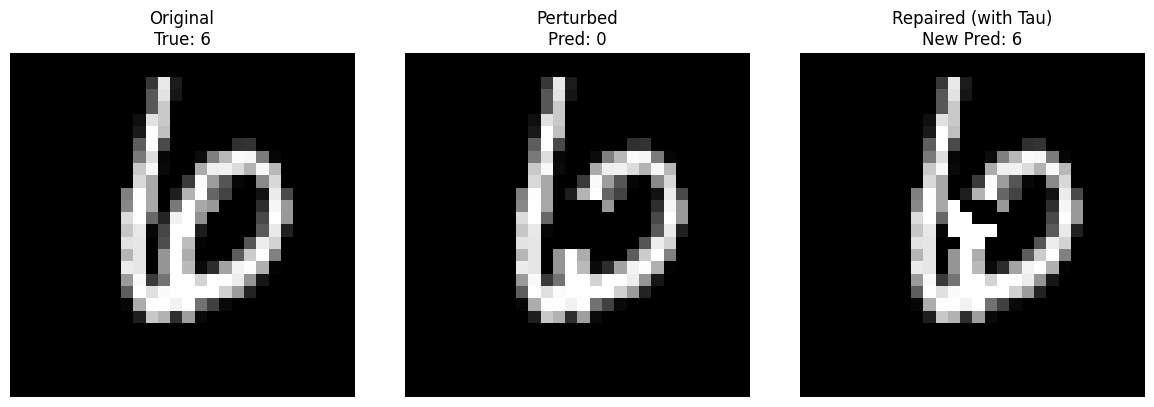


--- Case 75 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
No Repair Found (Status 9)
Optimization Time: 123.9029 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 76 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 8.0
Optimization Time: 6.5350 seconds
Successfully restored!


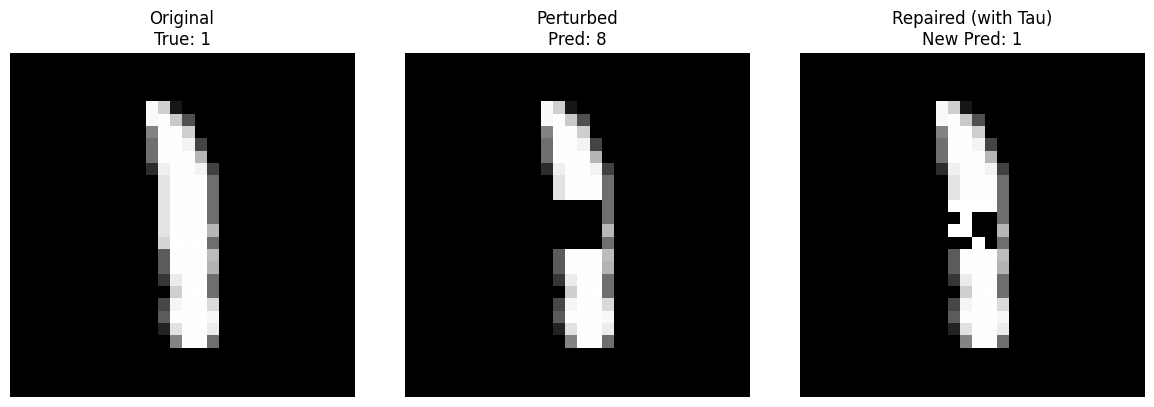


--- Case 77 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 6.6354 seconds
Successfully restored!


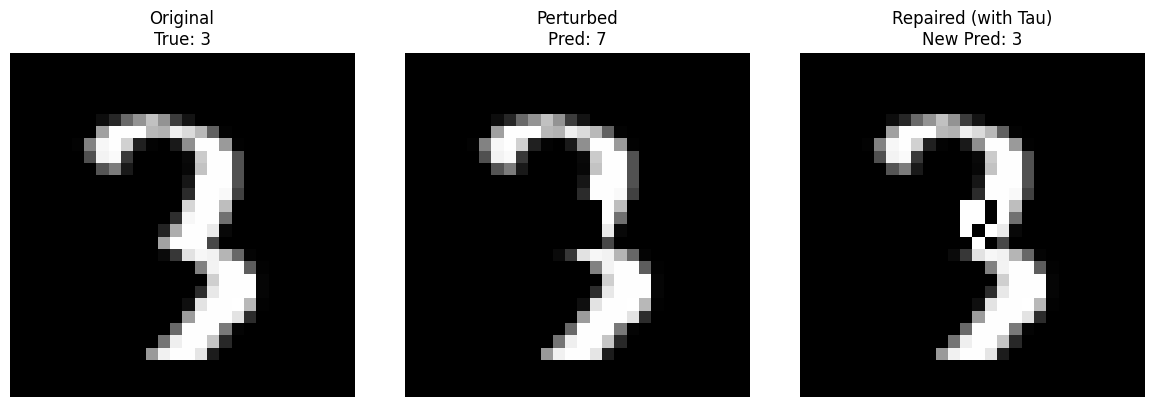


--- Case 78 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 6.3085 seconds
Successfully restored!


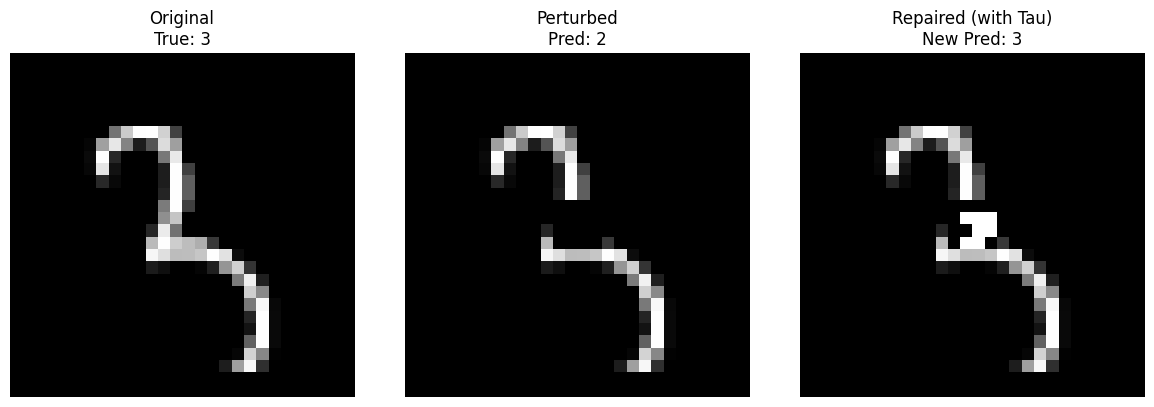


--- Case 79 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 1.0
Optimization Time: 5.5747 seconds
Successfully restored!


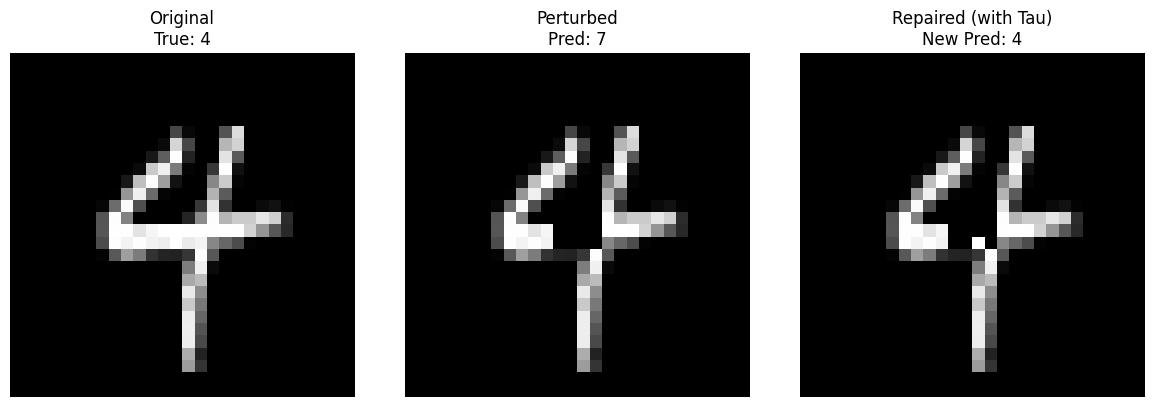


--- Case 80 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 1.0
Optimization Time: 5.9960 seconds
Successfully restored!


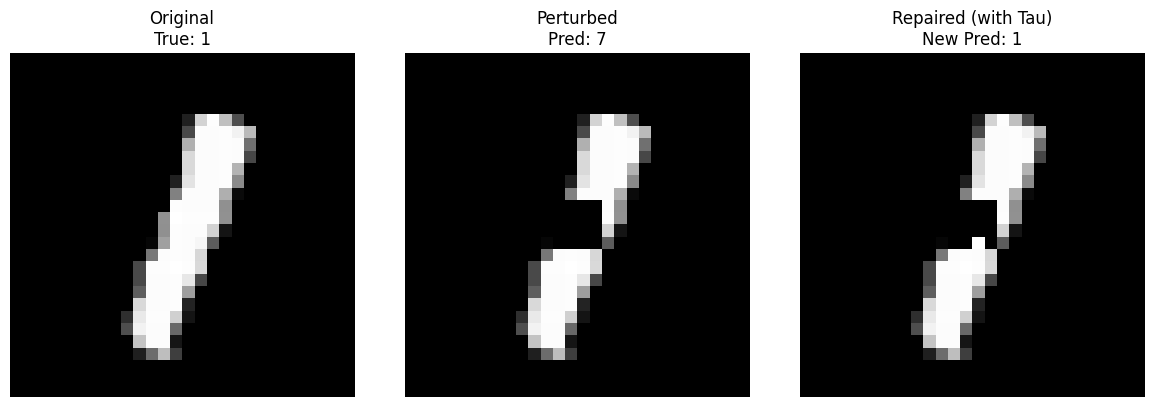


--- Case 81 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.7888 seconds
Successfully restored!


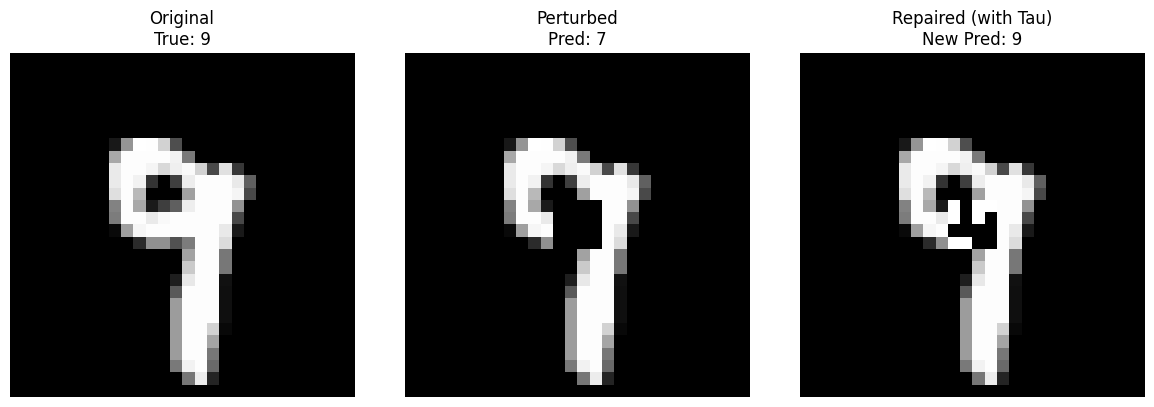


--- Case 82 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.0
Optimization Time: 6.6668 seconds
Successfully restored!


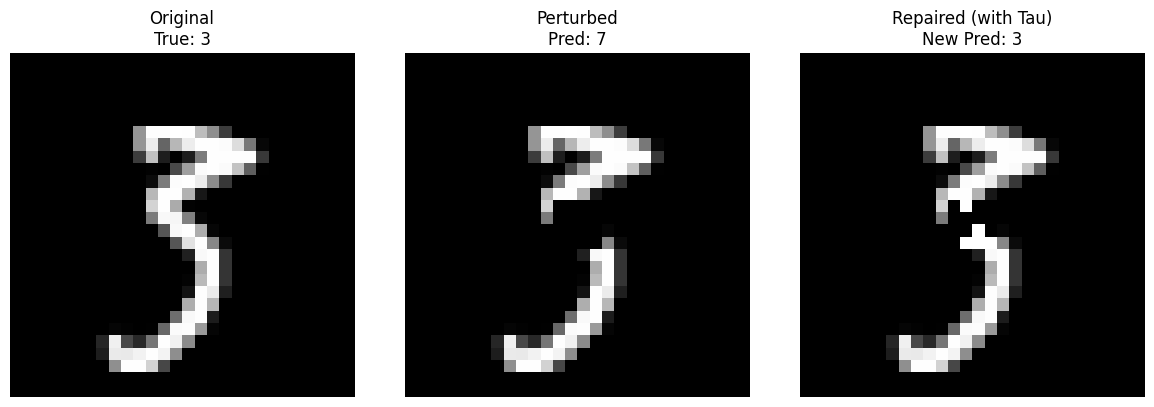


--- Case 83 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.0
Optimization Time: 6.9194 seconds
Successfully restored!


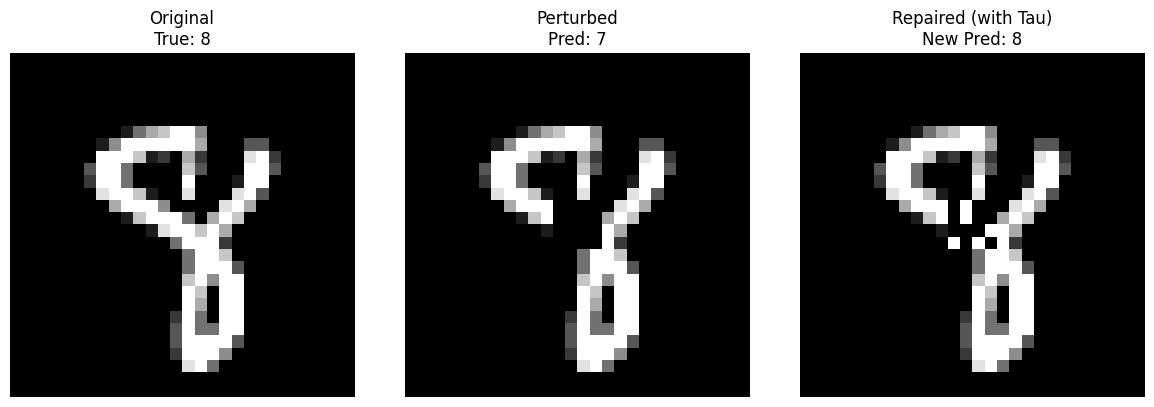


--- Case 84 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 7.0
Optimization Time: 6.6338 seconds
Successfully restored!


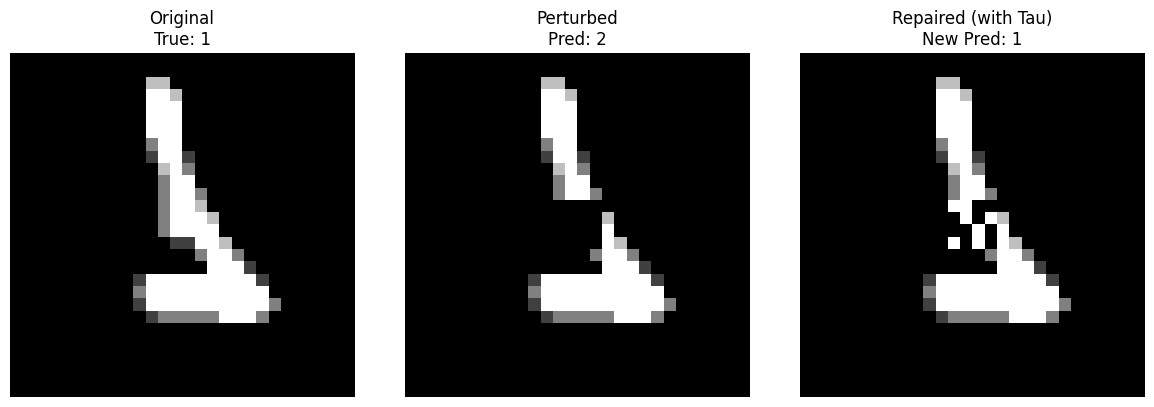


--- Case 85 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 8.0
Optimization Time: 7.1578 seconds
Successfully restored!


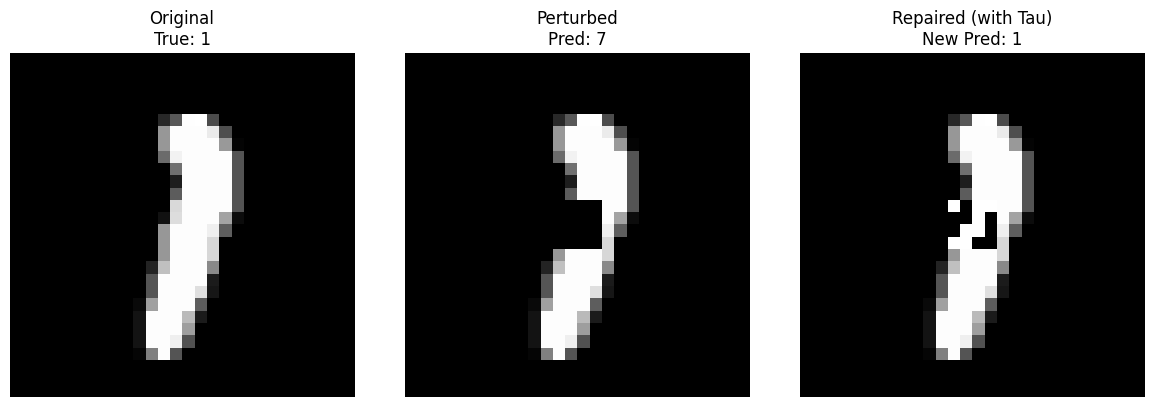


--- Case 86 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.0
Optimization Time: 6.9149 seconds
Successfully restored!


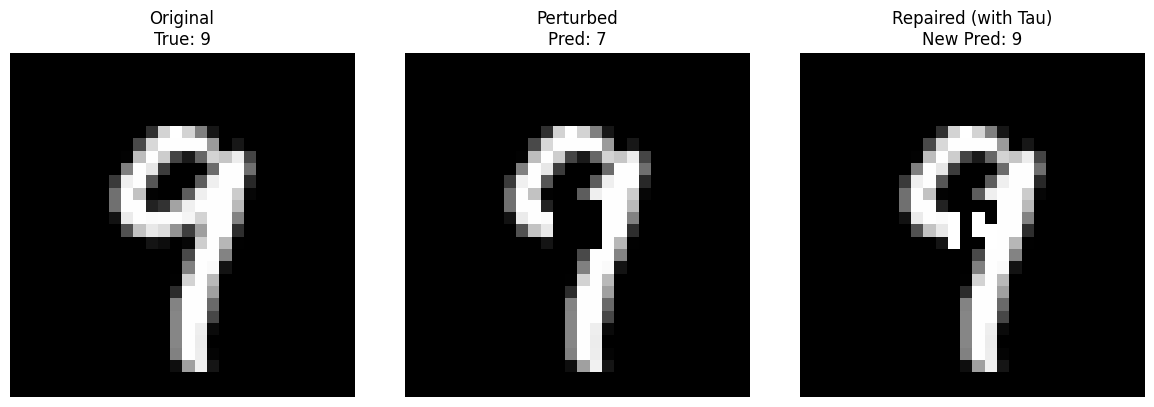


--- Case 87 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.0
Optimization Time: 7.1553 seconds
Successfully restored!


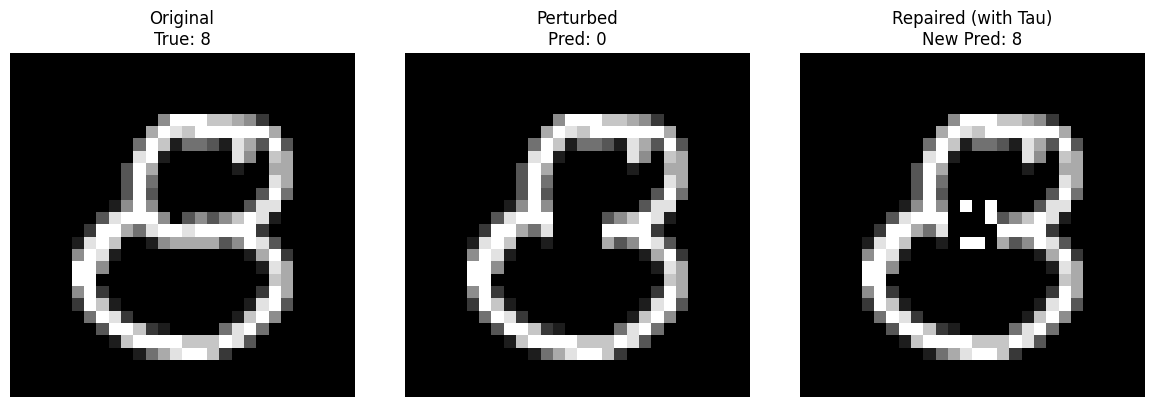


--- Case 88 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 2.0
Optimization Time: 7.5203 seconds
Successfully restored!


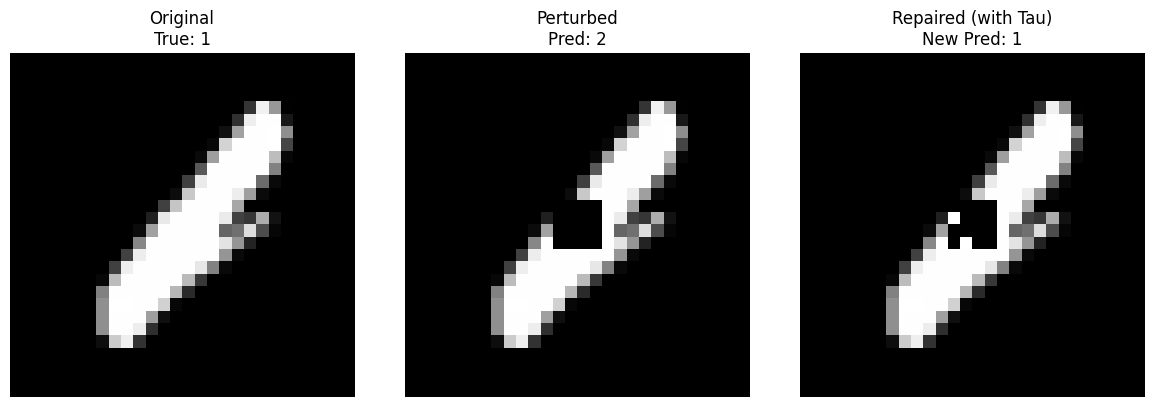


--- Case 89 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.0
Optimization Time: 5.5594 seconds
Successfully restored!


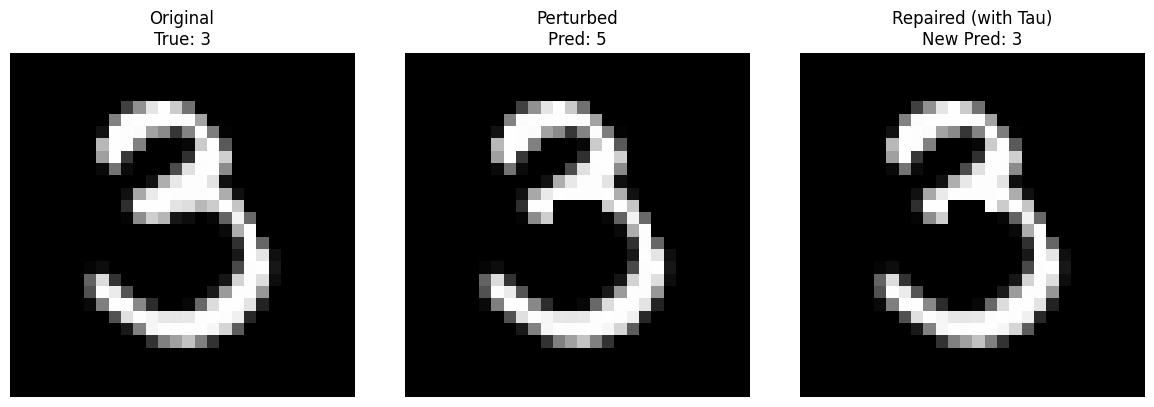


--- Case 90 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 10.0
Optimization Time: 7.5228 seconds
Successfully restored!


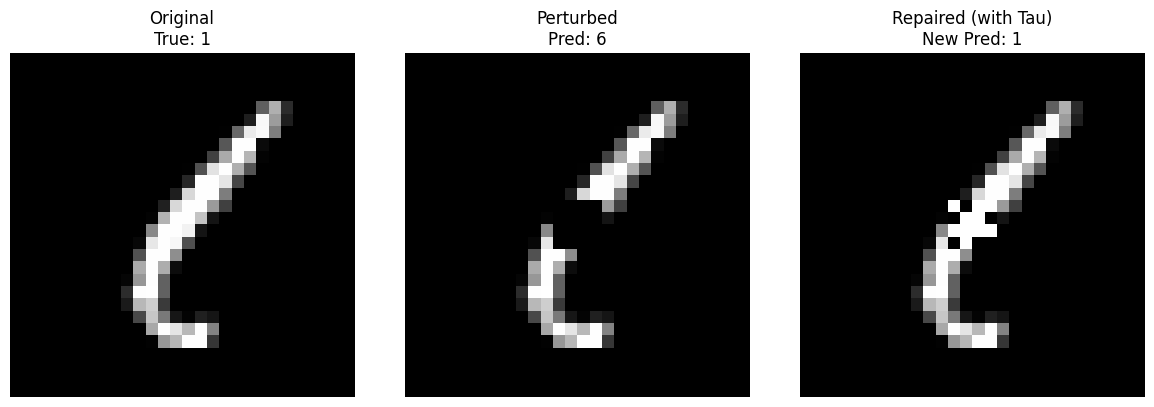


--- Case 91 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 2...
Pixels to add: 1.0
Optimization Time: 5.7100 seconds
Successfully restored!


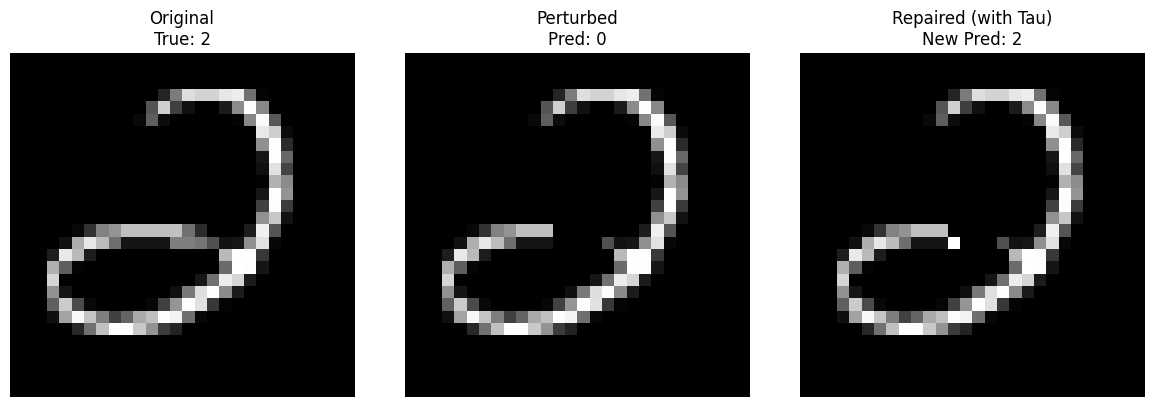


--- Case 92 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 10.0
Optimization Time: 6.5940 seconds
Successfully restored!


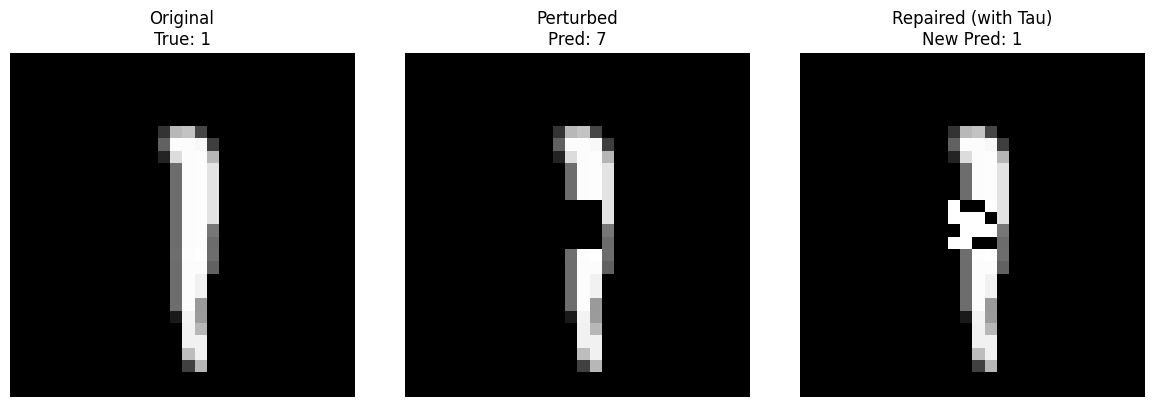


--- Case 93 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 1.0
Optimization Time: 5.8142 seconds
Successfully restored!


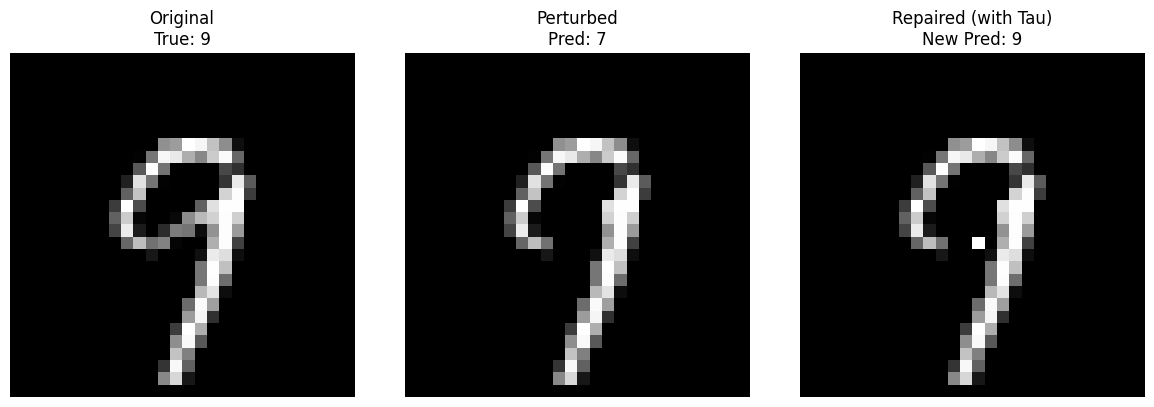


--- Case 94 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 9.0
Optimization Time: 6.2580 seconds
Successfully restored!


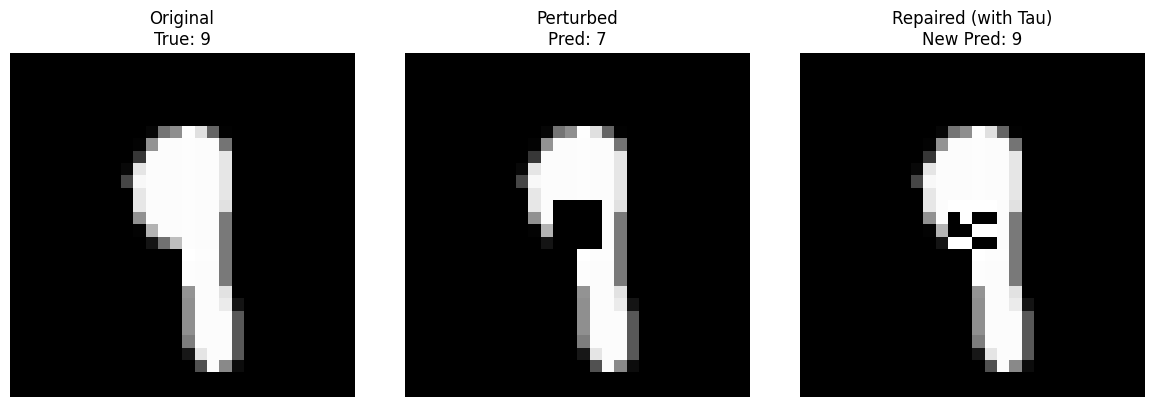


--- Case 95 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 8.0
Optimization Time: 6.4311 seconds
Successfully restored!


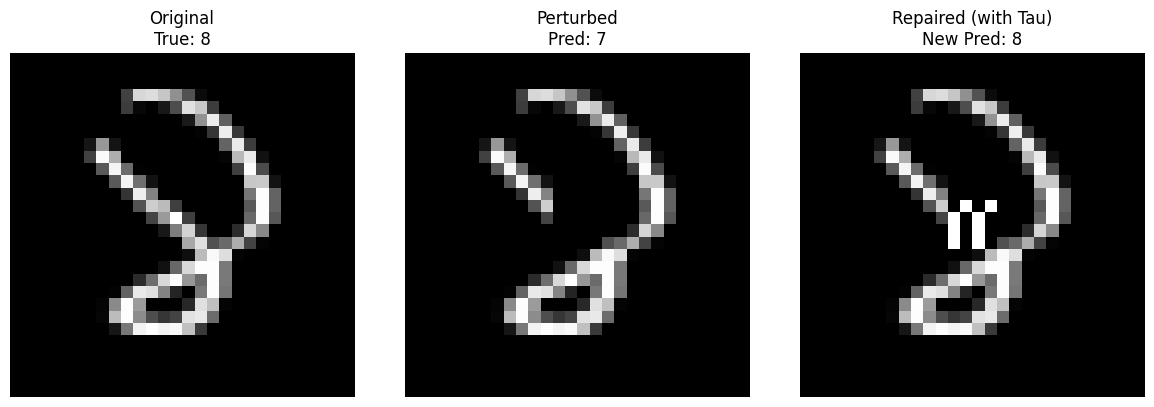


--- Case 96 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.0
Optimization Time: 6.5006 seconds
Successfully restored!


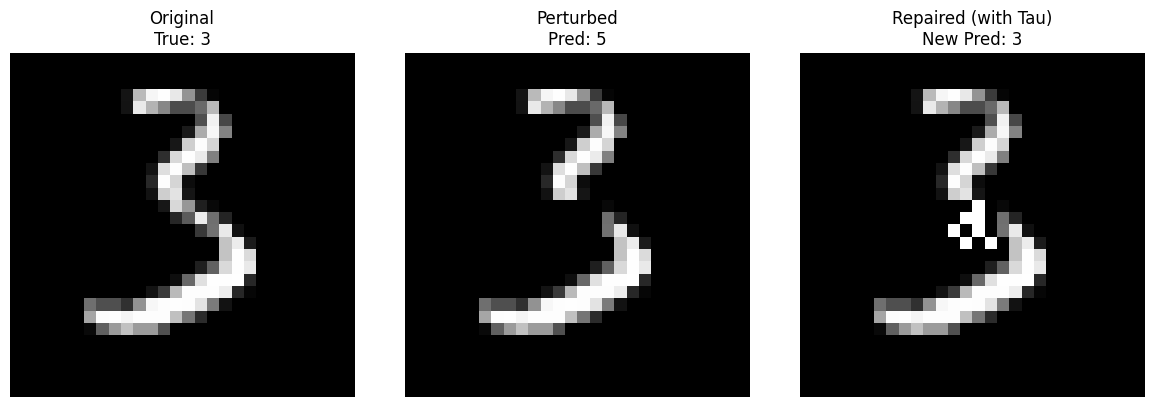


--- Case 97 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.0
Optimization Time: 6.5623 seconds
Successfully restored!


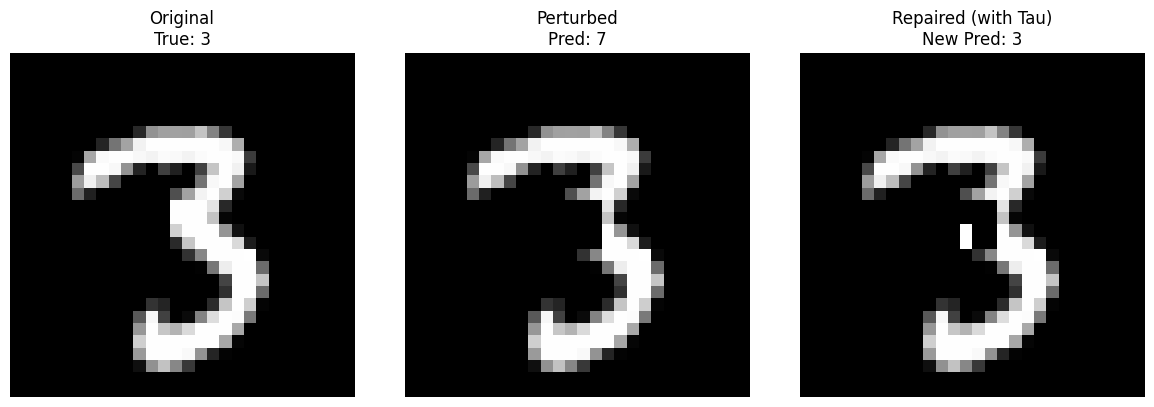


--- Case 98 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 1.0
Optimization Time: 5.3275 seconds
Successfully restored!


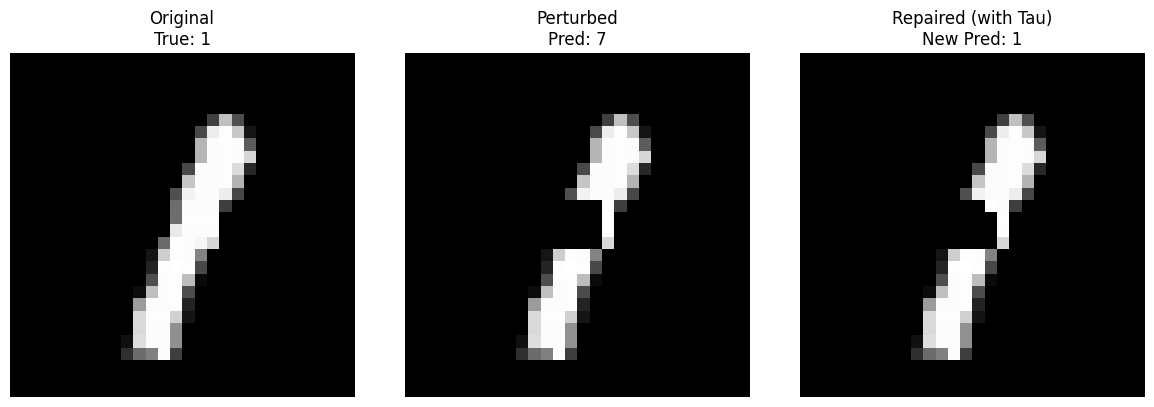


--- Case 99 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 7...
Pixels to add: 1.0
Optimization Time: 6.6752 seconds
Successfully restored!


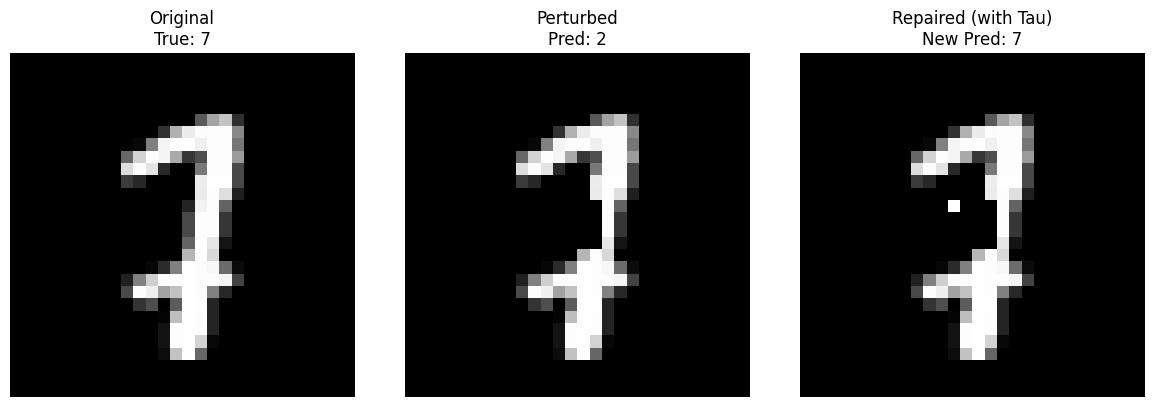


--- Case 100 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 5.0
Optimization Time: 6.2870 seconds
Successfully restored!


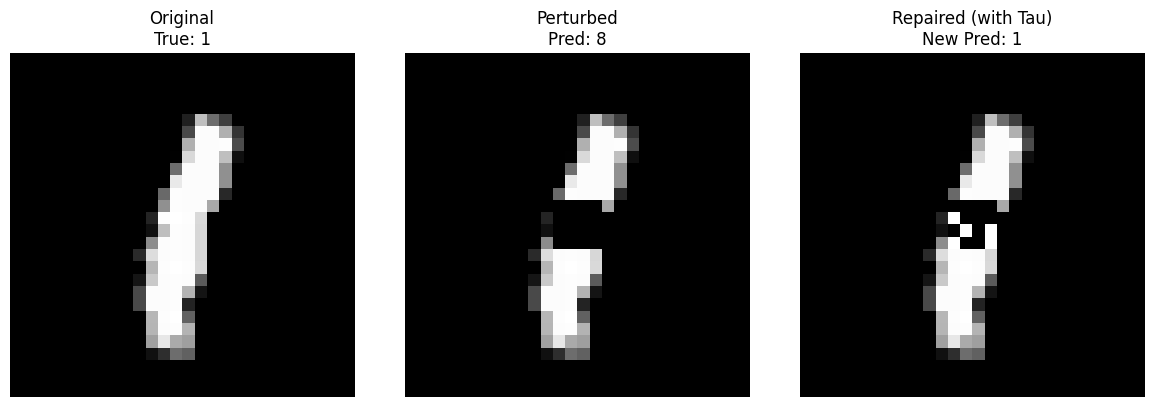

Total time taken to process 100 images : 913.56s
Success Rate: 99/100 = 99.00%


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random  # <--- Added import

# 4. Solve & Visualize
subset = 100
grid_size = cutout_size
start_idx = 14 - grid_size // 2
correct = 0

# --- RANDOM SELECTION LOGIC ---
total_failures = len(failures)
actual_subset_size = min(subset, total_failures) # Safety check

if actual_subset_size < subset:
    print(f"Warning: Requested {subset} images, but only found {total_failures} failures.")

print(f"Selecting {actual_subset_size} random failure cases...")
selected_failures = random.sample(failures, actual_subset_size)
# ------------------------------

st_time = time.time()

# Iterate over the randomly selected list
for i, case in enumerate(selected_failures):
    print(f"\n--- Case {i+1} / {actual_subset_size} ---")

    # --- START TIMER ---
    start_time = time.time()

    # Run the solver
    tau_val = solve_tau_milp(model, case, grid_size=grid_size)

    # --- STOP TIMER ---
    elapsed_time = time.time() - start_time
    print(f"Optimization Time: {elapsed_time:.4f} seconds")

    if tau_val is not None:
        plt.figure(figsize=(12, 4))

        # 1. Original
        plt.subplot(1, 3, 1)
        plt.title(f"Original\nTrue: {case['true_label']}")
        plt.imshow(case['original'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 2. Perturbed (Attack)
        plt.subplot(1, 3, 2)
        plt.title(f"Perturbed\nPred: {case['wrong_label']}")
        plt.imshow(case['perturbed'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 3. Apply Tau (Repair)
        repaired = case['perturbed'].copy()

        # Robust logic: Zero out the area first, then add tau
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] = 0.0
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] += tau_val

        # Verify Prediction
        pred_prob = model.predict(np.expand_dims(repaired, 0), verbose=0)
        pred_lbl = np.argmax(pred_prob)

        if(pred_lbl == case['true_label']):
            correct += 1
            print(f"Successfully restored!")

        plt.subplot(1, 3, 3)
        plt.title(f"Repaired (with Tau)\nNew Pred: {pred_lbl}")
        plt.imshow(repaired, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(">> No solution found (Infeasible or Timed Out)")

el_time = time.time() - st_time

print(f"Total time taken to process {actual_subset_size} images : {el_time:.2f}s")
print(f"Success Rate: {correct}/{actual_subset_size} = {correct/actual_subset_size*100:.2f}%")

Selecting 100 random failure cases...

--- Case 1 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 8.128421919584683
Optimization Time: 8.5878 seconds
Successfully restored!


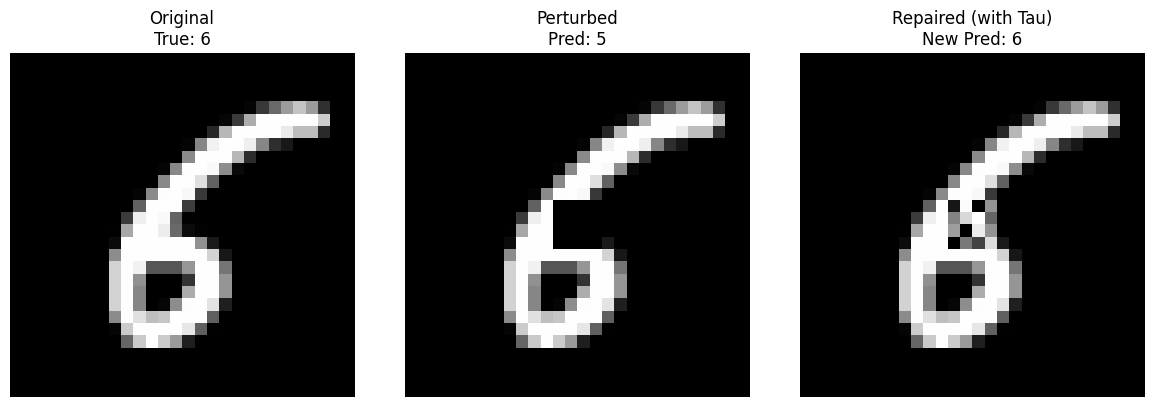


--- Case 2 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 7.869138324229148
Optimization Time: 8.8642 seconds
Successfully restored!


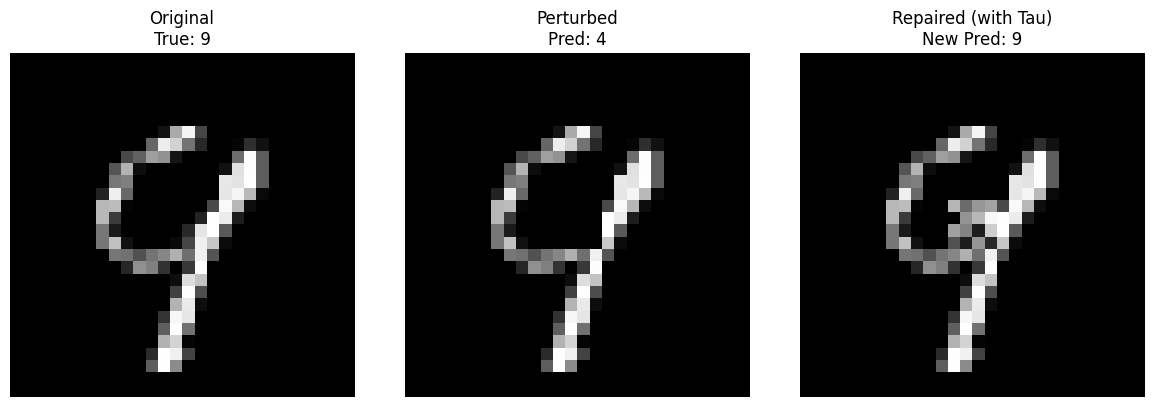


--- Case 3 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 3.701634996870622
Optimization Time: 14.6901 seconds
Successfully restored!


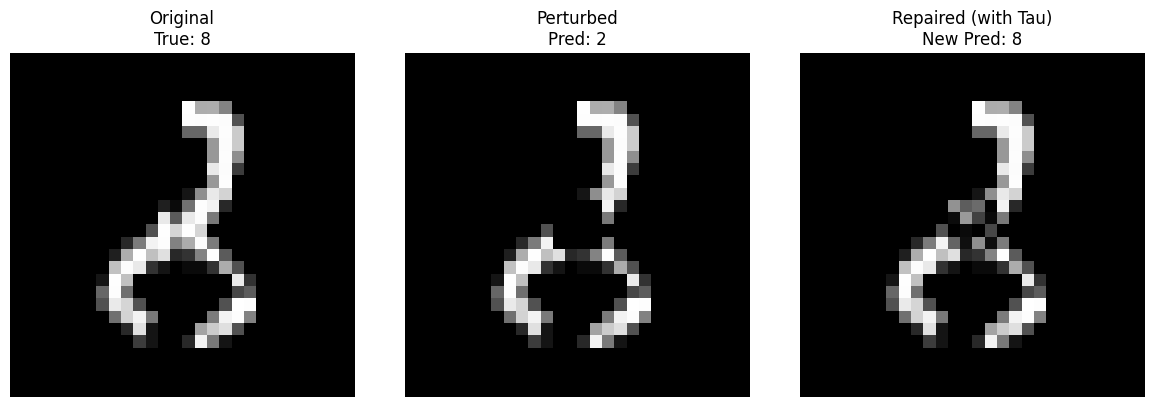


--- Case 4 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.577705794596216
Optimization Time: 6.6982 seconds
Successfully restored!


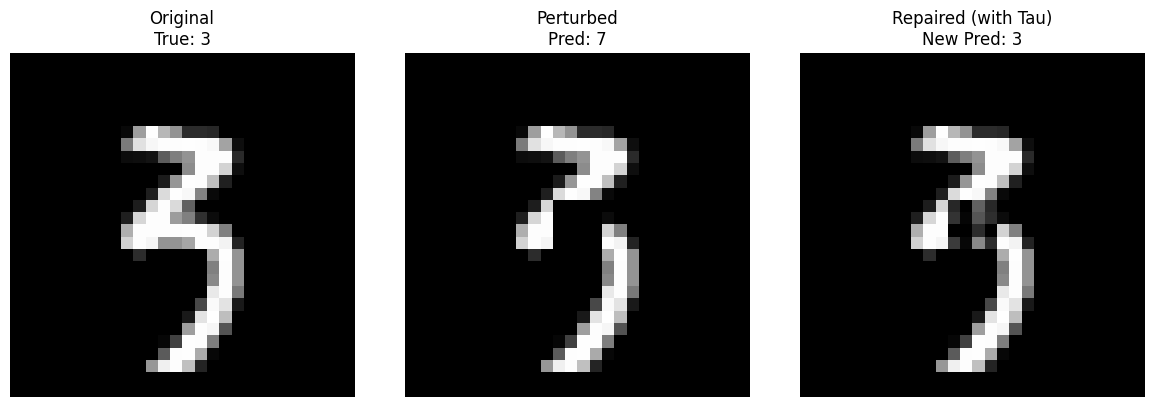


--- Case 5 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.96798701324811
Optimization Time: 7.0744 seconds
Successfully restored!


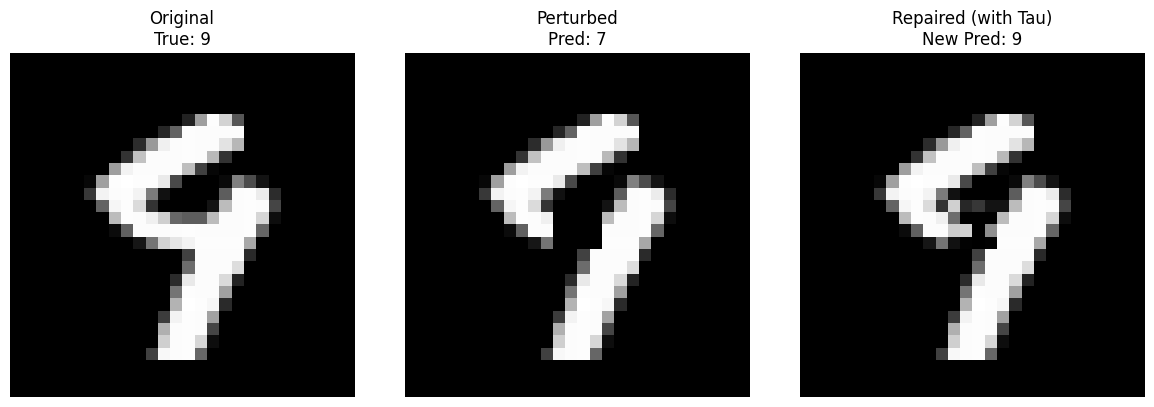


--- Case 6 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.043658042959629
Optimization Time: 6.7077 seconds
Successfully restored!


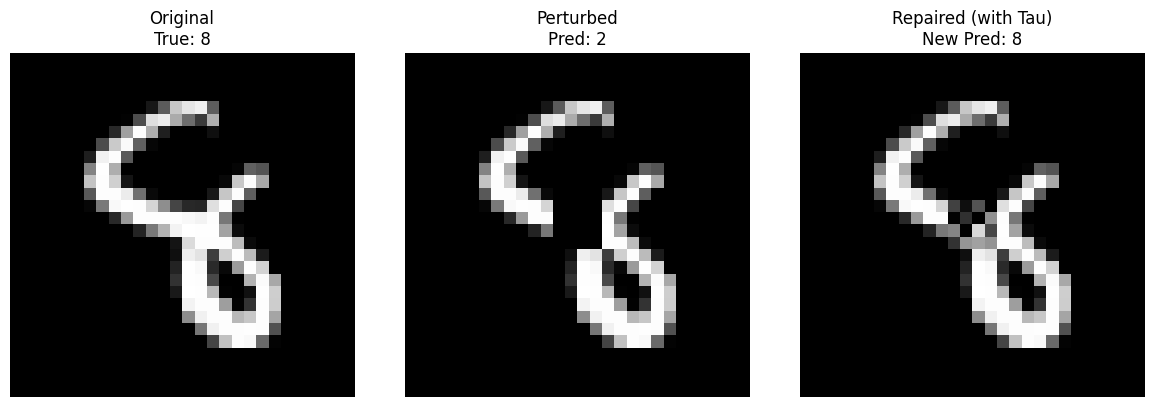


--- Case 7 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.91158056633372
Optimization Time: 8.9356 seconds
Successfully restored!


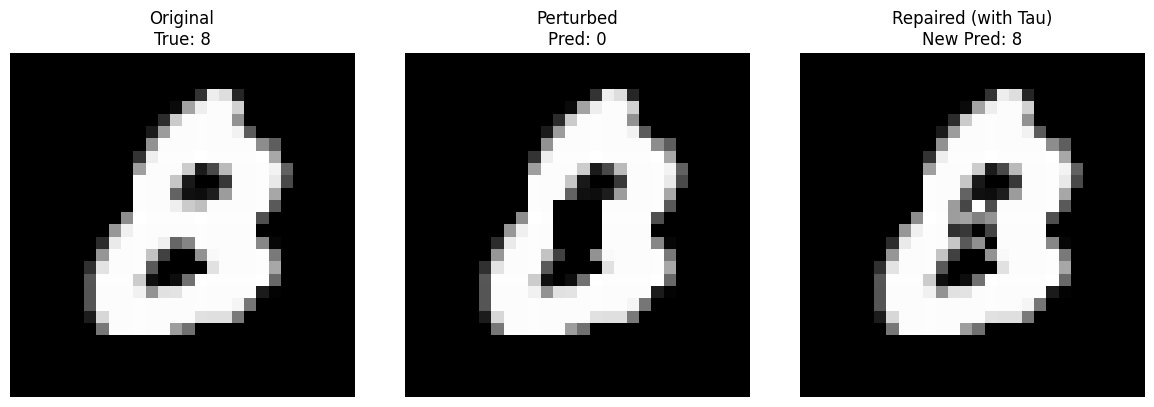


--- Case 8 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.195496284087005
Optimization Time: 20.4634 seconds


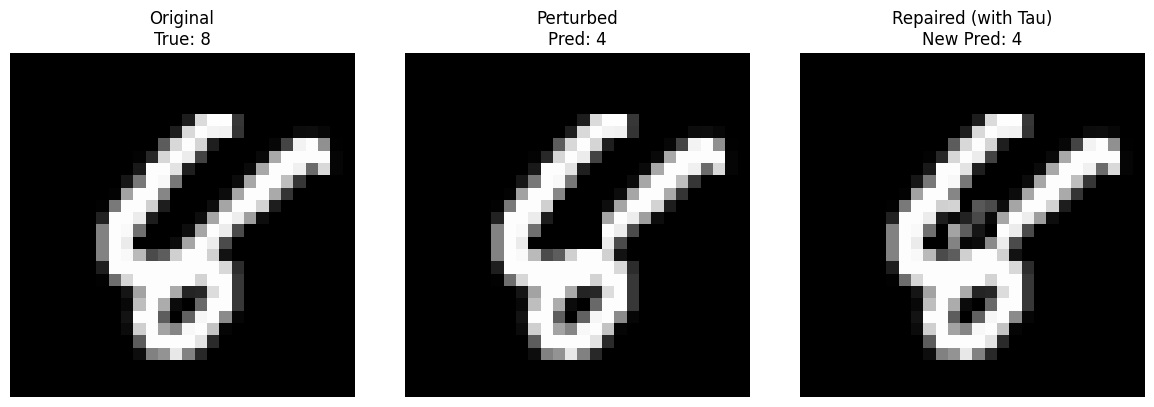


--- Case 9 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.658549815370276
Optimization Time: 6.7902 seconds
Successfully restored!


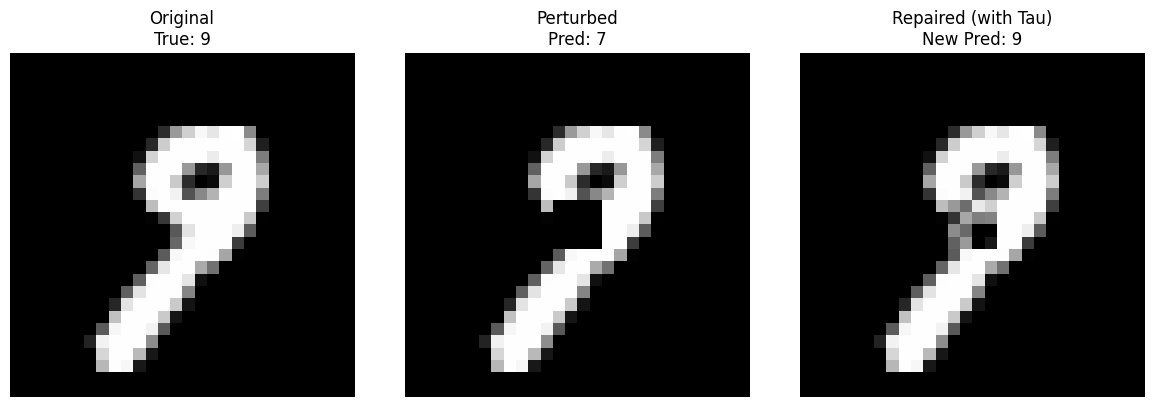


--- Case 10 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.009436536183349
Optimization Time: 8.3211 seconds


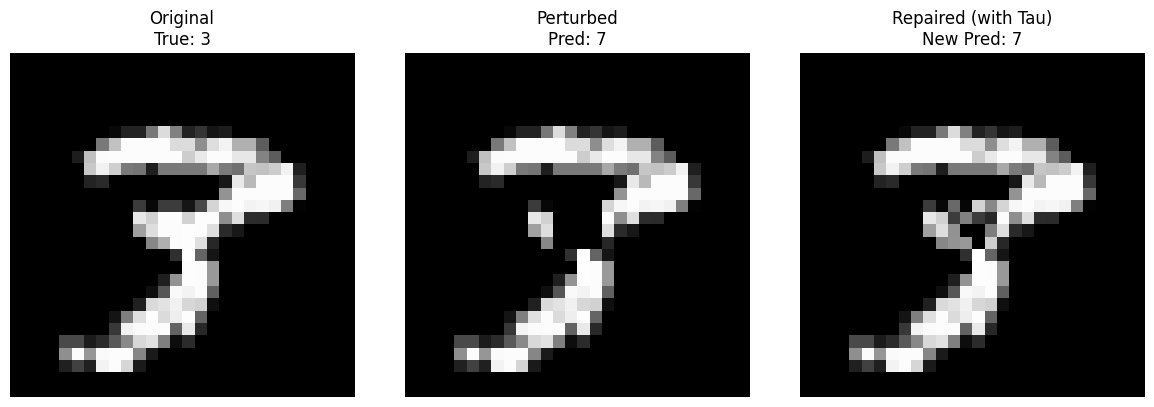


--- Case 11 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.987642038126007
Optimization Time: 9.0317 seconds
Successfully restored!


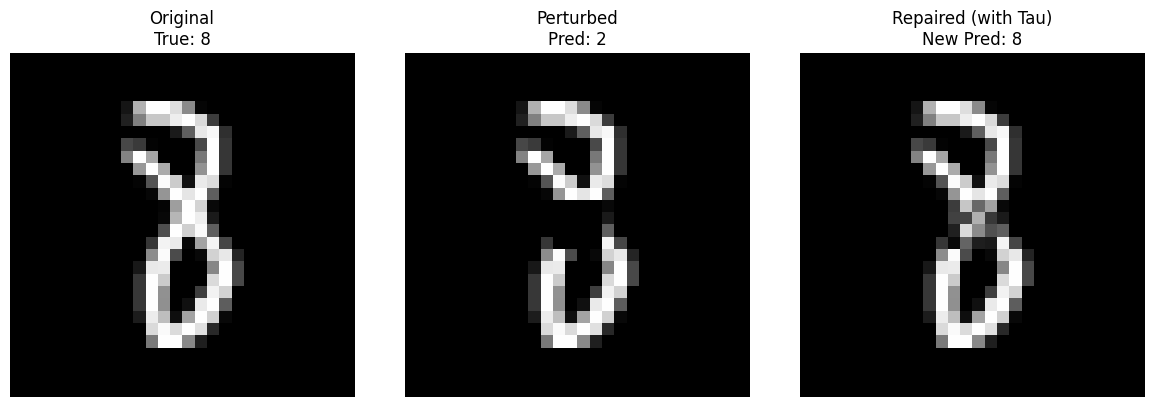


--- Case 12 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.904012342511523
Optimization Time: 7.4828 seconds
Successfully restored!


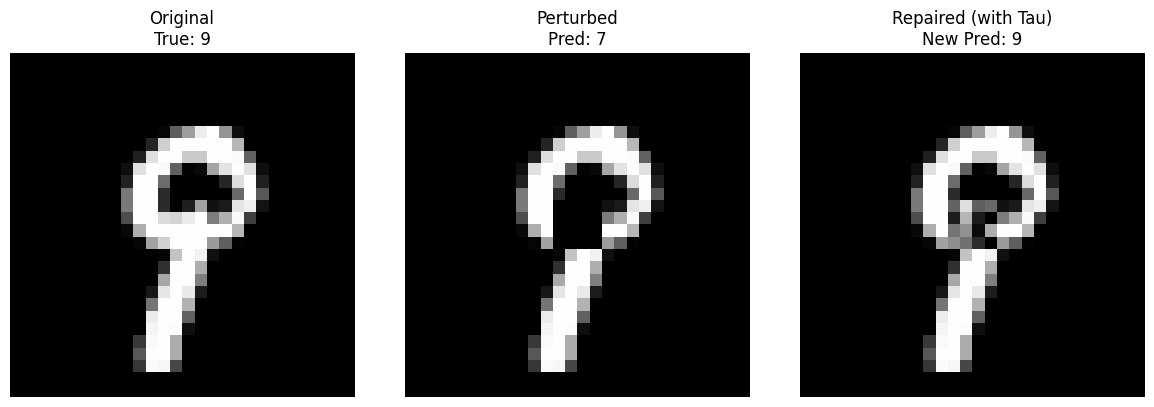


--- Case 13 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.5490561258054028
Optimization Time: 15.7201 seconds
Successfully restored!


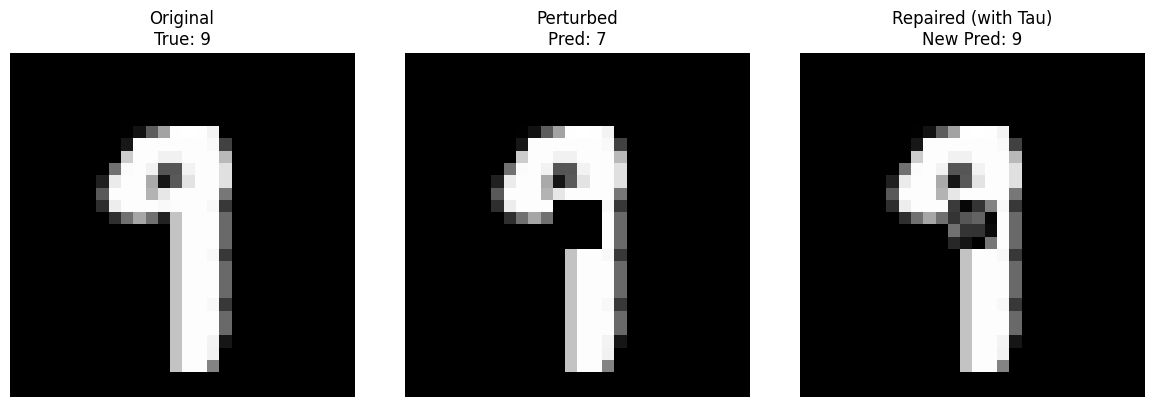


--- Case 14 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.995879987462374
Optimization Time: 10.7274 seconds


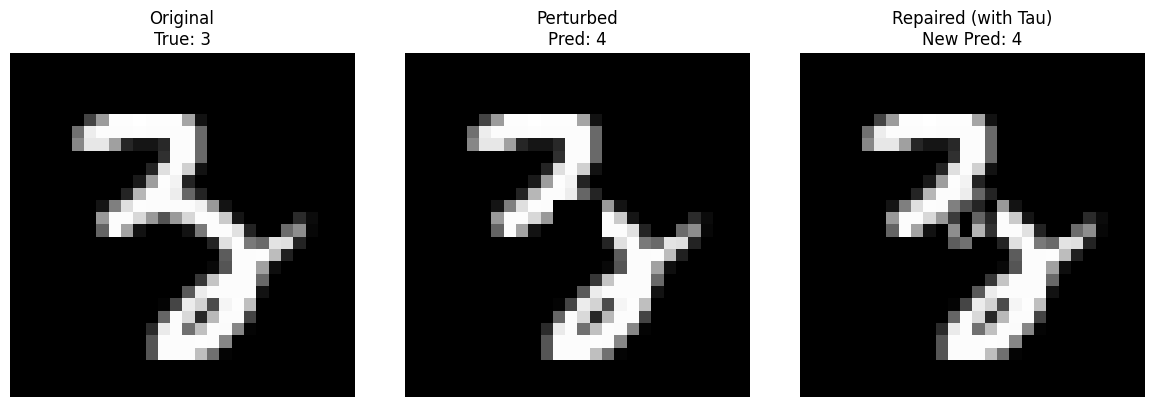


--- Case 15 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 2.9139051681271173
Optimization Time: 6.2301 seconds
Successfully restored!


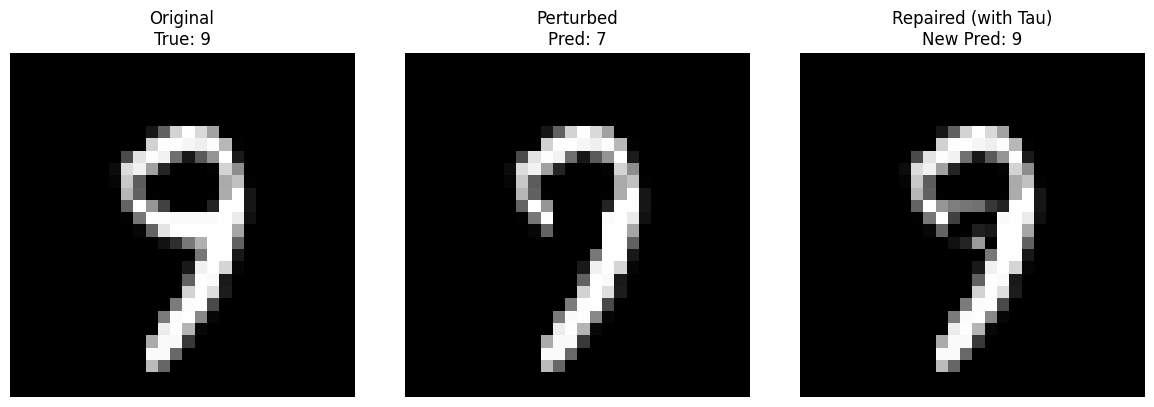


--- Case 16 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.515746102615469
Optimization Time: 6.6514 seconds
Successfully restored!


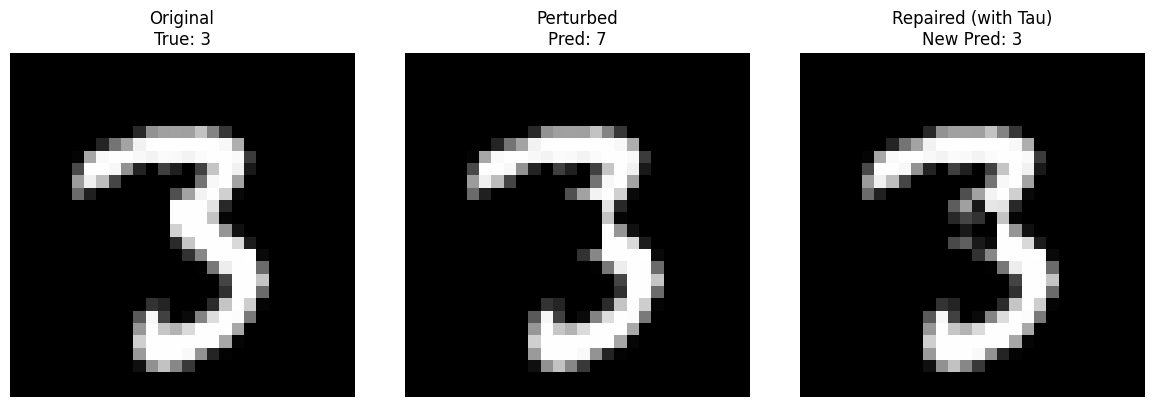


--- Case 17 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 0.8530539175108434
Optimization Time: 6.9037 seconds
Successfully restored!


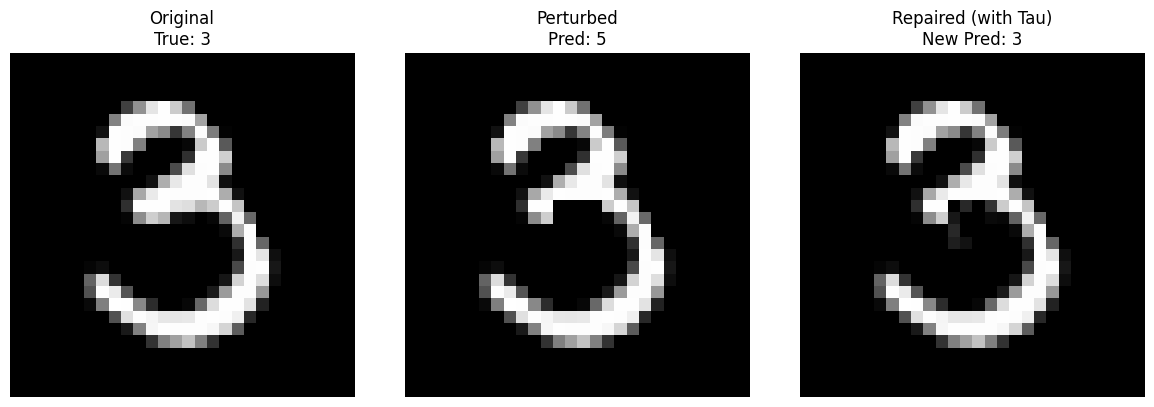


--- Case 18 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.3170403734589886
Optimization Time: 8.0396 seconds
Successfully restored!


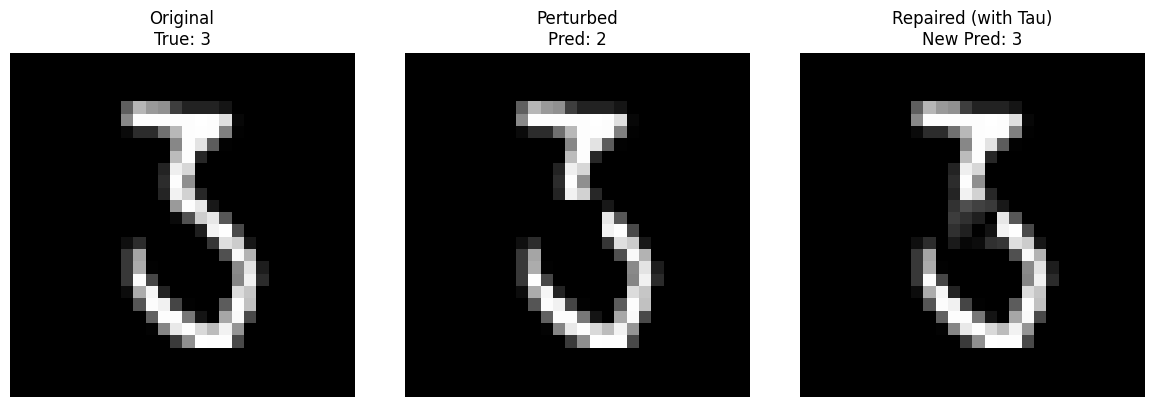


--- Case 19 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 7.598363096457504
Optimization Time: 7.5415 seconds
Successfully restored!


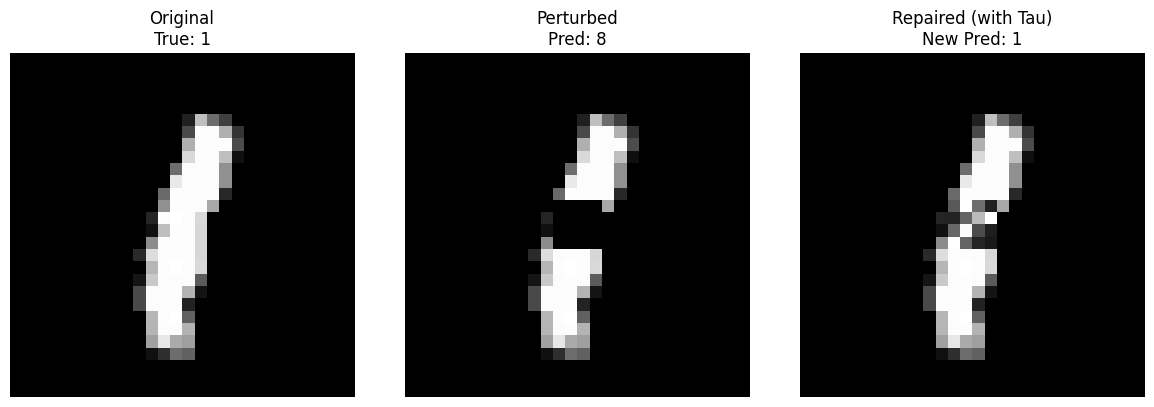


--- Case 20 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 4.822428949059706
Optimization Time: 8.4276 seconds
Successfully restored!


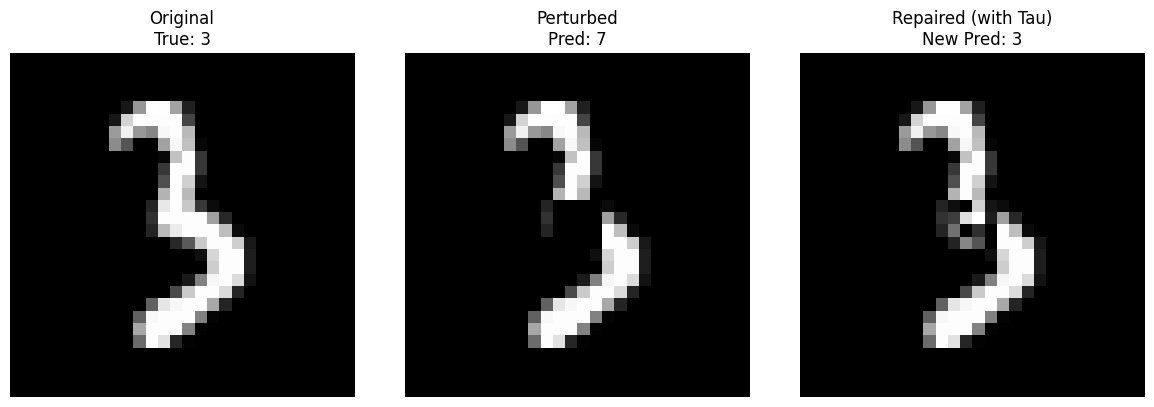


--- Case 21 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.313195428654798
Optimization Time: 7.9492 seconds
Successfully restored!


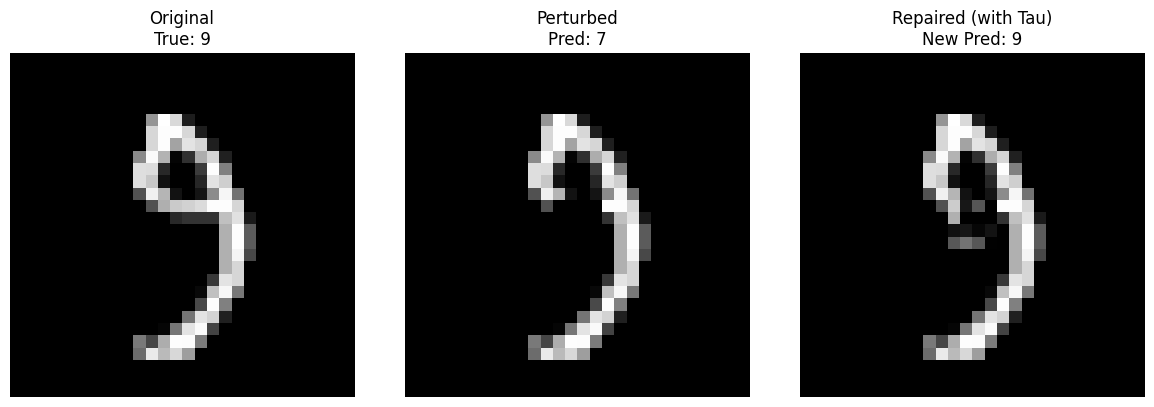


--- Case 22 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 3.9021658881371772
Optimization Time: 7.3161 seconds
Successfully restored!


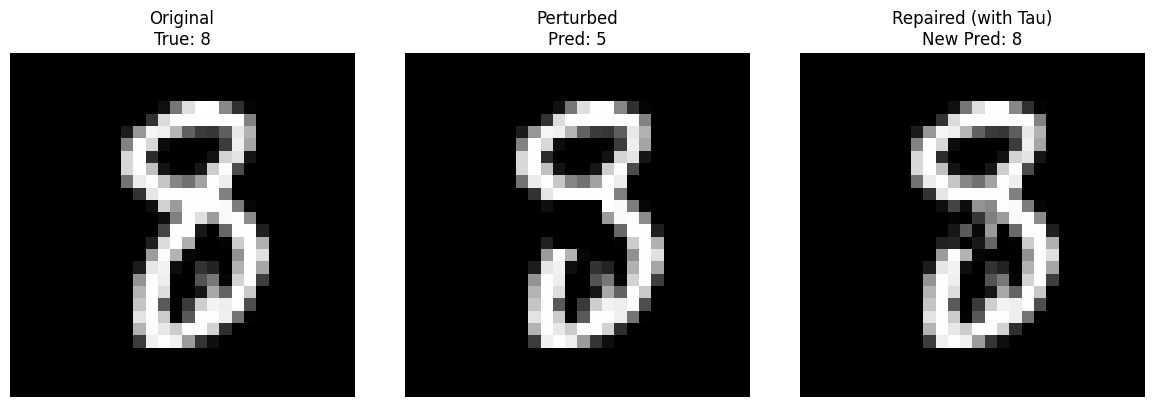


--- Case 23 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 6.973276019710197
Optimization Time: 6.6964 seconds
Successfully restored!


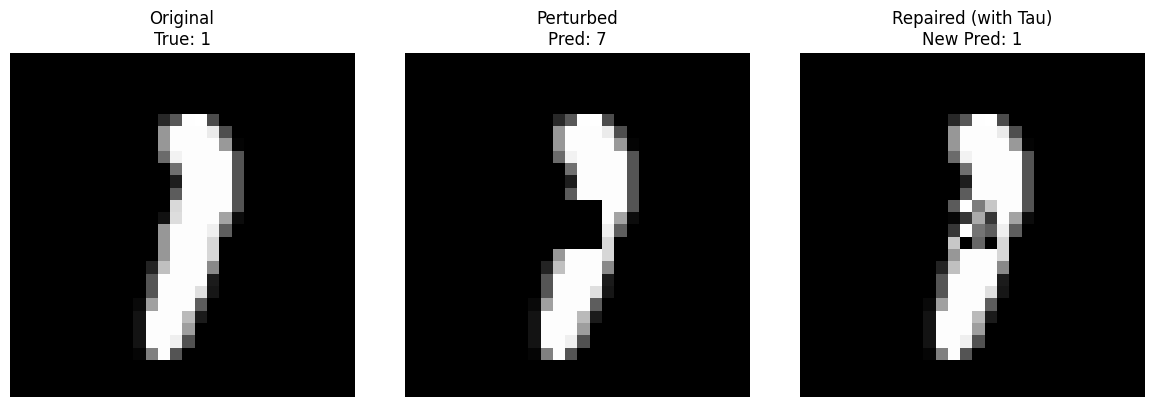


--- Case 24 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.341564235424281
Optimization Time: 8.8927 seconds
Successfully restored!


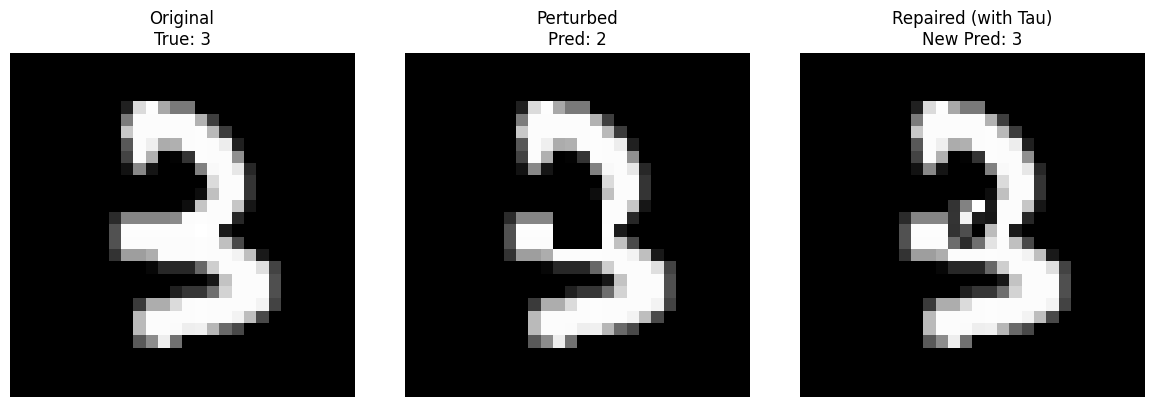


--- Case 25 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 7.051870672878571
Optimization Time: 7.3384 seconds
Successfully restored!


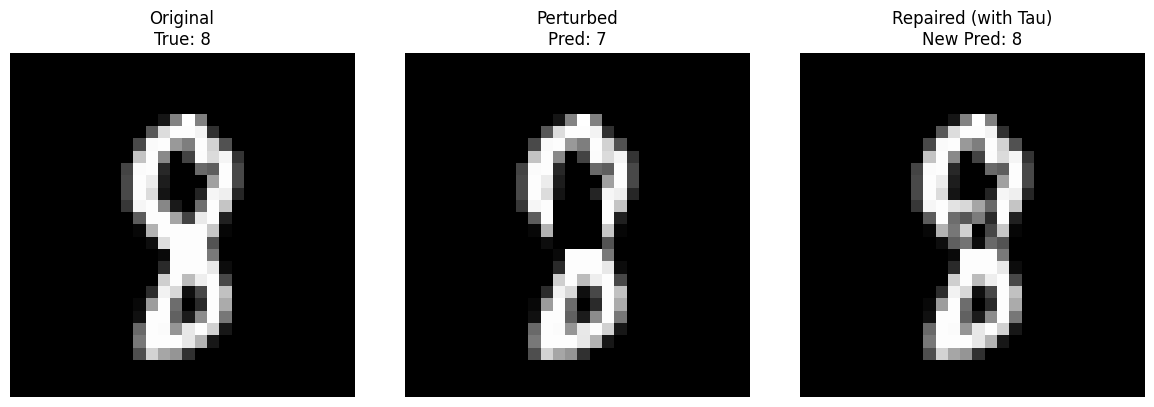


--- Case 26 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.001386642802534
Optimization Time: 7.2891 seconds
Successfully restored!


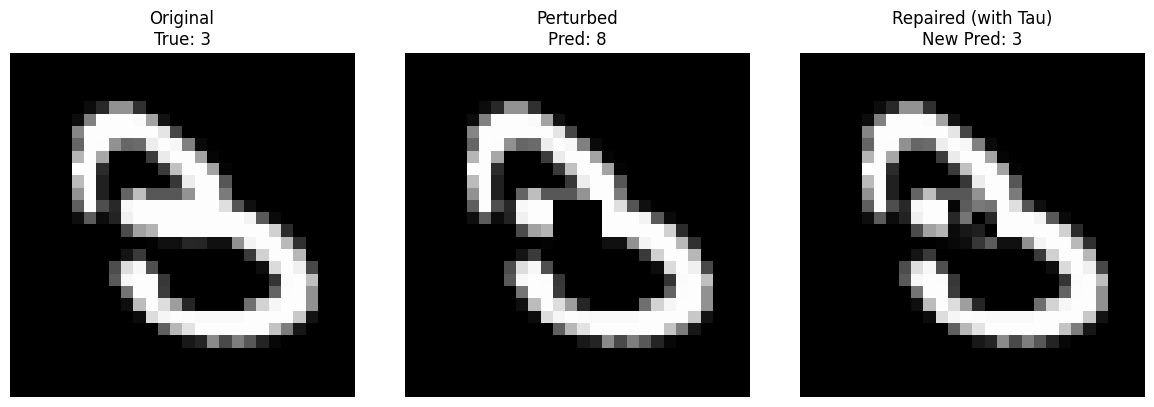


--- Case 27 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 3.198040535974377
Optimization Time: 9.8506 seconds


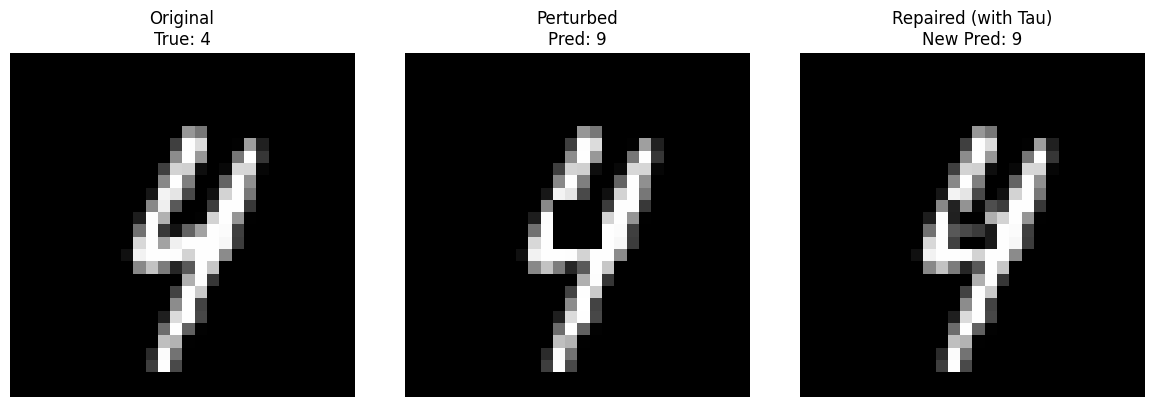


--- Case 28 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.10180689608283
Optimization Time: 8.4193 seconds
Successfully restored!


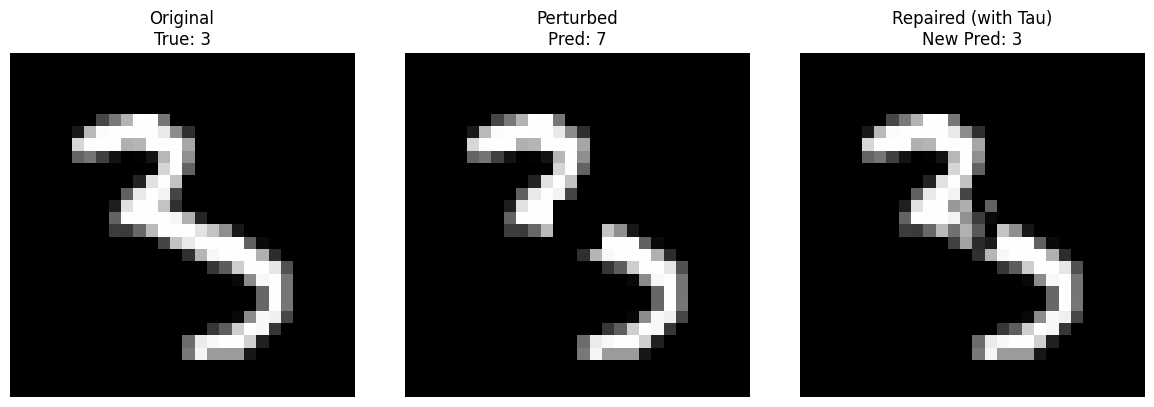


--- Case 29 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 8.231617552621227
Optimization Time: 8.8357 seconds
Successfully restored!


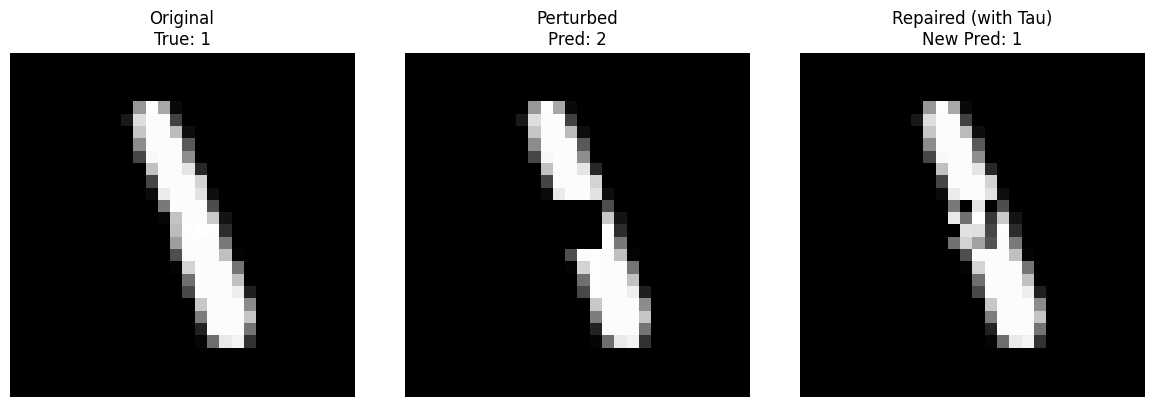


--- Case 30 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.3705880711806
Optimization Time: 7.6612 seconds
Successfully restored!


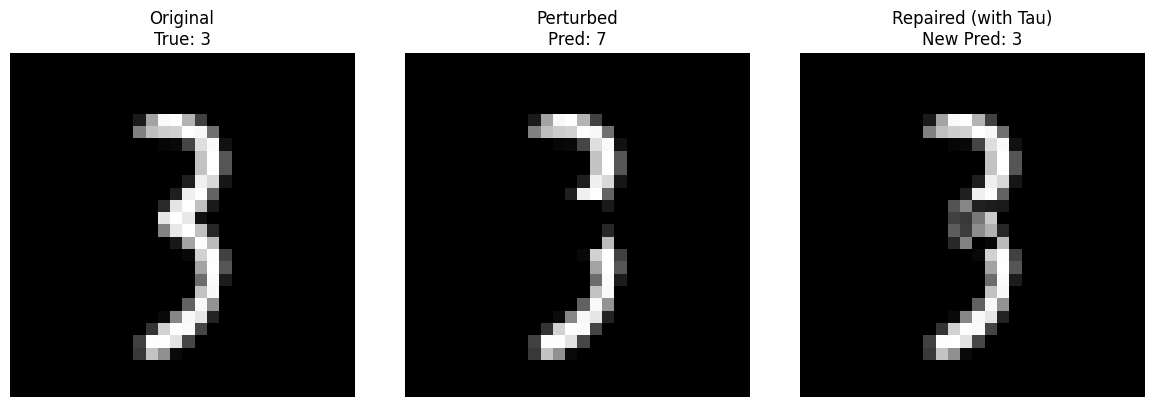


--- Case 31 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 5.36963046339028
Optimization Time: 27.5207 seconds
Successfully restored!


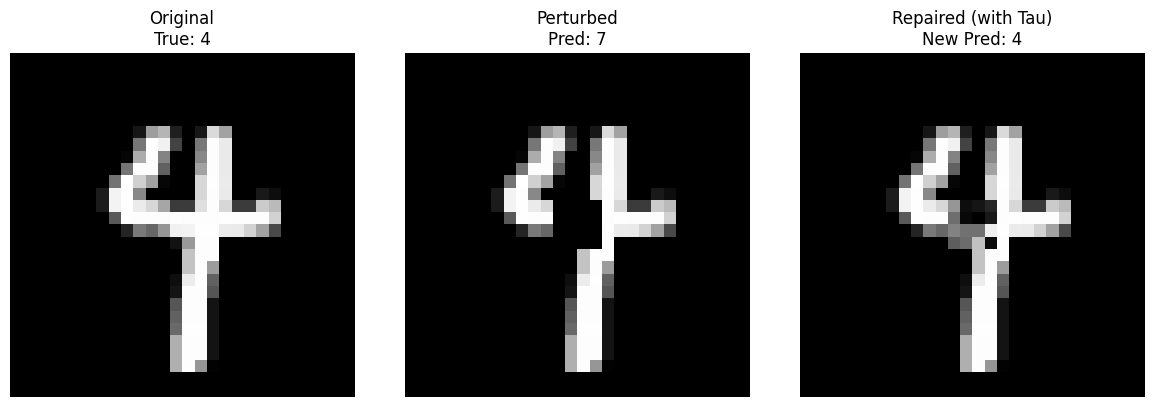


--- Case 32 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
No Repair Found (Status 9)
Optimization Time: 124.3576 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 33 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.6697503252614614
Optimization Time: 16.6295 seconds
Successfully restored!


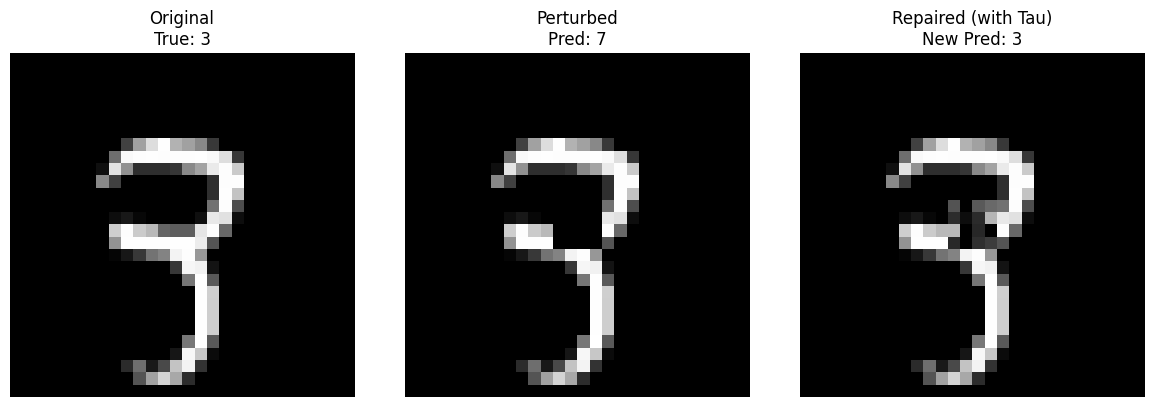


--- Case 34 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.1038246177362194
Optimization Time: 10.9322 seconds
Successfully restored!


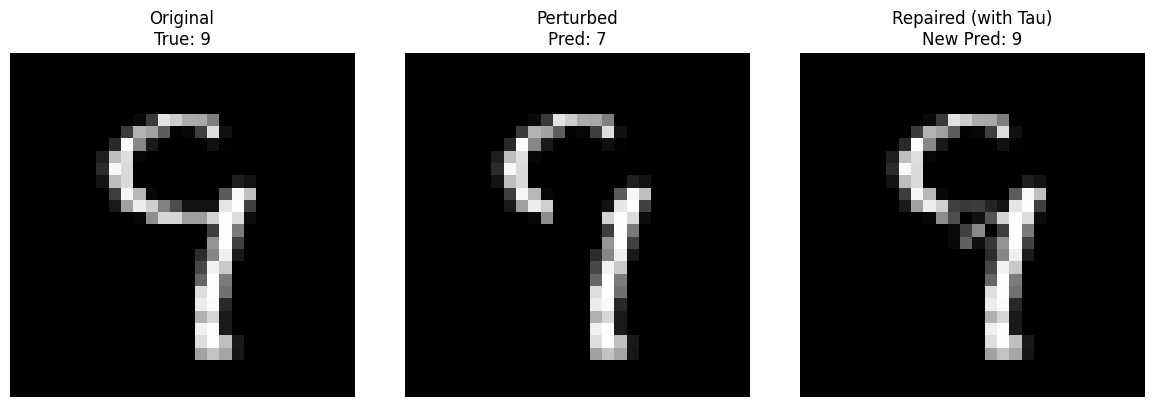


--- Case 35 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.8195415555349825
Optimization Time: 7.6029 seconds
Successfully restored!


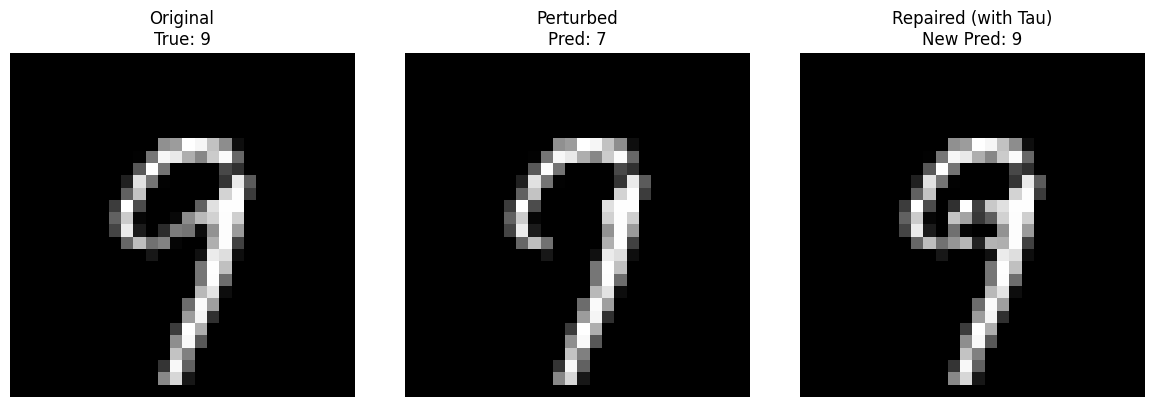


--- Case 36 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 2.9116949421310565
Optimization Time: 7.2037 seconds
Successfully restored!


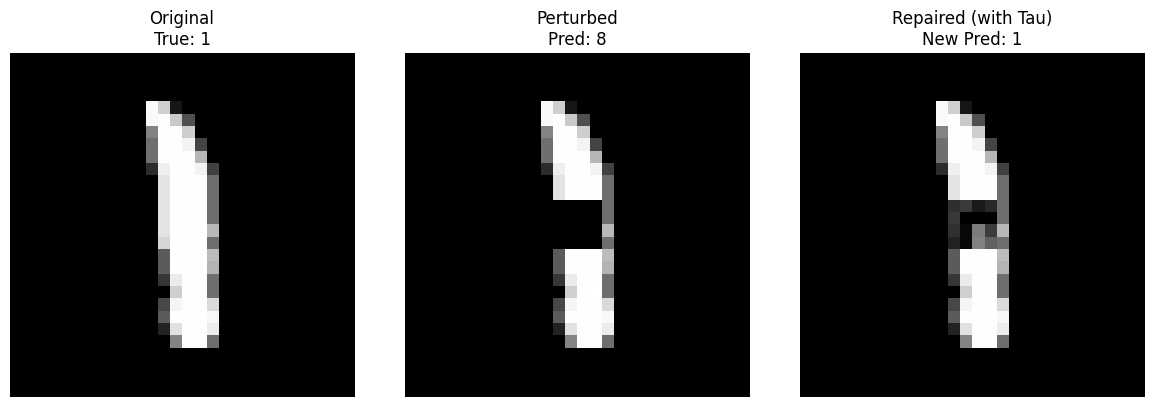


--- Case 37 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 6.755483272192664
Optimization Time: 7.1264 seconds
Successfully restored!


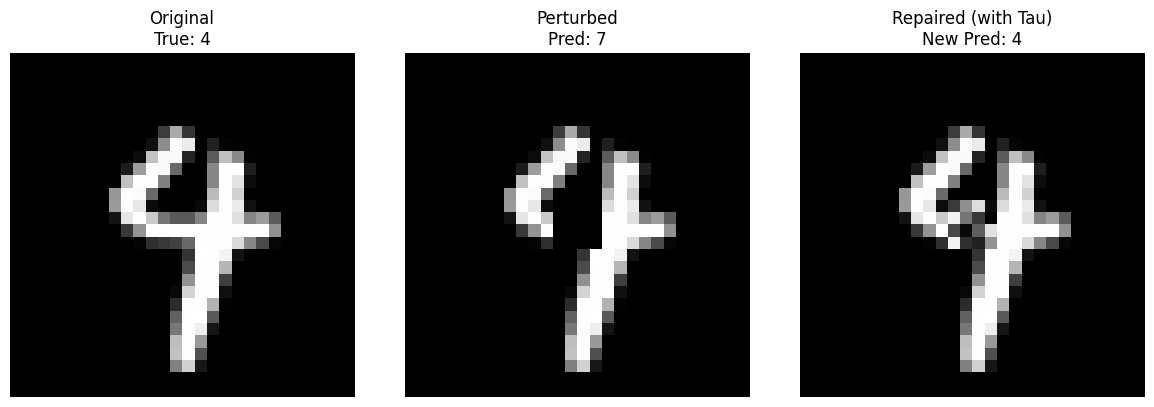


--- Case 38 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 6.822368391251611
Optimization Time: 7.3079 seconds
Successfully restored!


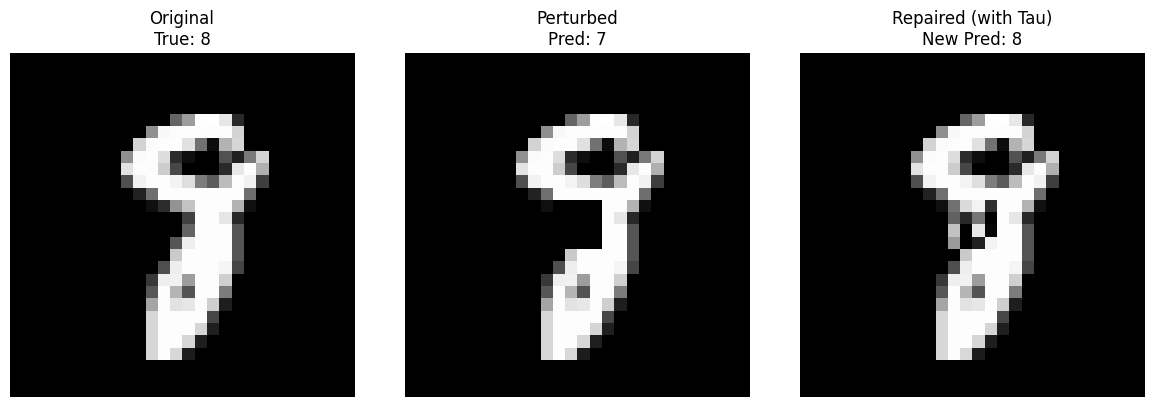


--- Case 39 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.733963734998069
Optimization Time: 7.2406 seconds
Successfully restored!


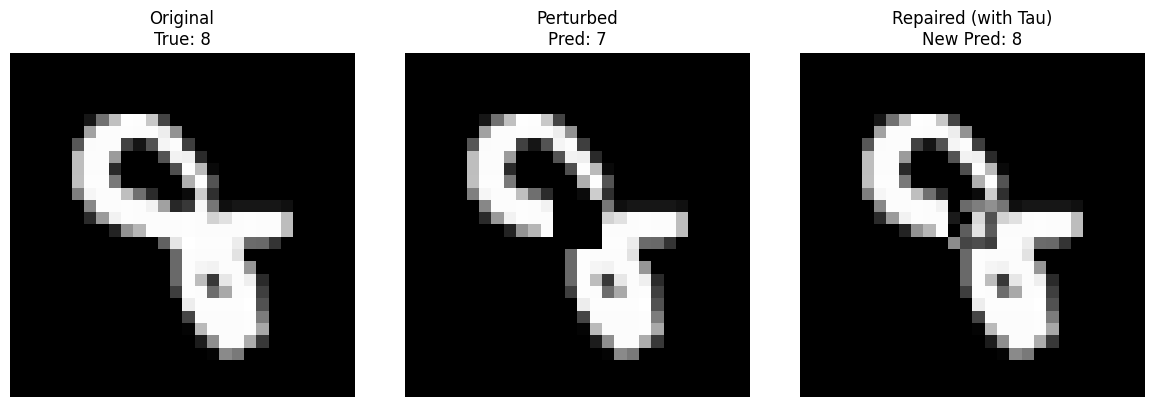


--- Case 40 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.118216492831285
Optimization Time: 8.1753 seconds
Successfully restored!


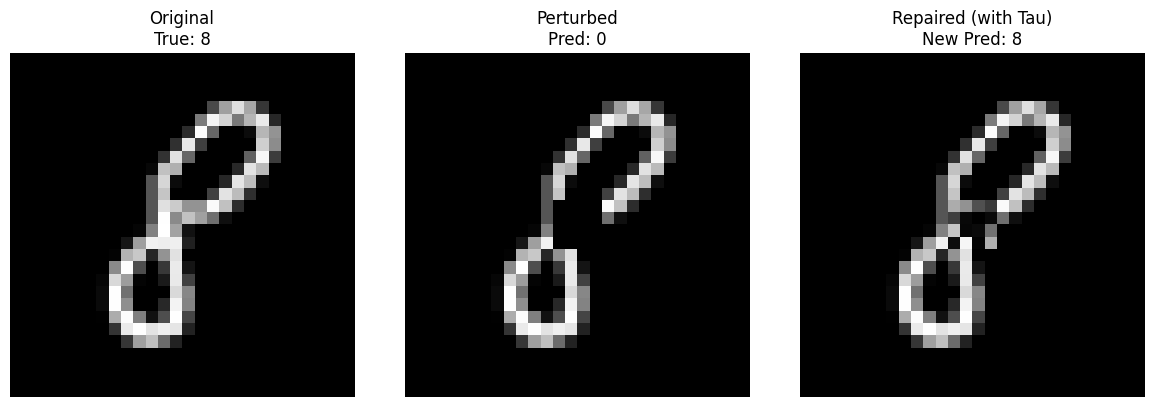


--- Case 41 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.498257859925437
Optimization Time: 8.0764 seconds


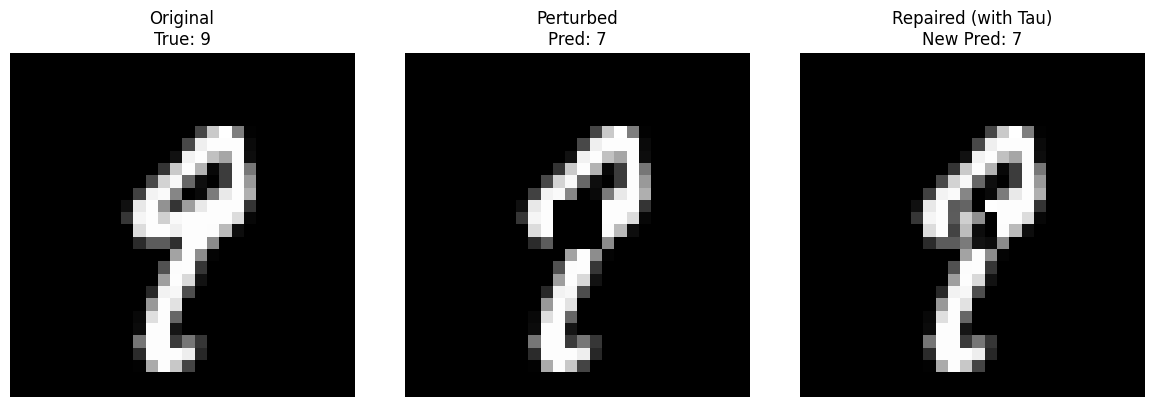


--- Case 42 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 4.906442447903114
Optimization Time: 7.6325 seconds
Successfully restored!


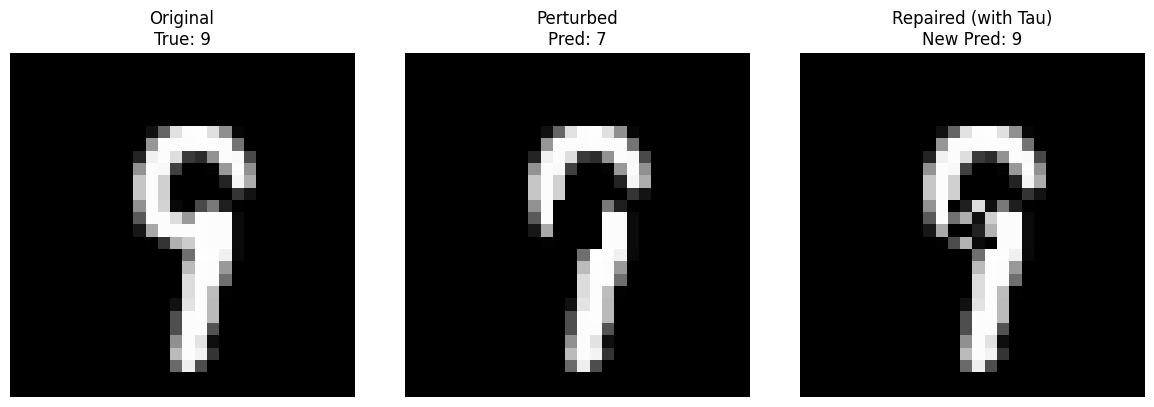


--- Case 43 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.034976702173148
Optimization Time: 10.1872 seconds
Successfully restored!


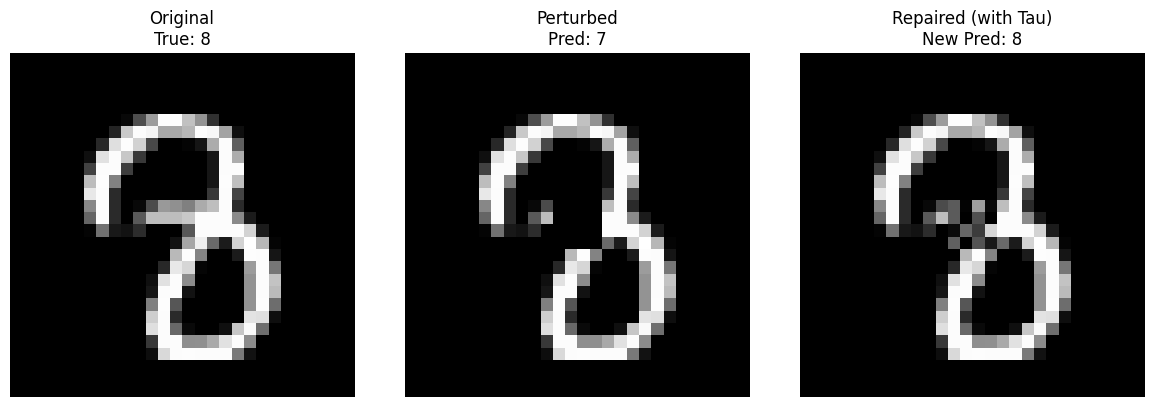


--- Case 44 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 7...
Pixels to add: 3.940212309804308
Optimization Time: 7.5634 seconds
Successfully restored!


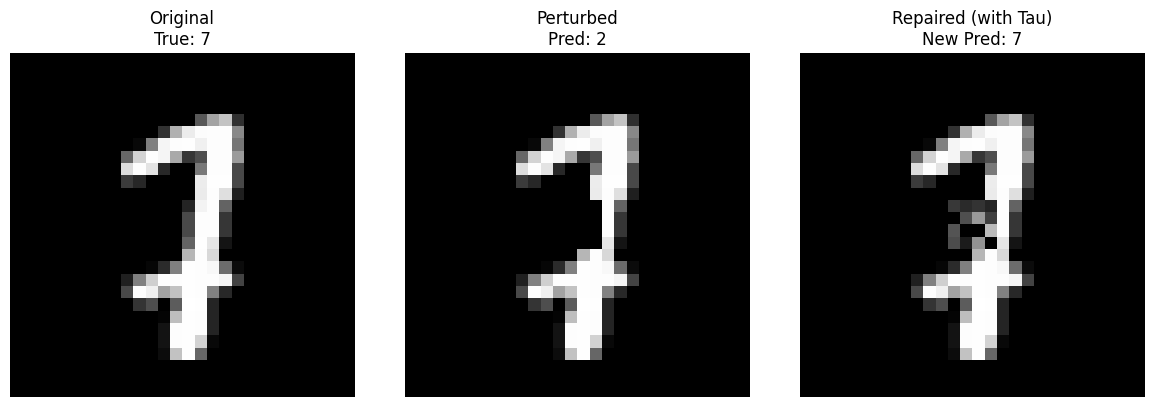


--- Case 45 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.036768439191197
Optimization Time: 7.7466 seconds
Successfully restored!


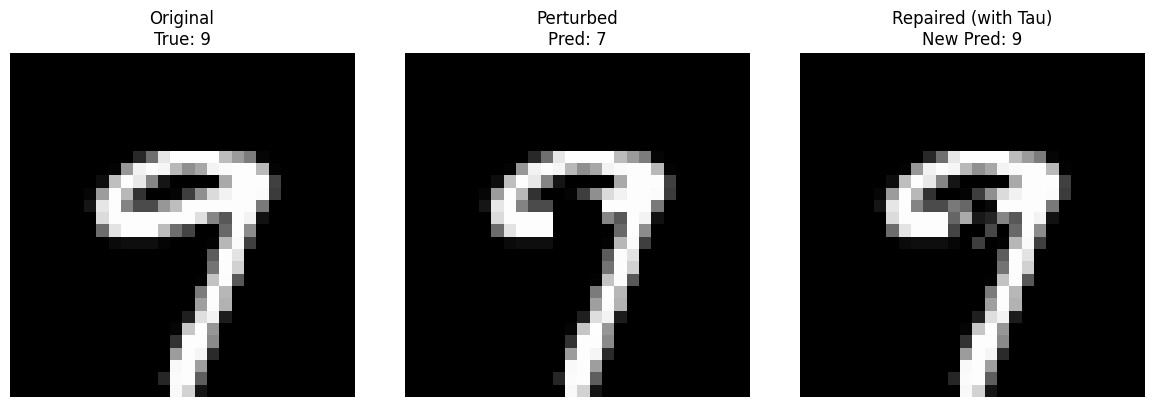


--- Case 46 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.9931843063453467
Optimization Time: 16.9553 seconds
Successfully restored!


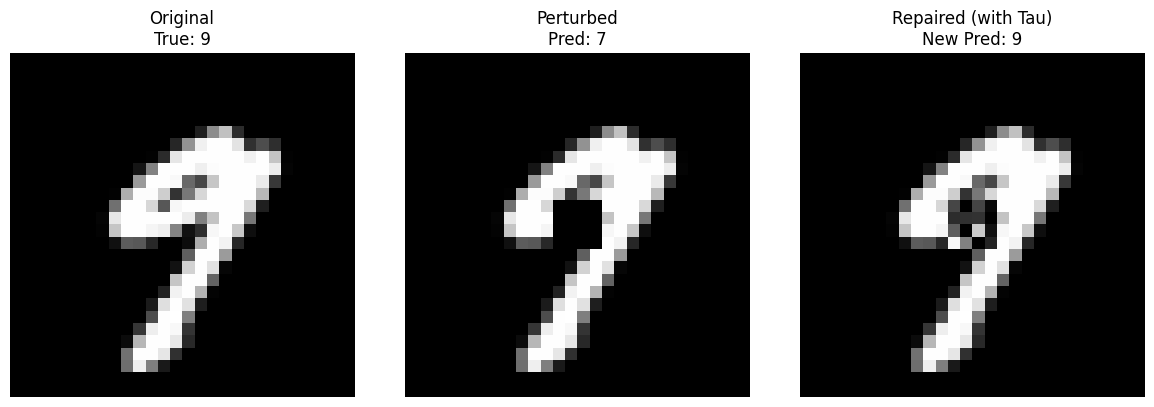


--- Case 47 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.433225943433313
Optimization Time: 7.3500 seconds
Successfully restored!


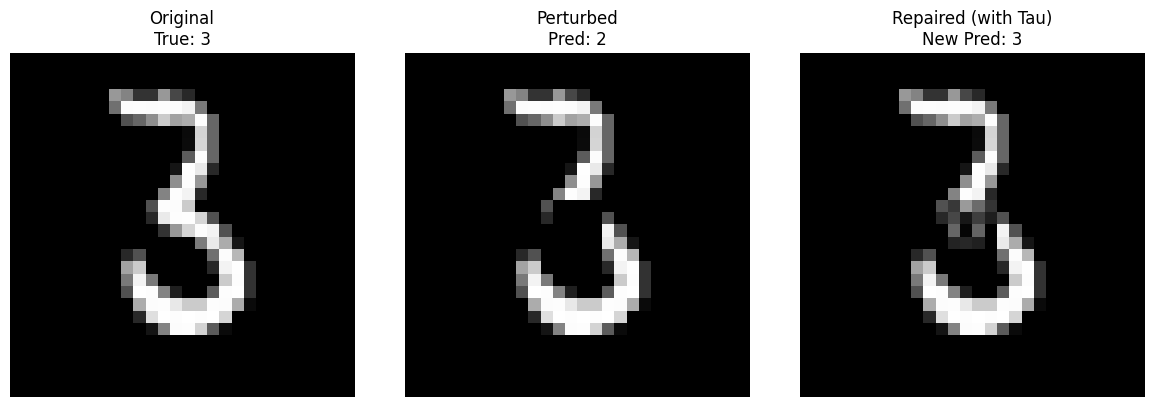


--- Case 48 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 2.30013888552195
Optimization Time: 11.4695 seconds
Successfully restored!


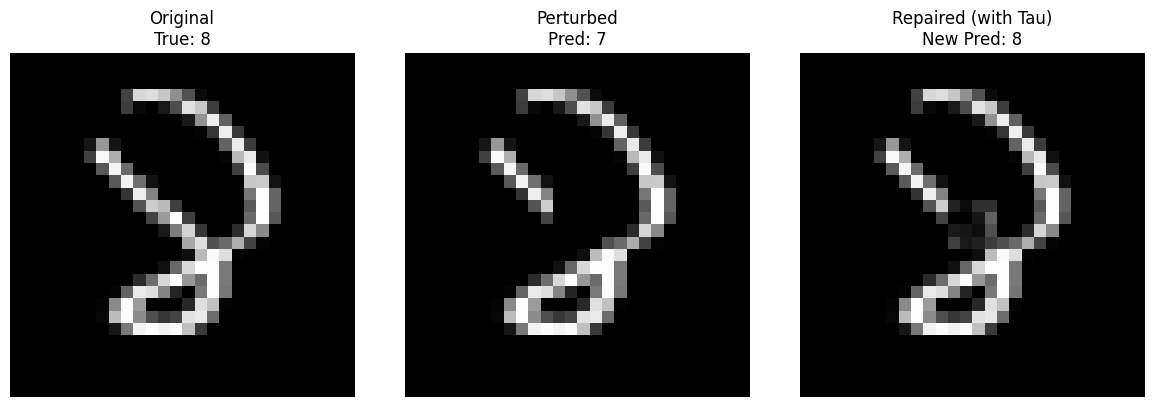


--- Case 49 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.250288726736278
Optimization Time: 6.9288 seconds
Successfully restored!


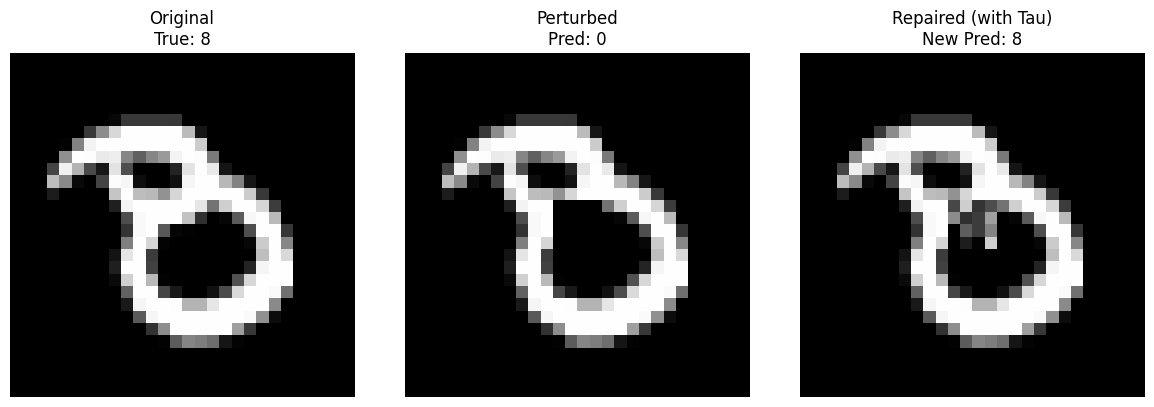


--- Case 50 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.796485837069278
Optimization Time: 7.4176 seconds
Successfully restored!


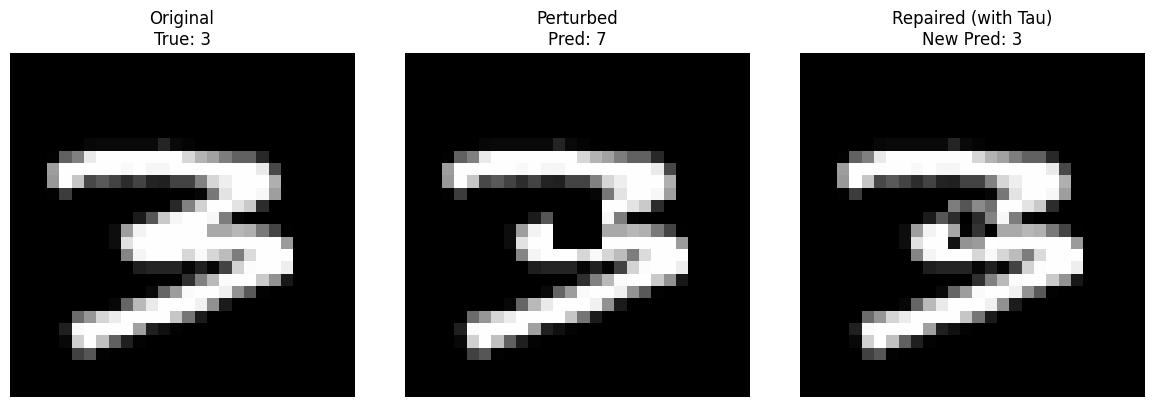


--- Case 51 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.6965859936986156
Optimization Time: 7.5010 seconds
Successfully restored!


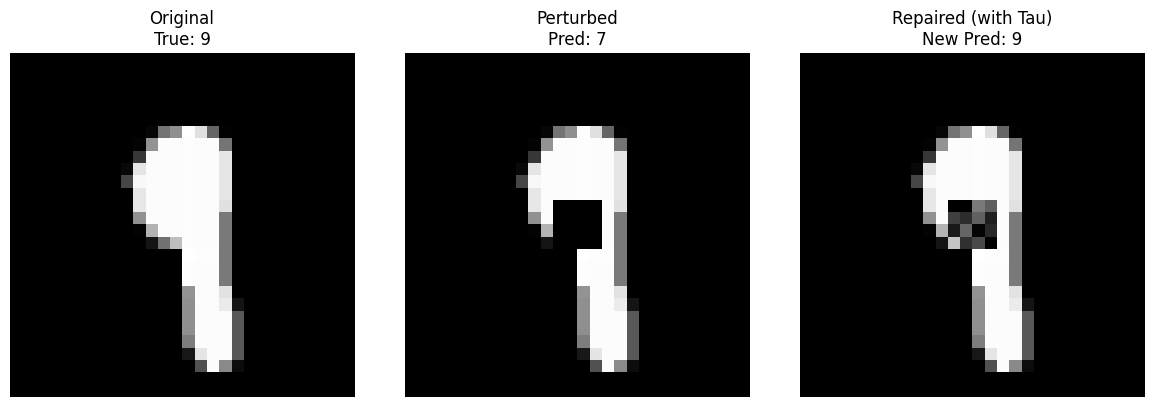


--- Case 52 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.207883042556521
Optimization Time: 10.0475 seconds
Successfully restored!


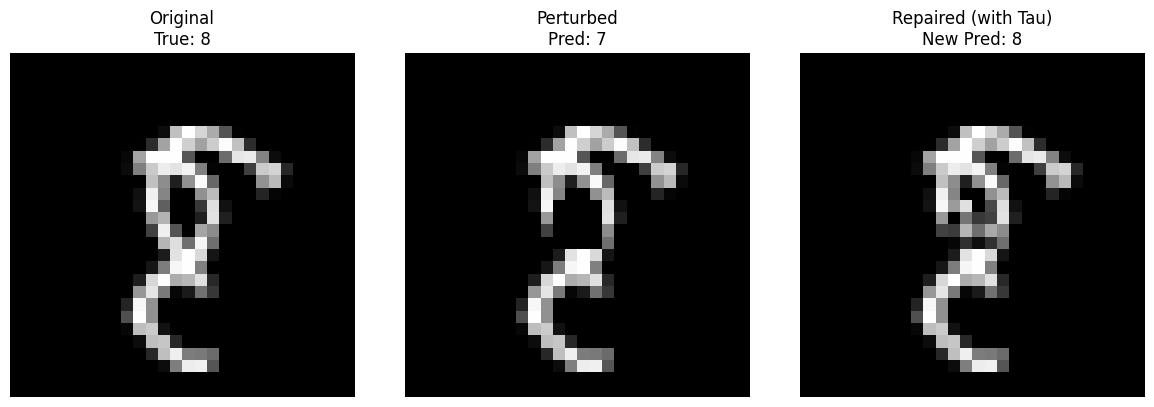


--- Case 53 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.4253889992707816
Optimization Time: 7.2160 seconds
Successfully restored!


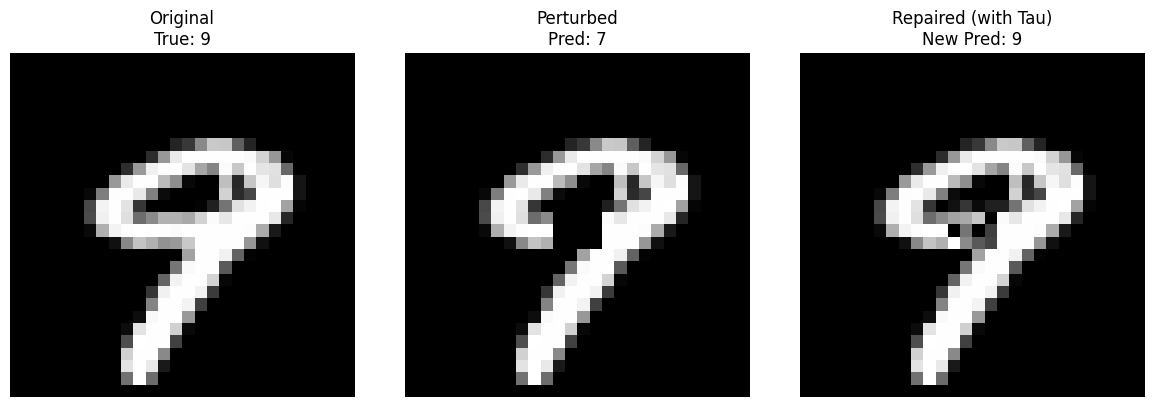


--- Case 54 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.337624821501001
Optimization Time: 12.0281 seconds
Successfully restored!


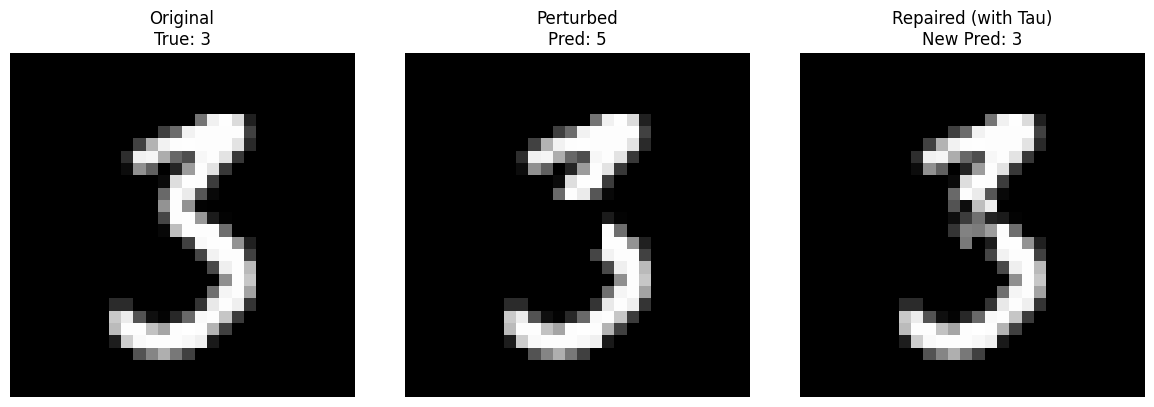


--- Case 55 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 5.186814834690324
Optimization Time: 5.5308 seconds
Successfully restored!


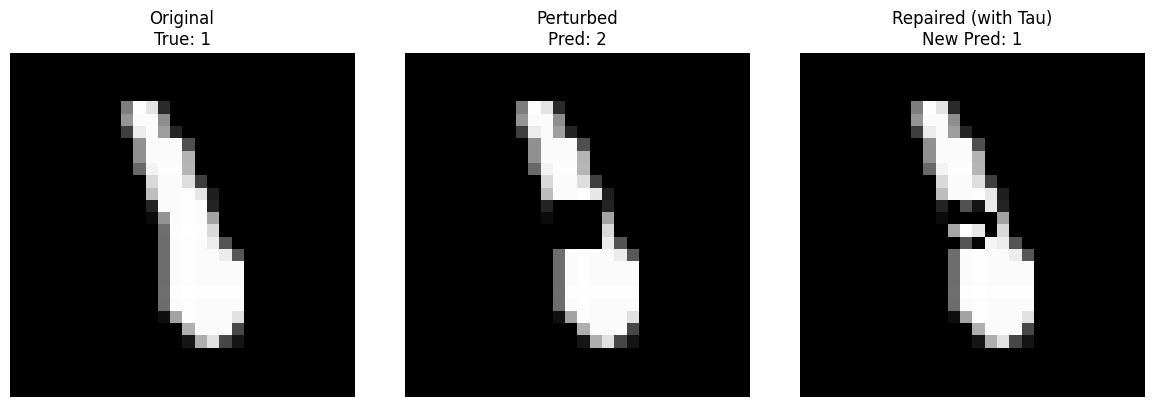


--- Case 56 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 6.062971782178848
Optimization Time: 7.2380 seconds
Successfully restored!


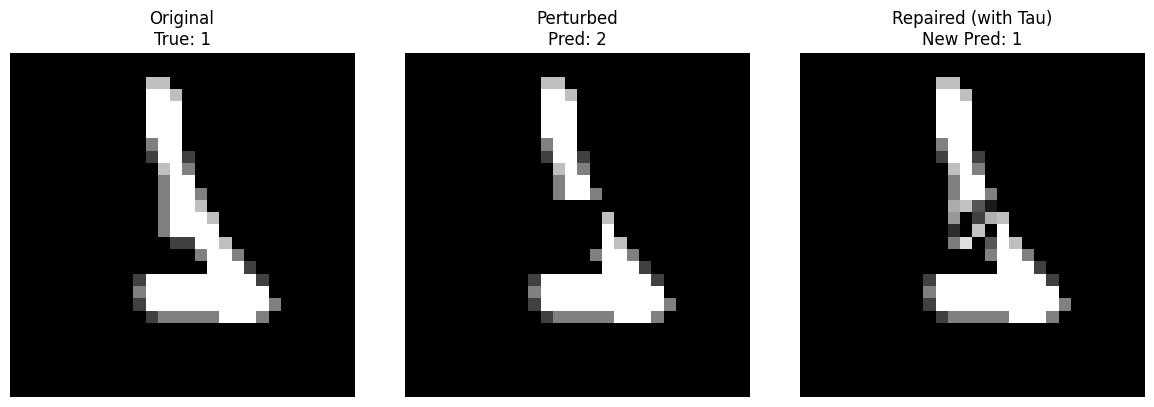


--- Case 57 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 1.1120643778640449
Optimization Time: 6.7407 seconds
Successfully restored!


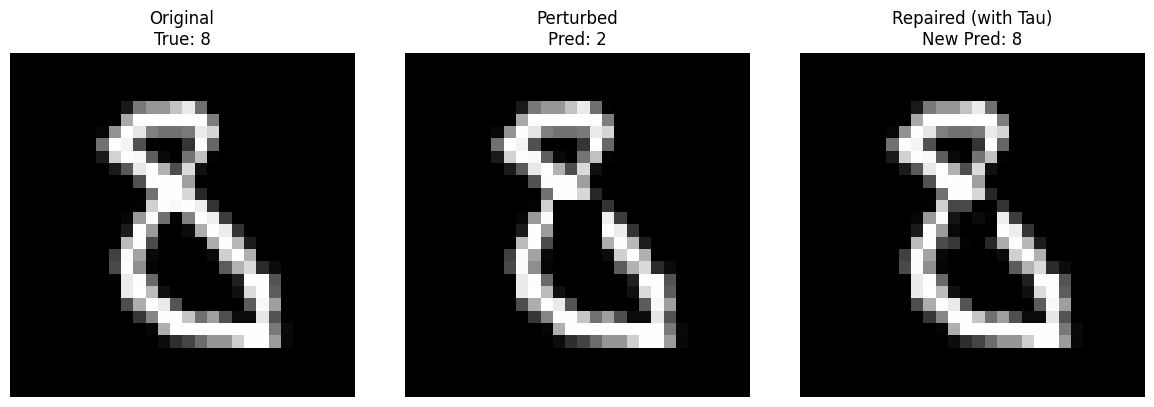


--- Case 58 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.009177542773198
Optimization Time: 7.5564 seconds
Successfully restored!


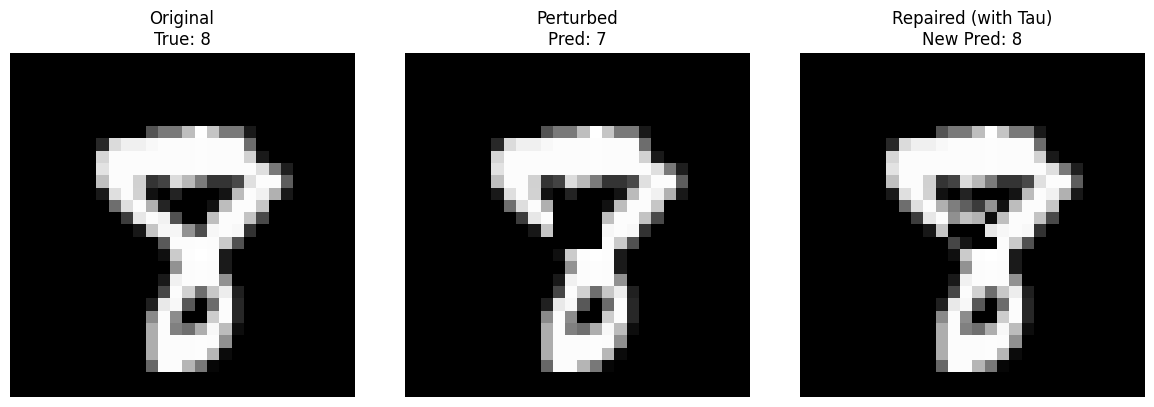


--- Case 59 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 6.860387735407044
Optimization Time: 7.6816 seconds
Successfully restored!


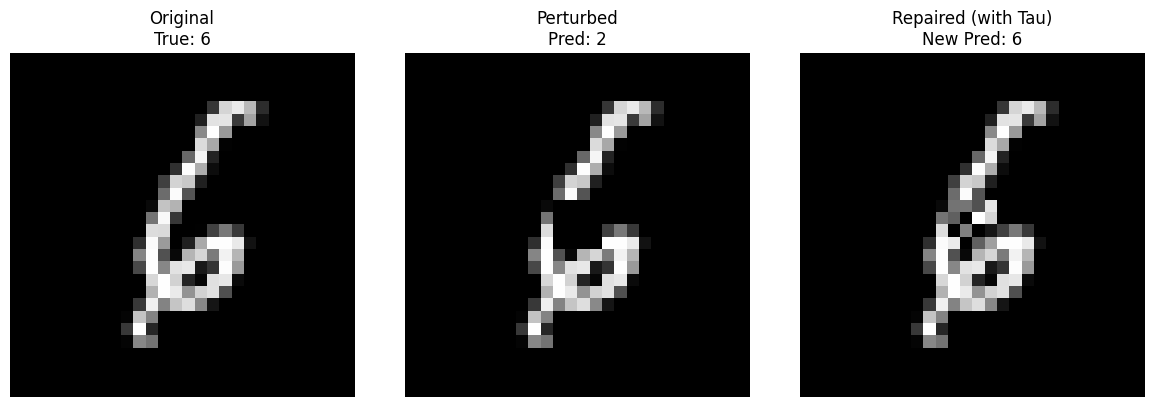


--- Case 60 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.93760913182868
Optimization Time: 8.9331 seconds
Successfully restored!


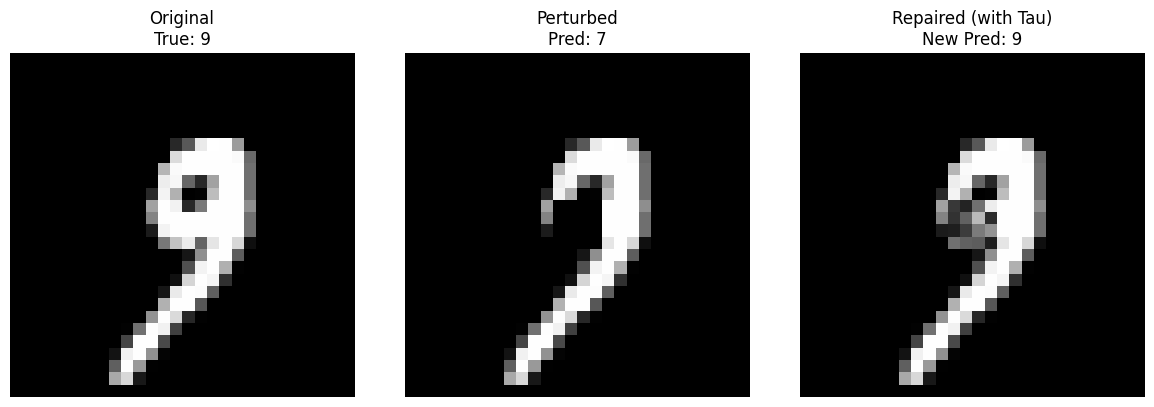


--- Case 61 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.836594958317738
Optimization Time: 7.6916 seconds
Successfully restored!


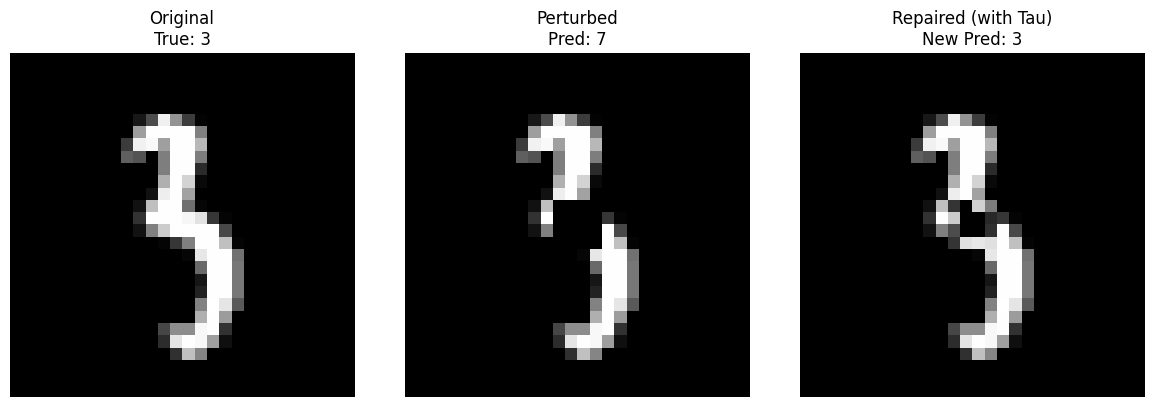


--- Case 62 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 4.632309845697437
Optimization Time: 7.8238 seconds


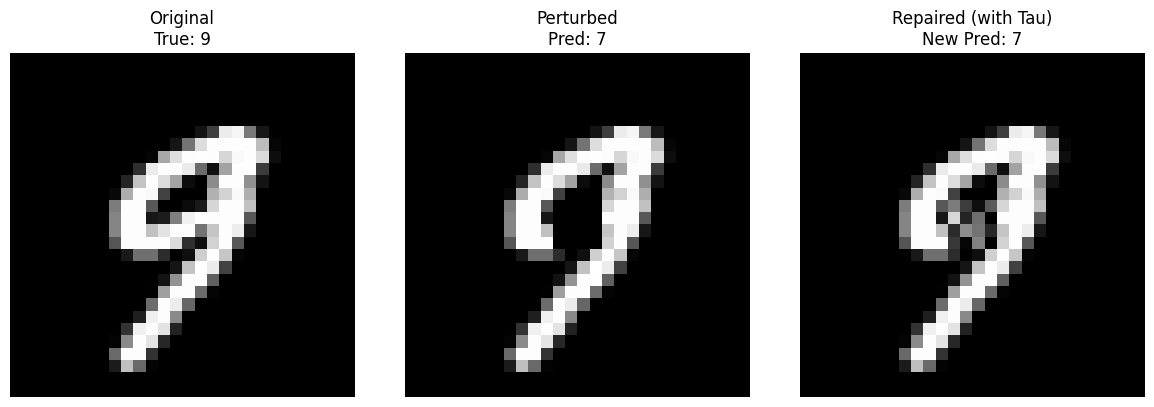


--- Case 63 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 1.9959217237171063
Optimization Time: 22.6040 seconds
Successfully restored!


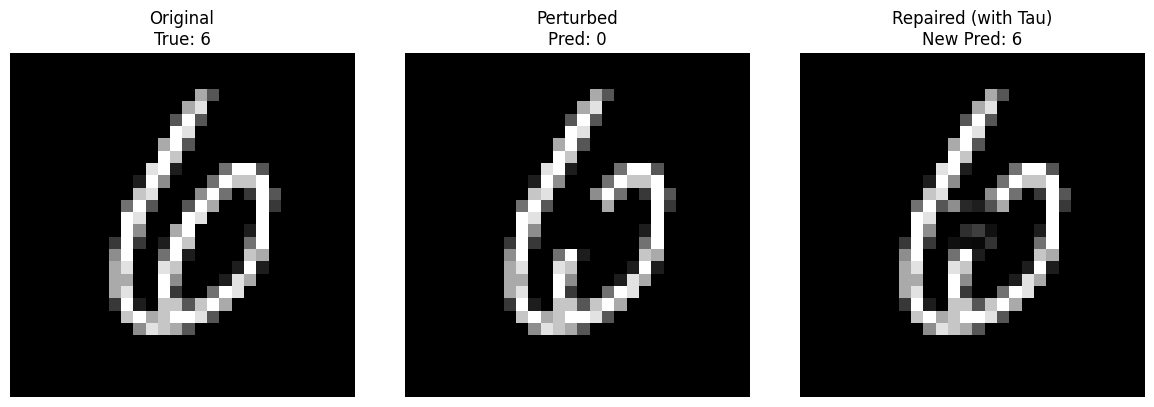


--- Case 64 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.984816495037455
Optimization Time: 7.3067 seconds
Successfully restored!


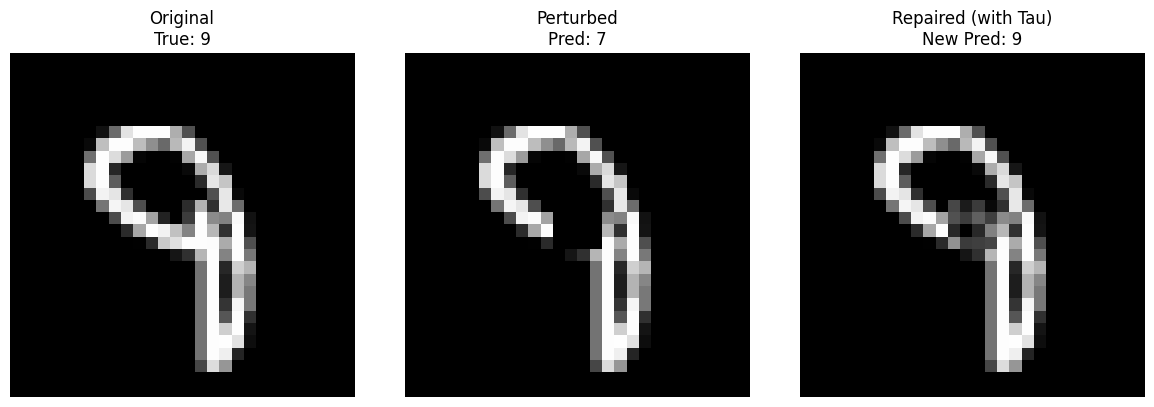


--- Case 65 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 2...
Pixels to add: 3.0190013920521057
Optimization Time: 7.7059 seconds


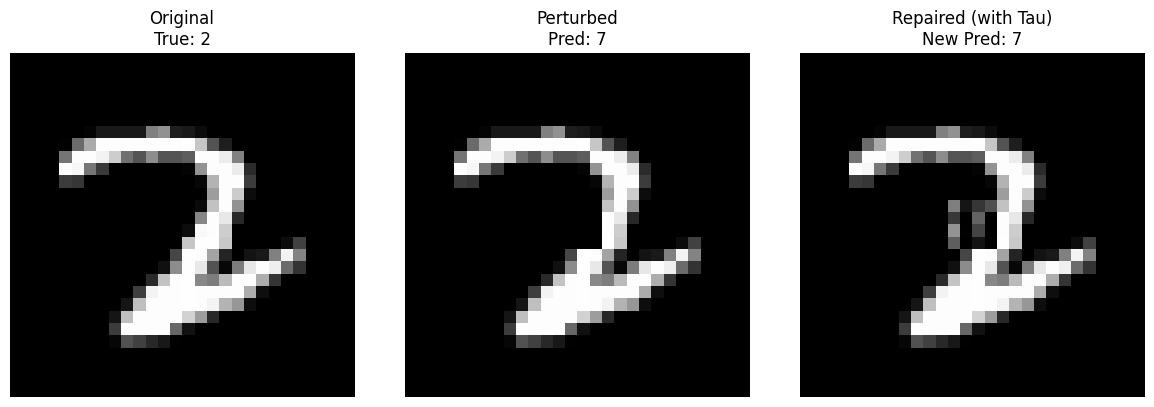


--- Case 66 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 2...
Pixels to add: 5.455124535185621
Optimization Time: 7.7230 seconds
Successfully restored!


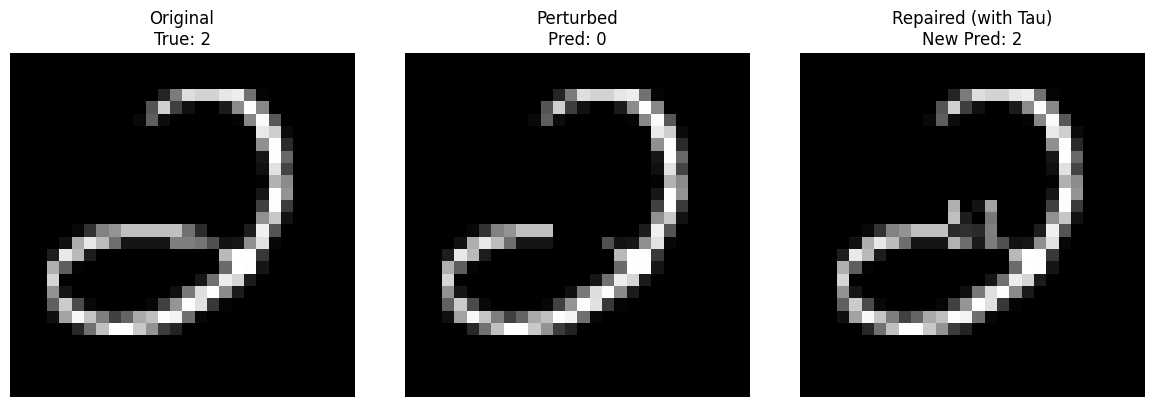


--- Case 67 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.9459606972361962
Optimization Time: 5.3487 seconds
Successfully restored!


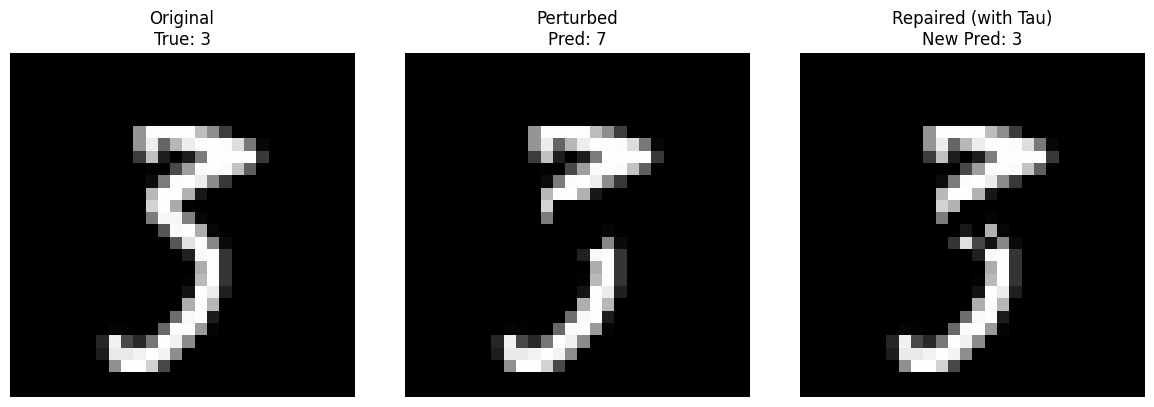


--- Case 68 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 3.1912796567430908
Optimization Time: 12.9201 seconds


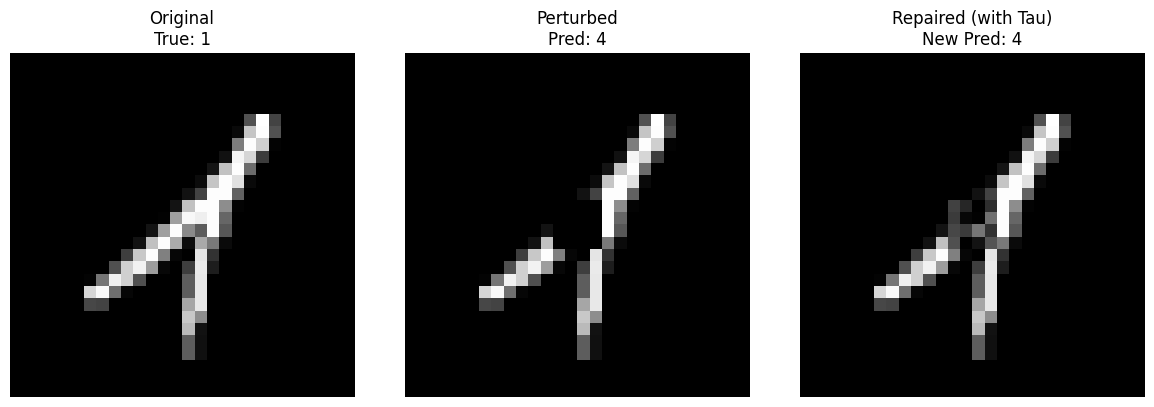


--- Case 69 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 7.364755937347375
Optimization Time: 8.4686 seconds
Successfully restored!


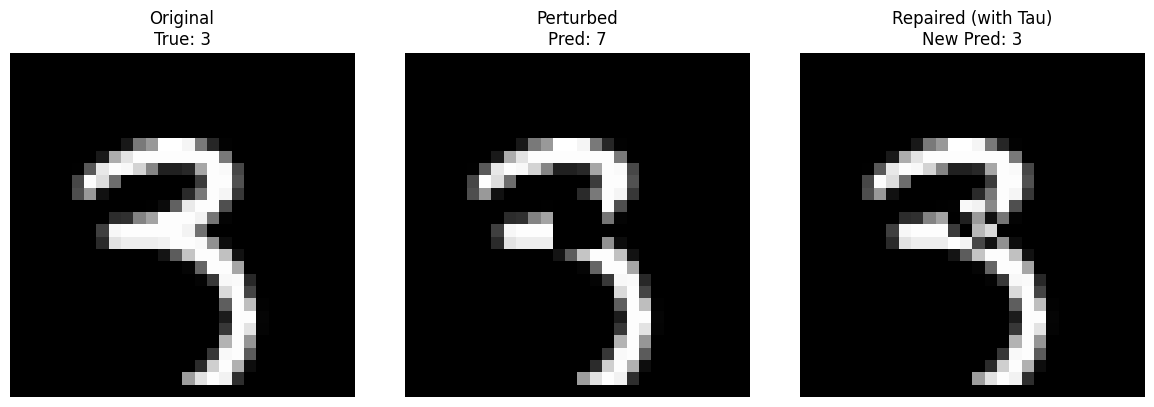


--- Case 70 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 4.569324978300491
Optimization Time: 57.4624 seconds


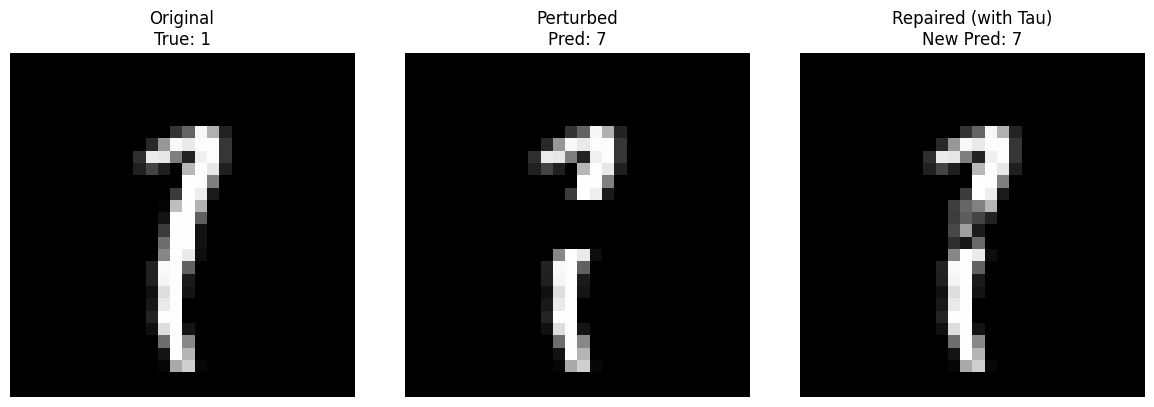


--- Case 71 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 8.474493706454131
Optimization Time: 7.5551 seconds
Successfully restored!


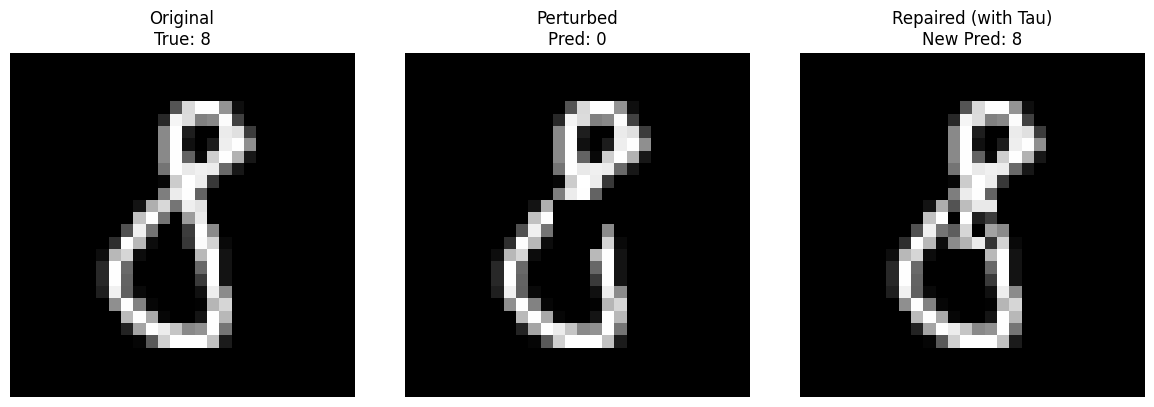


--- Case 72 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 4.668919086948543
Optimization Time: 9.1294 seconds
Successfully restored!


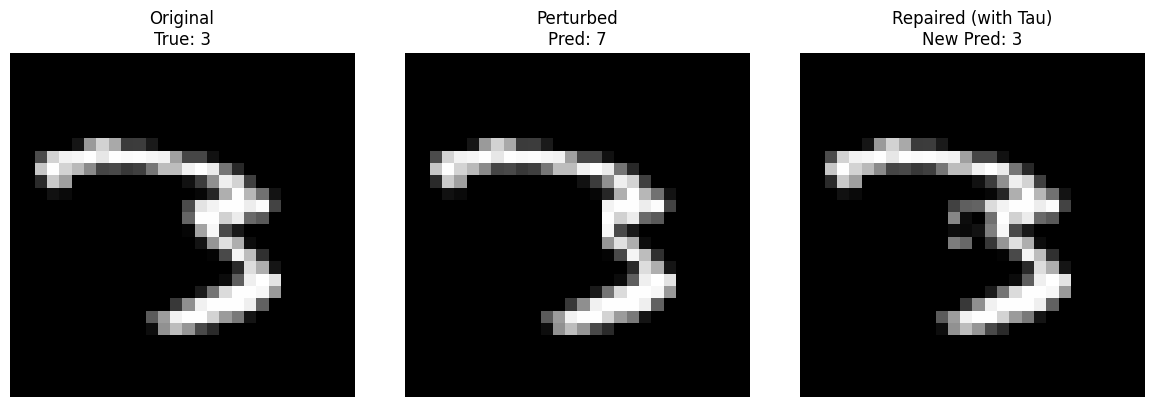


--- Case 73 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 4...
Pixels to add: 5.287195110882782
Optimization Time: 5.9006 seconds
Successfully restored!


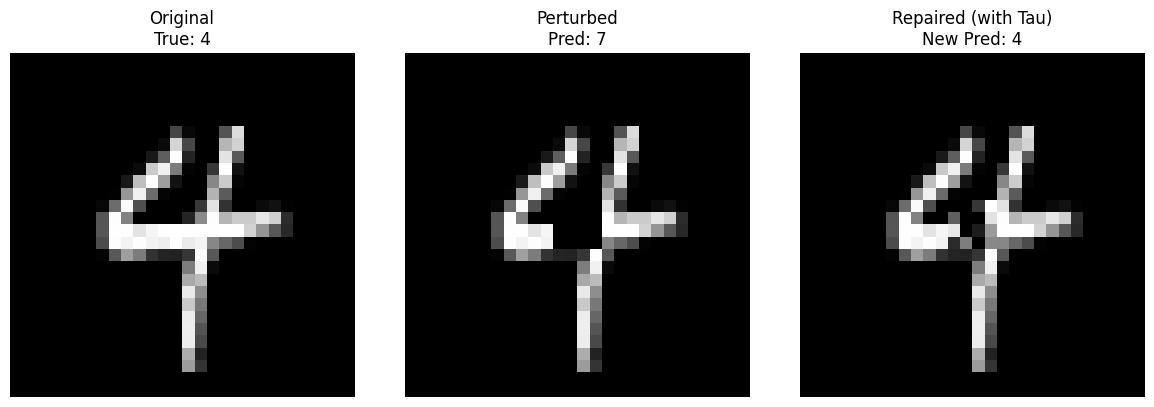


--- Case 74 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 4.255723389759993
Optimization Time: 13.1674 seconds


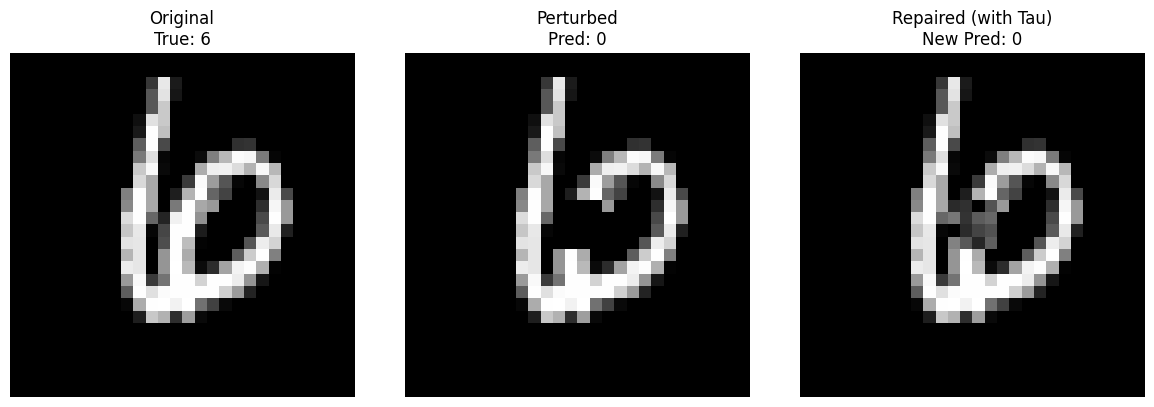


--- Case 75 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 6.075838413459436
Optimization Time: 7.5086 seconds
Successfully restored!


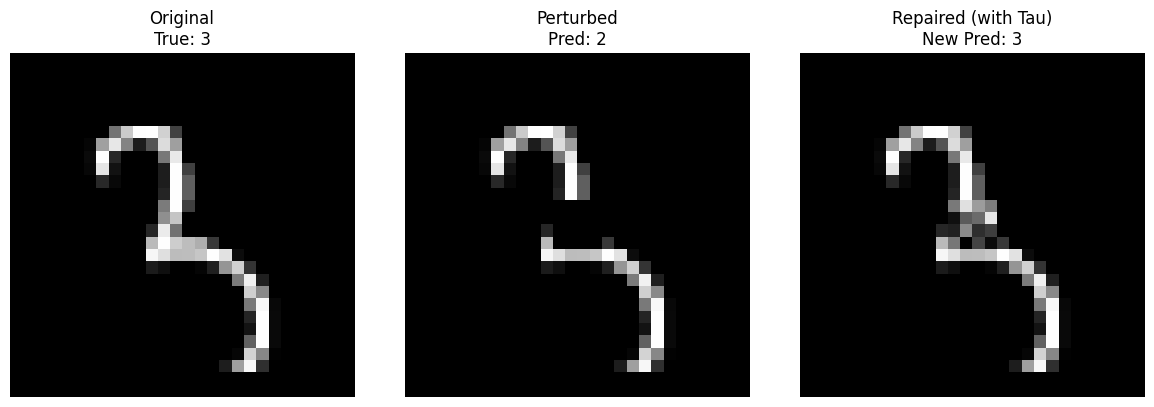


--- Case 76 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.319311429004487
Optimization Time: 9.2868 seconds


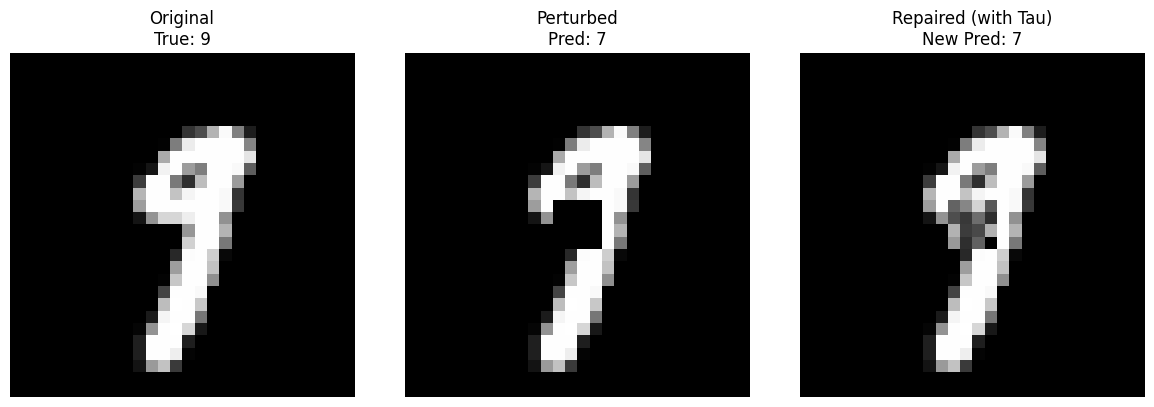


--- Case 77 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.9684665240535613
Optimization Time: 7.7579 seconds
Successfully restored!


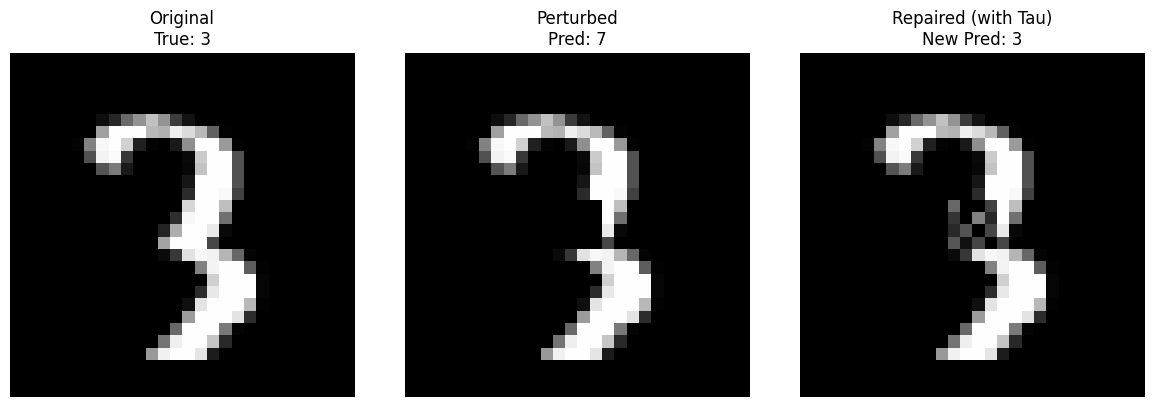


--- Case 78 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 5.962991220022207
Optimization Time: 7.3045 seconds
Successfully restored!


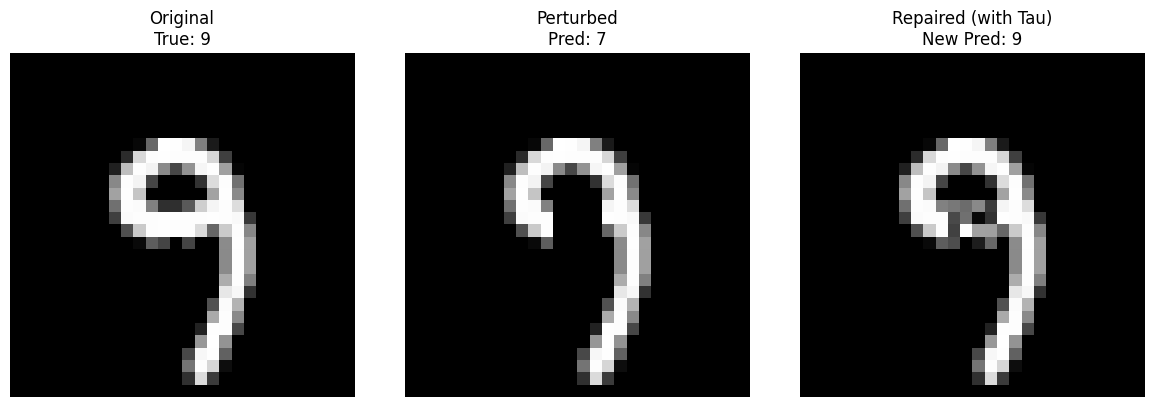


--- Case 79 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 2.4407581460812953
Optimization Time: 7.5993 seconds
Successfully restored!


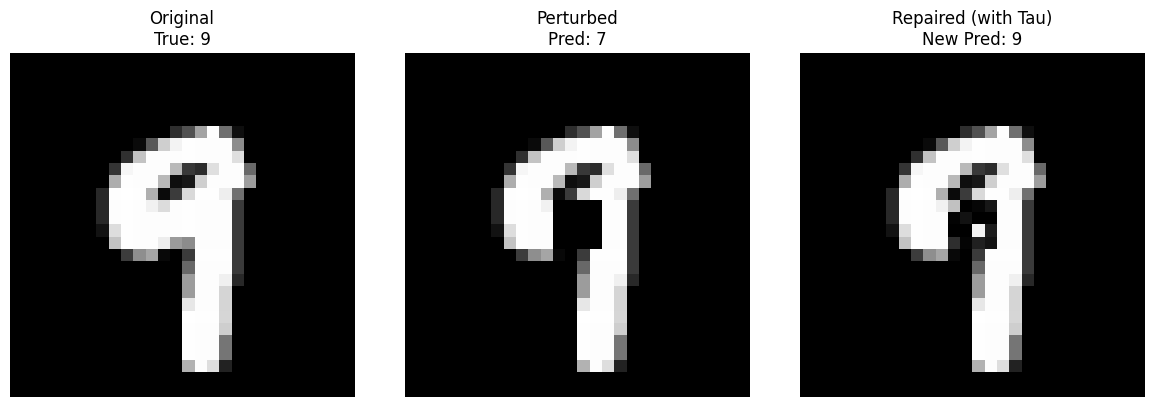


--- Case 80 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 2.126811043093013
Optimization Time: 6.6894 seconds
Successfully restored!


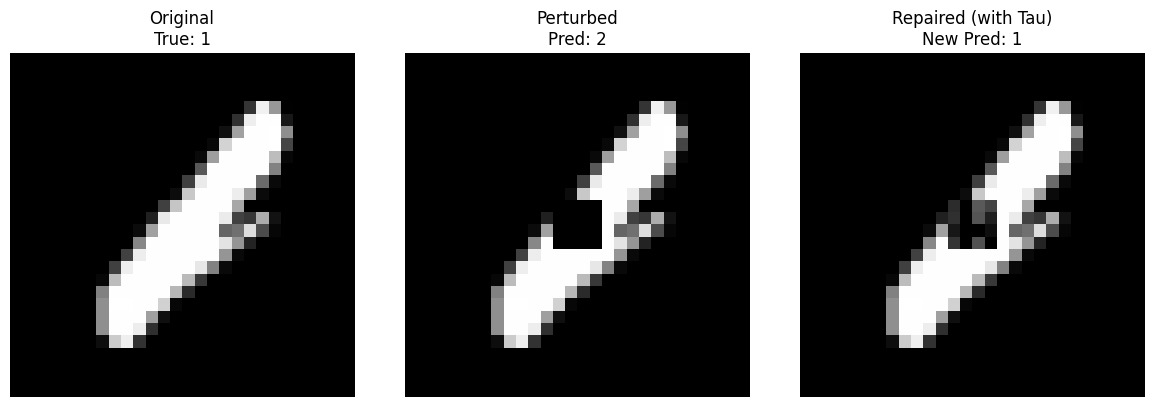


--- Case 81 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
No Repair Found (Status 9)
Optimization Time: 123.9975 seconds
>> No solution found (Infeasible or Timed Out)

--- Case 82 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.2533401174100747
Optimization Time: 7.8724 seconds
Successfully restored!


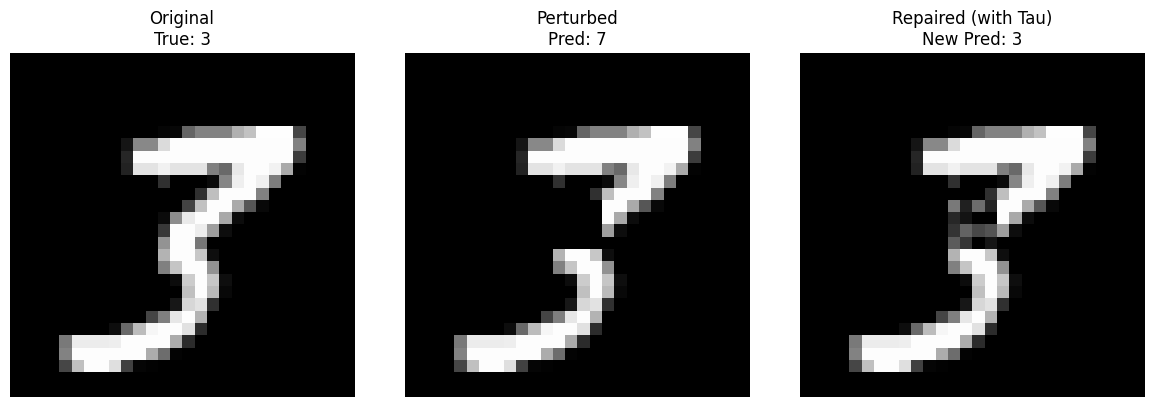


--- Case 83 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 2.638329201975033
Optimization Time: 7.4721 seconds
Successfully restored!


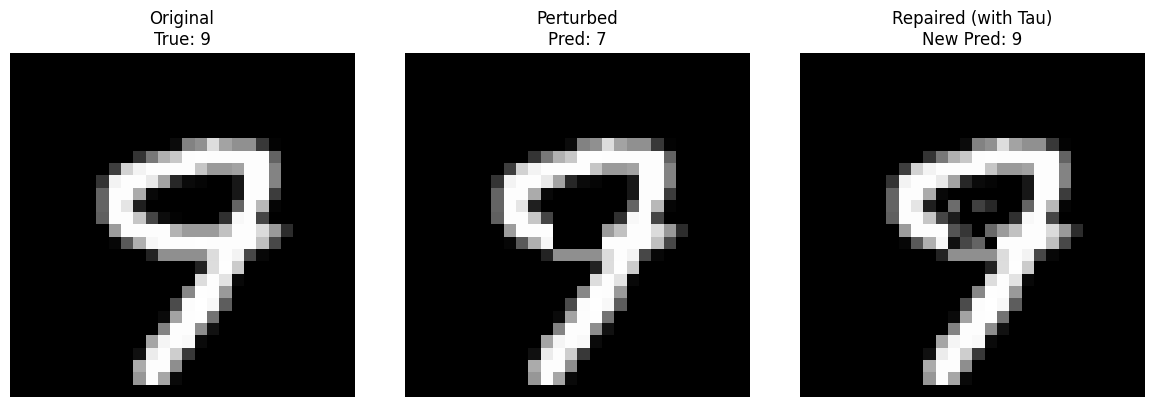


--- Case 84 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 3.3425161190561186
Optimization Time: 9.2039 seconds


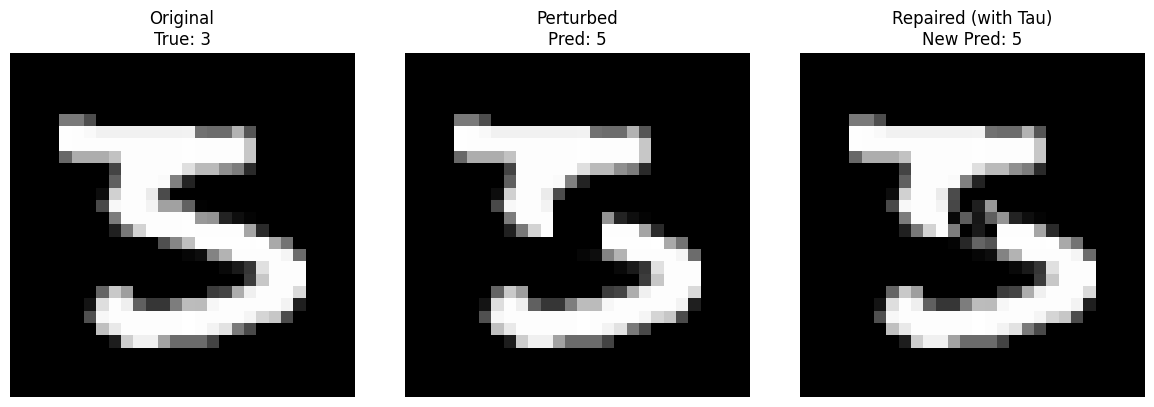


--- Case 85 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.548583077697203
Optimization Time: 9.6553 seconds
Successfully restored!


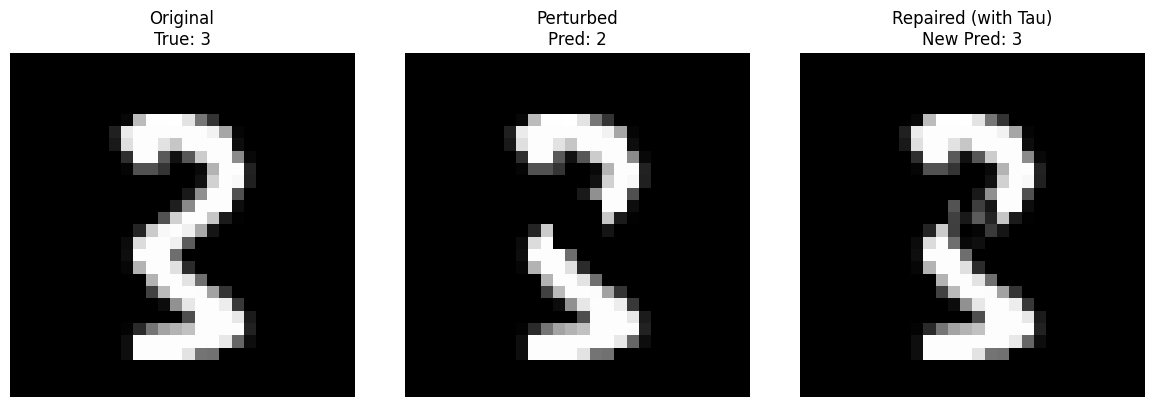


--- Case 86 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.170312108670974
Optimization Time: 6.8412 seconds
Successfully restored!


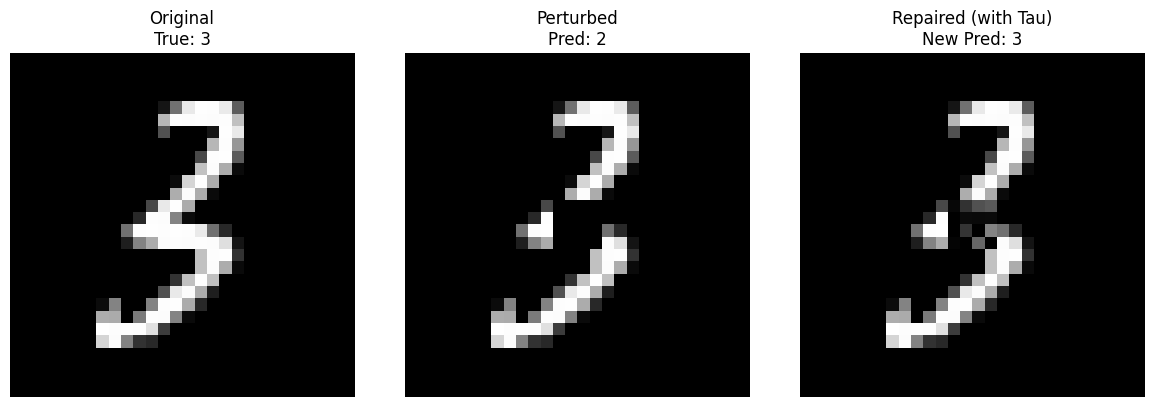


--- Case 87 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.108838755924066
Optimization Time: 7.1052 seconds
Successfully restored!


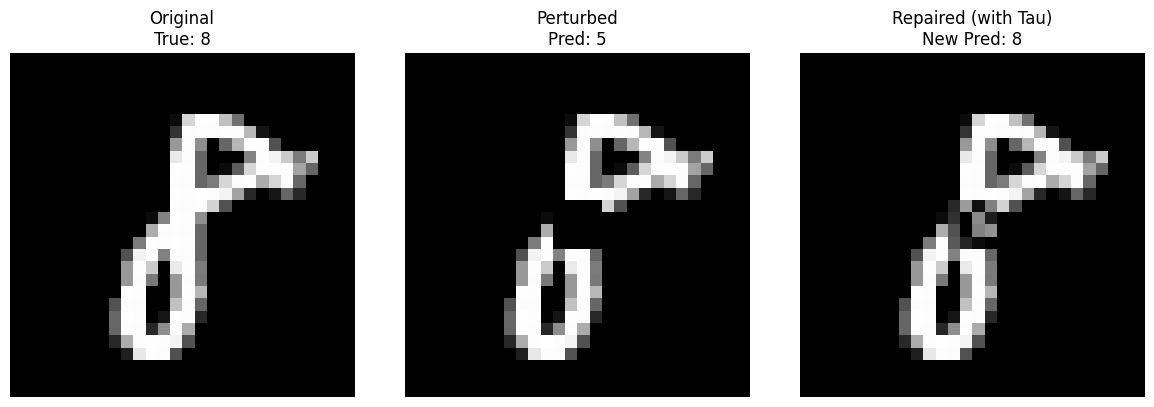


--- Case 88 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.69502679004582
Optimization Time: 7.1059 seconds
Successfully restored!


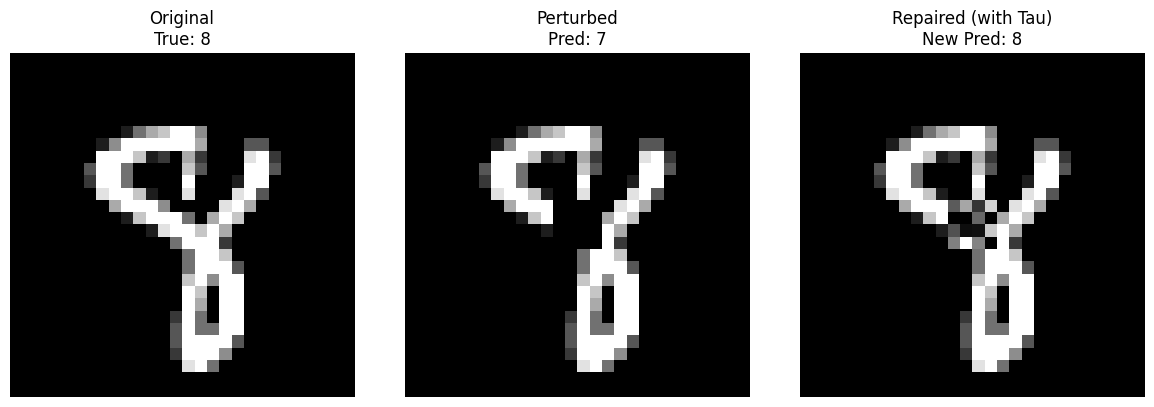


--- Case 89 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.354170872093578
Optimization Time: 7.3297 seconds
Successfully restored!


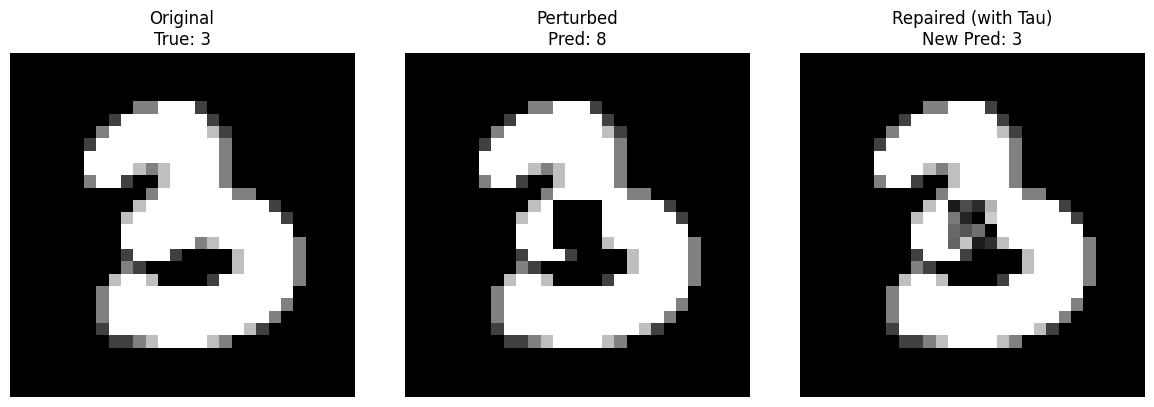


--- Case 90 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 6...
Pixels to add: 2.9065662439266085
Optimization Time: 6.9695 seconds
Successfully restored!


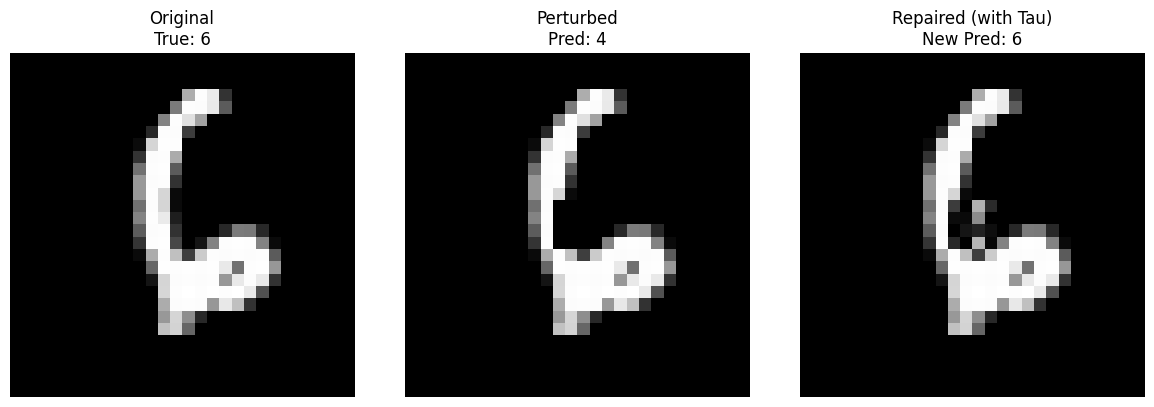


--- Case 91 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.885108135908352
Optimization Time: 6.8816 seconds
Successfully restored!


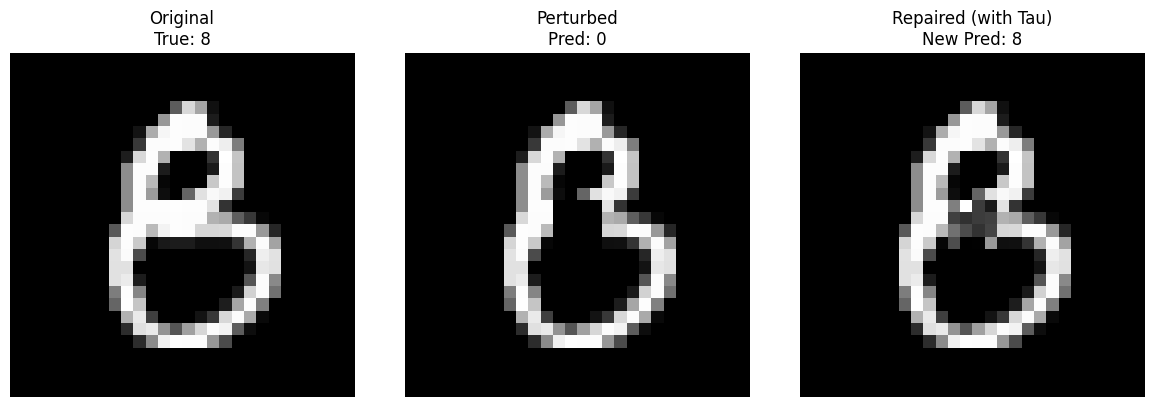


--- Case 92 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 3.5119442044242066
Optimization Time: 10.2548 seconds
Successfully restored!


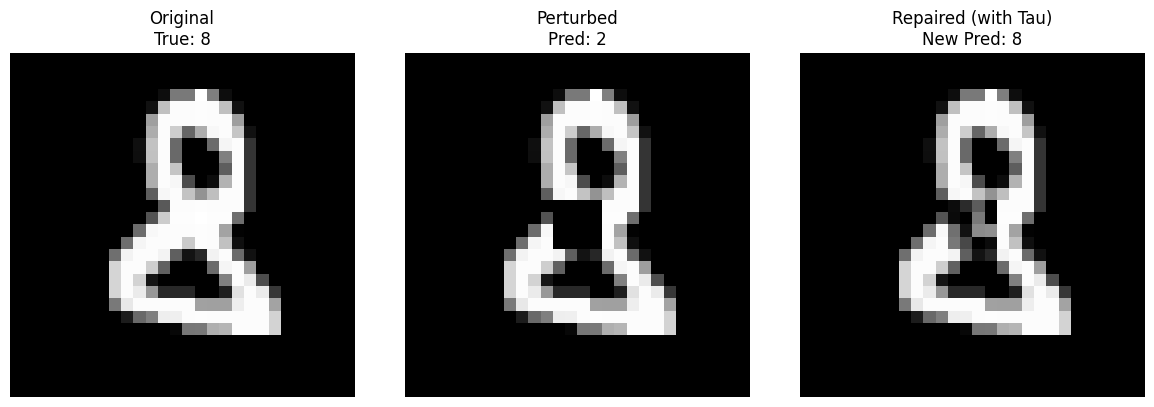


--- Case 93 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 5.41966386088273
Optimization Time: 90.7288 seconds
Successfully restored!


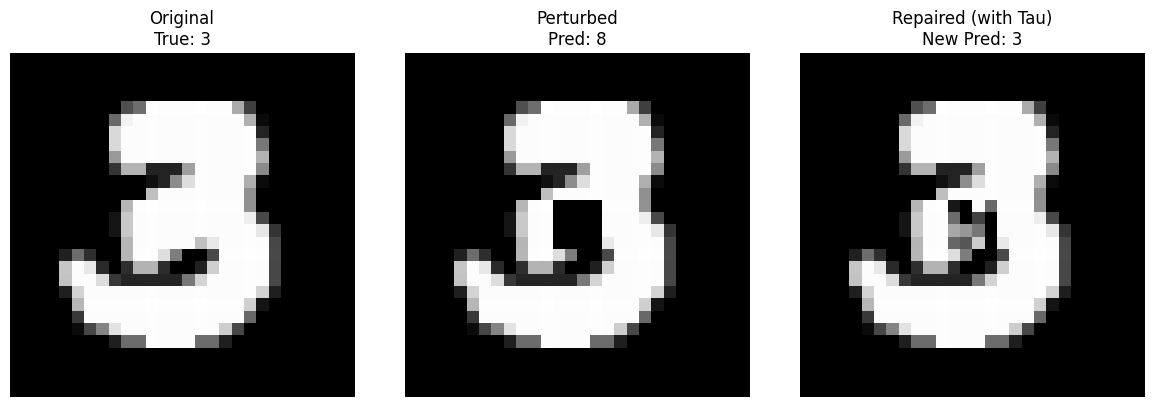


--- Case 94 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 5.248930625485324
Optimization Time: 7.3140 seconds
Successfully restored!


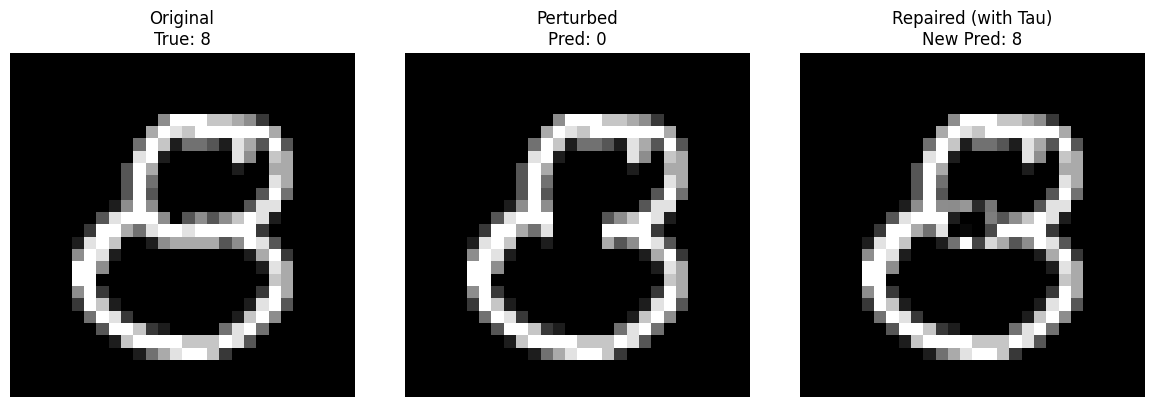


--- Case 95 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 1...
Pixels to add: 2.7997434326615016
Optimization Time: 7.1828 seconds
Successfully restored!


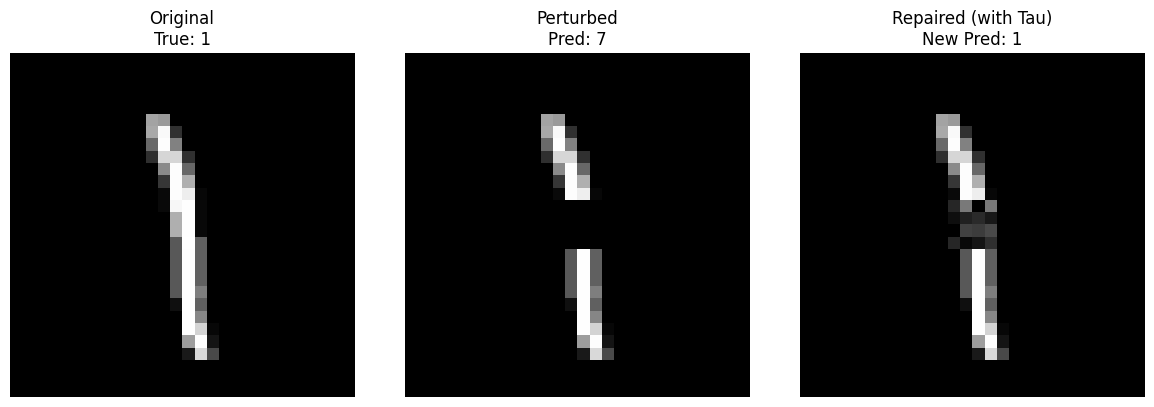


--- Case 96 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 1.70325858943775
Optimization Time: 7.0889 seconds
Successfully restored!


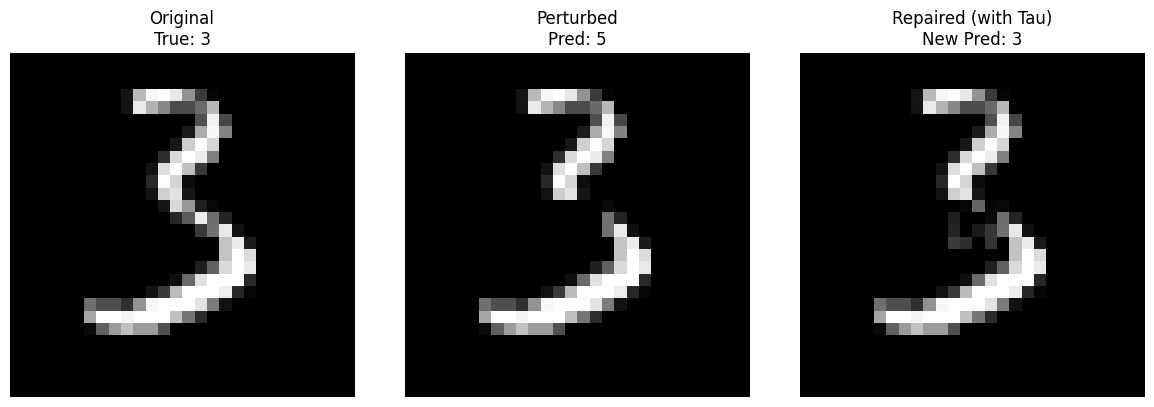


--- Case 97 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 6.4498293808333536
Optimization Time: 7.1262 seconds
Successfully restored!


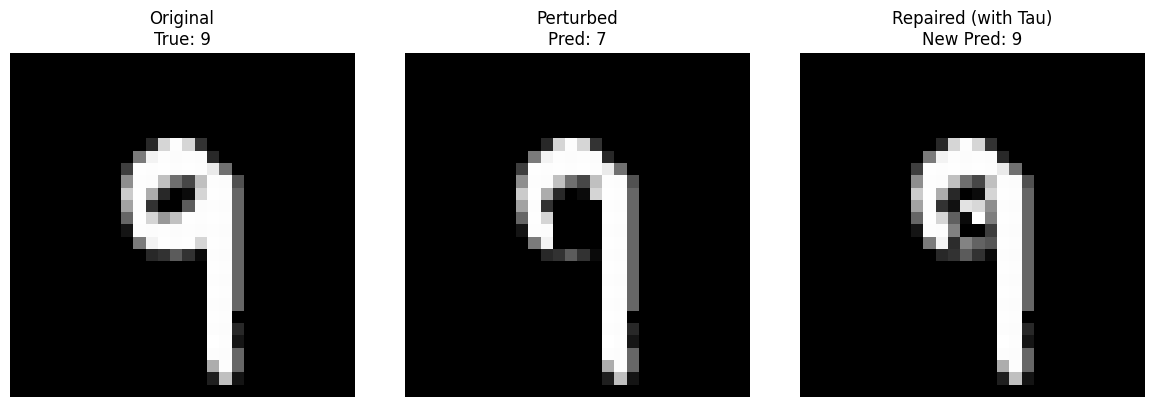


--- Case 98 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 3...
Pixels to add: 2.4362113419905373
Optimization Time: 6.9362 seconds


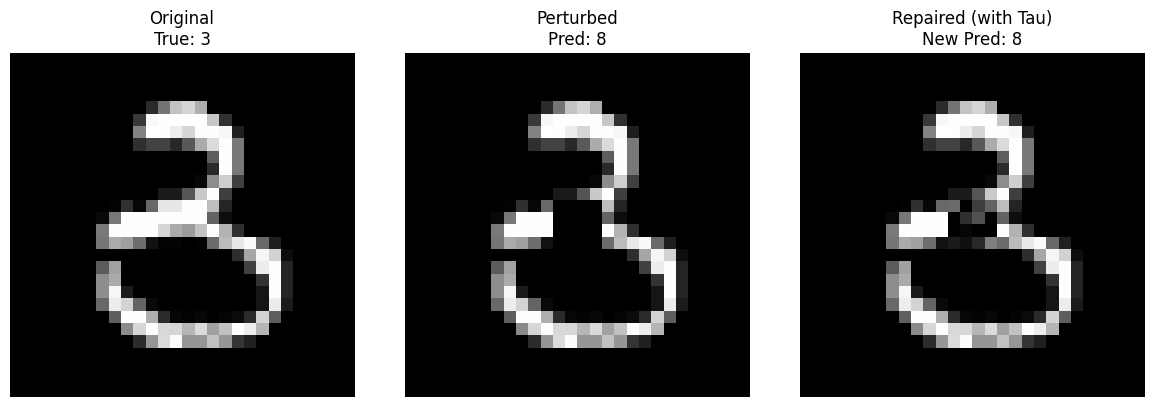


--- Case 99 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 8...
Pixels to add: 4.079278829412338
Optimization Time: 15.1441 seconds
Successfully restored!


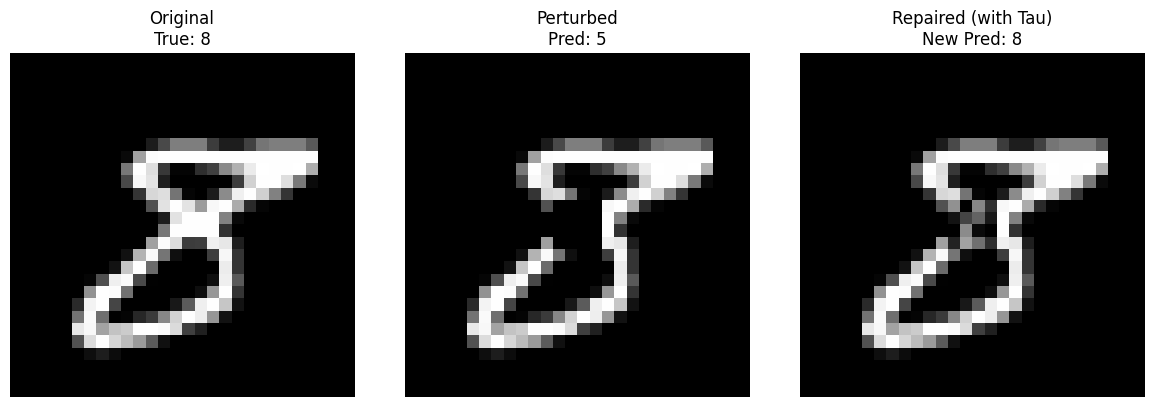


--- Case 100 / 100 ---
Set parameter TimeLimit to value 120
Solving for True Label 9...
Pixels to add: 3.8729816755624062
Optimization Time: 6.7331 seconds
Successfully restored!


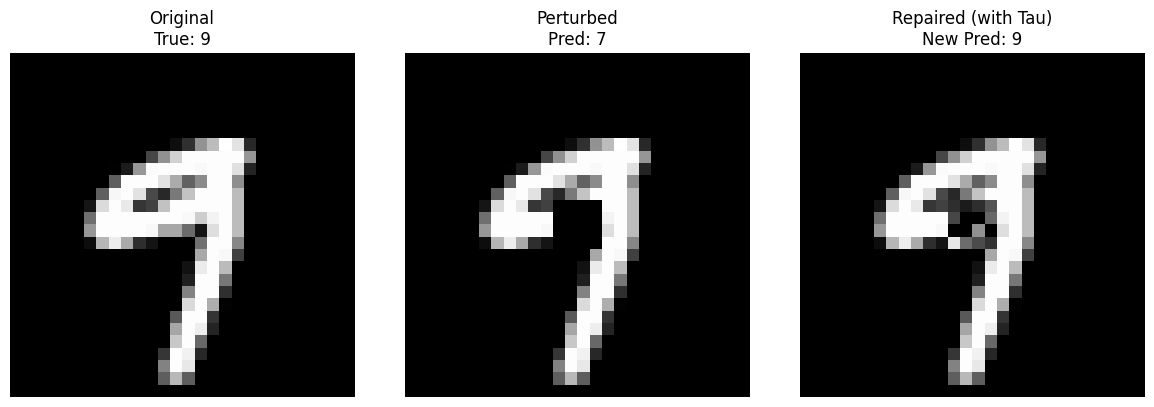

Total time taken to process 100 images : 1261.01s
Success Rate: 85/100 = 85.00%


In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import random  # <--- Added import

# 4. Solve & Visualize
subset = 100
grid_size = cutout_size
start_idx = 14 - grid_size // 2
correct = 0

# --- RANDOM SELECTION LOGIC ---
total_failures = len(failures)
actual_subset_size = min(subset, total_failures) # Safety check

if actual_subset_size < subset:
    print(f"Warning: Requested {subset} images, but only found {total_failures} failures.")

print(f"Selecting {actual_subset_size} random failure cases...")
selected_failures = random.sample(failures, actual_subset_size)
# ------------------------------

st_time = time.time()

# Iterate over the randomly selected list
for i, case in enumerate(selected_failures):
    print(f"\n--- Case {i+1} / {actual_subset_size} ---")

    # --- START TIMER ---
    start_time = time.time()

    # Run the solver
    tau_val = solve_tau_milp(model, case, grid_size=grid_size,tauType=1)

    # --- STOP TIMER ---
    elapsed_time = time.time() - start_time
    print(f"Optimization Time: {elapsed_time:.4f} seconds")

    if tau_val is not None:
        plt.figure(figsize=(12, 4))

        # 1. Original
        plt.subplot(1, 3, 1)
        plt.title(f"Original\nTrue: {case['true_label']}")
        plt.imshow(case['original'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 2. Perturbed (Attack)
        plt.subplot(1, 3, 2)
        plt.title(f"Perturbed\nPred: {case['wrong_label']}")
        plt.imshow(case['perturbed'], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        # 3. Apply Tau (Repair)
        repaired = case['perturbed'].copy()

        # Robust logic: Zero out the area first, then add tau
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] = 0.0
        repaired[start_idx:start_idx+grid_size, start_idx:start_idx+grid_size, 0] += tau_val

        # Verify Prediction
        pred_prob = model.predict(np.expand_dims(repaired, 0), verbose=0)
        pred_lbl = np.argmax(pred_prob)

        if(pred_lbl == case['true_label']):
            correct += 1
            print(f"Successfully restored!")

        plt.subplot(1, 3, 3)
        plt.title(f"Repaired (with Tau)\nNew Pred: {pred_lbl}")
        plt.imshow(repaired, cmap='gray', vmin=0, vmax=1)
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(">> No solution found (Infeasible or Timed Out)")

el_time = time.time() - st_time

print(f"Total time taken to process {actual_subset_size} images : {el_time:.2f}s")
print(f"Success Rate: {correct}/{actual_subset_size} = {correct/actual_subset_size*100:.2f}%")